# Статистика пилотного корпуса

In [697]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import re

In [698]:
plt.rcParams['font.family'] = 'DejaVu Sans'

In [699]:
df = pd.read_csv('Семь тыщ 06.02.2026.csv', on_bad_lines='skip')

In [700]:
cols_to_drop = ['sentence_id', 'corrections', 'right_context', 'left_context']
indices_cols = [col for col in df.columns if '_indices' in col.lower()]

all_cols_to_drop = cols_to_drop + indices_cols
df_clean = df.drop(columns=[col for col in all_cols_to_drop if col in df.columns], errors='ignore')

In [701]:
df_clean.head()

,sentences,period_functions,comma_functions,exclam_functions,question_functions,left_parenthesis_functions,right_parenthesis_functions,left_square_bracket_functions,right_square_bracket_functions,left_angle_bracket_functions,...,right_parenthesis_reliance,left_square_bracket_reliance,right_square_bracket_reliance,left_angle_bracket_reliance,right_angle_bracket_reliance,open_quote_reliance,close_quote_reliance,colon_reliance,semicolon_reliance,apostrophe_reliance
0,-- Что ты больше всего уважаешь в людях?,NaN,NaN,NaN,"[['end_sent', 'question']]",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-- Ну это слишком обобщенный вопрос…,"[['ellipsis', 'comb'], ['ellipsis', 'comb'], [...",[['interjection']],NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"-- Ну хорошо, а в нашем сверстнике?",NaN,"[['interjection'], ['compos', 'oppos_clauses']]",NaN,"[['end_sent', 'question']]",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"-- Самое главное чтобы это был не хайлафист, ж...","[['ellipsis', 'comb'], ['ellipsis', 'comb'], [...","[['subord', 'explan_clause'], ['equal'], ['com...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-- Но ведь игрой на публику он зарабатывает се...,NaN,NaN,NaN,"[['end_sent', 'question']]",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Функции для анализа

### Анализ функций знаков препинания

In [702]:
def parse_punct_func_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, list)]
        return []
    except (ValueError, SyntaxError):
        return []

In [703]:
def count_punct_marks_by_funcs(punct_func_lists):
    return sum(len(lst) for lst in punct_func_lists)

In [704]:
def flatten_punct_functions(punct_func_lists):
    all_functions = []
    for lst in punct_func_lists:
        for inner_list in lst:
            for func in inner_list:
                if isinstance(func, str) and func.strip():
                    all_functions.append(func.strip())
    return all_functions

In [705]:
def compute_function_statistics(all_functions):
    total_functions = len(all_functions)
    func_counter = Counter(all_functions)

    stats_df = pd.DataFrame({
        'Функция': list(func_counter.keys()),
        'Количество': list(func_counter.values()),
        'Доля (%)': [
            round(count / total_functions * 100, 2) if total_functions > 0 else 0
            for count in func_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, func_counter

In [706]:
def visualize_punct_functions(stats_df, punct_name, total_functions, top_n=15):
    punct_labels = {
        'comma': 'запятых',
        'period': 'точек',
        'exclam': 'восклицательных знаков',
        'question': 'вопросительных знаков',
        'colon': 'двоеточий',
        'semicolon': 'точек с запятой',
        'dash': 'тире',
        'hyphen': 'дефисов',
        'slash': 'слешей',
        'left_parenthesis': 'открывающих скобок',
        'right_parenthesis': 'закрывающих скобок',
        'left_square_bracket': 'открывающих квадратных скобок',
        'right_square_bracket': 'закрывающих квадратных скобок',
        'left_angle_bracket': 'открывающих треугольных скобок',
        'right_angle_bracket': 'закрывающих треугольных скобок',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)

    top_funcs = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_funcs))
    bars = plt.barh(y_pos, top_funcs['Количество'], color='steelblue', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_funcs['Количество'], top_funcs['Доля (%)'])):
        plt.text(count + total_functions * 0.01, i, f'{count} ({pct}%)',
                 va='center', fontsize=9)

    plt.yticks(y_pos, top_funcs['Функция'])
    plt.xlabel('Количество функций')
    plt.title(f'Топ-{top_n} функций {punct_label} (всего функций: {total_functions})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_functions_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [707]:
def analyze_punctuation_func(df, punct_name):
    col_name = f"{punct_name}_functions"

    if col_name not in df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена в датафрейме. Доступные колонки: {list(df.columns)}")

    punct_func_lists = df[col_name].apply(parse_punct_func_column)

    total_puncts = count_punct_marks_by_funcs(punct_func_lists)

    all_functions = flatten_punct_functions(punct_func_lists)
    total_functions = len(all_functions)

    func_stats_df, func_counter = compute_function_statistics(all_functions)

    print(f"Анализ функций '{punct_name}':\n")
    print(f"   - Общее количество {punct_name}: {total_puncts}")
    print(f"   - Общее количество функций (с повторениями): {total_functions}")
    if total_puncts > 0:
        avg_funcs = total_functions / total_puncts
        print(f"   - Среднее количество функций на знак: {avg_funcs:.2f}")
    print(f"   - Уникальных функций: {len(func_counter)}")

    return {
        'punct_lists': punct_func_lists,
        'total_puncts': total_puncts,
        'all_functions': all_functions,
        'total_functions': total_functions,
        'func_counter': func_counter,
        'func_stats_df': func_stats_df
    }

### Анализ нормативности

In [708]:
def parse_punct_normality_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [709]:
def count_punct_marks_by_normality(punct_normality_lists):
    return sum(len(lst) for lst in punct_normality_lists)

In [710]:
def flatten_normality_values(punct_normality_lists):
    all_values = []
    for lst in punct_normality_lists:
        for value in lst:
            all_values.append(value.strip())
    return all_values

In [711]:
def compute_normality_statistics(all_values):
    total_values = len(all_values)
    value_counter = Counter(all_values)

    stats_df = pd.DataFrame({
        'Нормативность': list(value_counter.keys()),
        'Количество': list(value_counter.values()),
        'Доля (%)': [
            round(count / total_values * 100, 2) if total_values > 0 else 0
            for count in value_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, value_counter

In [712]:
def visualize_normality_stats(stats_df, punct_name, total_values, top_n=6):
    punct_labels = {
        'comma': 'запятых',
        'period': 'точек',
        'exclam': 'восклицательных знаков',
        'question': 'вопросительных знаков',
        'colon': 'двоеточий',
        'semicolon': 'точек с запятой',
        'dash': 'тире',
        'hyphen': 'дефисов',
        'slash': 'слешей',
        'left_parenthesis': 'открывающих скобок',
        'right_parenthesis': 'закрывающих скобок',
        'left_square_bracket': 'открывающих квадратных скобок',
        'right_square_bracket': 'закрывающих квадратных скобок',
        'left_angle_bracket': 'открывающих треугольных скобок',
        'right_angle_bracket': 'закрывающих треугольных скобок',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)
    punct_label = punct_labels.get(punct_name, punct_name)

    top_vals = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_vals))
    bars = plt.barh(y_pos, top_vals['Количество'], color='palevioletred', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_vals['Количество'], top_vals['Доля (%)'])):
        plt.text(count + total_values * 0.01, i, f'{count} ({pct}%)',
                 va='center', fontsize=9)

    plt.yticks(y_pos, top_vals['Нормативность'])
    plt.xlabel('Количество знаков')
    plt.title(f'Топ-{top_n} значений нормативности для {punct_label} (всего знаков: {total_values})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_normality_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [713]:
def analyze_punctuation_normality(df, punct_name):
    col_name = f"{punct_name}_normality"

    if col_name not in df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена в датафрейме. Доступные колонки: {list(df.columns)}")

    punct_normality_lists = df[col_name].apply(parse_punct_normality_column)

    total_puncts_normality = count_punct_marks_by_normality(punct_normality_lists)

    all_normality_values = flatten_normality_values(punct_normality_lists)
    total_normality_values = len(all_normality_values)

    normality_stats_df, normality_counter = compute_normality_statistics(all_normality_values)

    print(f"Анализ нормативности '{punct_name}':\n")
    print(f"   - Общее количество {punct_name}: {total_puncts_normality}")
    print(f"   - Уникальных значений нормативности: {len(normality_counter)}")

    return {
        'punct_normality_lists': punct_normality_lists,
        'total_puncts_normality': total_puncts_normality,
        'all_normality_values': all_normality_values,
        'total_normality_values': total_normality_values,
        'normality_counter': normality_counter,
        'normality_stats_df': normality_stats_df
    }

### Анализ постановки/непостановки знаков

In [714]:
def parse_punct_presence_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [715]:
def count_punct_marks_by_presence(punct_presence_lists):
    return sum(len(lst) for lst in punct_presence_lists)

In [716]:
def flatten_presence_values(punct_presence_lists):
    all_values = []
    for lst in punct_presence_lists:
        for value in lst:
            all_values.append(value.strip())
    return all_values

In [717]:
def compute_presence_statistics(all_values):
    total_values = len(all_values)
    value_counter = Counter(all_values)

    stats_df = pd.DataFrame({
        'Присутствие': list(value_counter.keys()),
        'Количество': list(value_counter.values()),
        'Доля (%)': [
            round(count / total_values * 100, 2) if total_values > 0 else 0
            for count in value_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, value_counter

In [718]:
def visualize_presence_stats(stats_df, punct_name, total_values, top_n=2):
    punct_labels = {
        'comma': 'запятых',
        'period': 'точек',
        'exclam': 'восклицательных знаков',
        'question': 'вопросительных знаков',
        'colon': 'двоеточий',
        'semicolon': 'точек с запятой',
        'dash': 'тире',
        'hyphen': 'дефисов',
        'slash': 'слешей',
        'left_parenthesis': 'открывающих скобок',
        'right_parenthesis': 'закрывающих скобок',
        'left_square_bracket': 'открывающих квадратных скобок',
        'right_square_bracket': 'закрывающих квадратных скобок',
        'left_angle_bracket': 'открывающих треугольных скобок',
        'right_angle_bracket': 'закрывающих треугольных скобок',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)

    top_vals = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_vals))
    bars = plt.barh(y_pos, top_vals['Количество'], color='mediumseagreen', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_vals['Количество'], top_vals['Доля (%)'])):
        plt.text(count + total_values * 0.01, i, f'{count} ({pct}%)',
                 va='center', fontsize=9)

    plt.yticks(y_pos, top_vals['Присутствие'])
    plt.xlabel('Количество знаков')
    plt.title(f'Топ-{top_n} значений присутствия для {punct_label} (всего знаков: {total_values})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_presence_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [719]:
def analyze_punctuation_presence(df, punct_name):
    col_name = f"{punct_name}_presence"

    if col_name not in df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена в датафрейме. Доступные колонки: {list(df.columns)}")

    punct_presence_lists = df[col_name].apply(parse_punct_presence_column)

    total_puncts_presence = count_punct_marks_by_presence(punct_presence_lists)

    all_presence_values = flatten_presence_values(punct_presence_lists)
    total_presence_values = len(all_presence_values)

    presence_stats_df, presence_counter = compute_presence_statistics(all_presence_values)

    print(f"Анализ присутствия '{punct_name}':\n")
    print(f"   - Общее количество {punct_name}: {total_puncts_presence}")
    print(f"   - Уникальных значений присутствия: {len(presence_counter)}")

    return {
        'punct_presence_lists': punct_presence_lists,
        'total_puncts_presence': total_puncts_presence,
        'all_presence_values': all_presence_values,
        'total_presence_values': total_presence_values,
        'presence_counter': presence_counter,
        'presence_stats_df': presence_stats_df
    }

### Анализ степени уверенности

In [720]:
def parse_punct_reliance_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [721]:
def count_punct_marks_by_reliance(punct_reliance_lists):
    return sum(len(lst) for lst in punct_reliance_lists)

In [722]:
def flatten_reliance_values(punct_reliance_lists):
    all_values = []
    for lst in punct_reliance_lists:
        for value in lst:
            all_values.append(value.strip())
    return all_values

In [723]:
def compute_reliance_statistics(all_values):
    total_values = len(all_values)
    value_counter = Counter(all_values)

    stats_df = pd.DataFrame({
        'Степень уверенности': list(value_counter.keys()),
        'Количество': list(value_counter.values()),
        'Доля (%)': [
            round(count / total_values * 100, 2) if total_values > 0 else 0
            for count in value_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, value_counter

In [724]:
def visualize_reliance_stats(stats_df, punct_name, total_values, top_n=2):
    punct_labels = {
        'comma': 'запятых',
        'period': 'точек',
        'exclam': 'восклицательных знаков',
        'question': 'вопросительных знаков',
        'colon': 'двоеточий',
        'semicolon': 'точек с запятой',
        'dash': 'тире',
        'hyphen': 'дефисов',
        'slash': 'слешей',
        'left_parenthesis': 'открывающих скобок',
        'right_parenthesis': 'закрывающих скобок',
        'left_square_bracket': 'открывающих квадратных скобок',
        'right_square_bracket': 'закрывающих квадратных скобок',
        'left_angle_bracket': 'открывающих треугольных скобок',
        'right_angle_bracket': 'закрывающих треугольных скобок',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)

    top_vals = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_vals))
    plt.barh(y_pos, top_vals['Количество'], color='slateblue', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_vals['Количество'], top_vals['Доля (%)'])):
        plt.text(count + total_values * 0.01, i, f'{count} ({pct}%)', va='center', fontsize=9)

    plt.yticks(y_pos, top_vals['Степень уверенности'])
    plt.xlabel('Количество знаков')
    plt.title(f'Топ-{top_n} значений степени уверенности для {punct_label} (всего знаков: {total_values})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_reliance_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [725]:
def analyze_punctuation_reliance(df, punct_name, total_puncts_expected=None):

    col_name = f"{punct_name}_reliance"

    if col_name not in df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена в датафрейме. Доступные колонки: {list(df.columns)}")

    punct_reliance_lists = df[col_name].apply(parse_punct_reliance_column)

    total_puncts_reliance = count_punct_marks_by_reliance(punct_reliance_lists)

    all_reliance_values = flatten_reliance_values(punct_reliance_lists)
    total_reliance_values = len(all_reliance_values)

    reliance_stats_df, reliance_counter = compute_reliance_statistics(all_reliance_values)

    print(f"Анализ степени уверенности '{punct_name}':\n")
    print(f"   - Знаков с размеченной степенью уверенности: {total_puncts_reliance}")

    coverage_pct = None
    if total_puncts_expected is not None:
        if total_puncts_expected > 0:
            coverage_pct = round(total_puncts_reliance / total_puncts_expected * 100, 2)
            print(f"   - Общее количество {punct_name} (по функциям): {total_puncts_expected}")
            print(f"   - Покрытие разметки степени уверенности: {coverage_pct}%")
        else:
            print(f"   - Общее количество {punct_name} (по функциям): 0")
            print(f"   - Покрытие разметки: неприменимо (нет знаков)")
    else:
        print(f"   - Общее количество {punct_name} (по функциям): неизвестно")
        print(f"   - Покрытие разметки: не рассчитано")

    print(f"   - Уникальных значений степени уверенности: {len(reliance_counter)}")

    if coverage_pct is not None:
        reliance_stats_df['Покрытие разметки (%)'] = coverage_pct

    return {
        'punct_reliance_lists': punct_reliance_lists,
        'total_puncts_reliance': total_puncts_reliance,
        'all_reliance_values': all_reliance_values,
        'total_reliance_values': total_reliance_values,
        'reliance_counter': reliance_counter,
        'reliance_stats_df': reliance_stats_df,
        'coverage_pct': coverage_pct
    }

### Анализ пробелов

In [726]:
def parse_punct_spaces_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [727]:
def count_punct_marks_by_spaces(punct_spaces_lists):
    return sum(len(lst) for lst in punct_spaces_lists)

In [728]:
def flatten_spaces_values(punct_spaces_lists):
    all_values = []
    for lst in punct_spaces_lists:
        for value in lst:
            all_values.append(value.strip())
    return all_values

In [729]:
def compute_spaces_statistics(all_values):
    total_values = len(all_values)
    value_counter = Counter(all_values)

    stats_df = pd.DataFrame({
        'Пробел': list(value_counter.keys()),
        'Количество': list(value_counter.values()),
        'Доля (%)': [
            round(count / total_values * 100, 2) if total_values > 0 else 0
            for count in value_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, value_counter

In [730]:
def visualize_spaces_stats(stats_df, punct_name, total_values, top_n=4):
    punct_labels = {
        'comma': 'запятых',
        'period': 'точек',
        'exclam': 'восклицательных знаков',
        'question': 'вопросительных знаков',
        'colon': 'двоеточий',
        'semicolon': 'точек с запятой',
        'dash': 'тире',
        'hyphen': 'дефисов',
        'slash': 'слешей',
        'left_parenthesis': 'открывающих скобок',
        'right_parenthesis': 'закрывающих скобок',
        'left_square_bracket': 'открывающих квадратных скобок',
        'right_square_bracket': 'закрывающих квадратных скобок',
        'left_angle_bracket': 'открывающих треугольных скобок',
        'right_angle_bracket': 'закрывающих треугольных скобок',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)

    top_vals = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_vals))
    plt.barh(y_pos, top_vals['Количество'], color='tan', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_vals['Количество'], top_vals['Доля (%)'])):
        plt.text(count + total_values * 0.01, i, f'{count} ({pct}%)', va='center', fontsize=9)

    plt.yticks(y_pos, top_vals['Пробел'])
    plt.xlabel('Количество знаков')
    plt.title(f'Топ-{top_n} значений пробелов для {punct_label} (всего знаков: {total_values})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_spaces_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [731]:
def analyze_punctuation_spaces(df, punct_name):
    col_name = f"{punct_name}_space"

    if col_name not in df.columns:
        raise ValueError(f"Колонка '{col_name}' не найдена в датафрейме. Доступные колонки: {list(df.columns)}")

    punct_spaces_lists = df[col_name].apply(parse_punct_spaces_column)

    total_puncts_spaces = count_punct_marks_by_spaces(punct_spaces_lists)

    all_spaces_values = flatten_spaces_values(punct_spaces_lists)
    total_spaces_values = len(all_spaces_values)

    spaces_stats_df, spaces_counter = compute_spaces_statistics(all_spaces_values)

    print(f"Анализ пробелов '{punct_name}':\n")
    print(f"   - Общее количество {punct_name}: {total_puncts_spaces}")
    print(f"   - Уникальных значений пробелов: {len(spaces_counter)}")

    return {
        'punct_spaces_lists': punct_spaces_lists,
        'total_puncts_spaces': total_puncts_spaces,
        'all_spaces_values': all_spaces_values,
        'total_spaces_values': total_spaces_values,
        'spaces_counter': spaces_counter,
        'spaces_stats_df': spaces_stats_df
    }

### Анализ формы выражения

In [732]:
def parse_punct_expression_column(val):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [733]:
def count_punct_marks_by_expression(punct_expression_lists):
    return sum(len(lst) for lst in punct_expression_lists)

In [734]:
def flatten_expression_values(punct_expression_lists):
    all_values = []
    for lst in punct_expression_lists:
        for value in lst:
            all_values.append(value.strip())
    return all_values

In [735]:
def compute_expression_statistics(all_values):
    total_values = len(all_values)
    value_counter = Counter(all_values)

    stats_df = pd.DataFrame({
        'Форма выражения': list(value_counter.keys()),
        'Количество': list(value_counter.values()),
        'Доля (%)': [
            round(count / total_values * 100, 2) if total_values > 0 else 0
            for count in value_counter.values()
        ]
    }).sort_values('Количество', ascending=False).reset_index(drop=True)

    return stats_df, value_counter

In [736]:
def visualize_expression_stats(stats_df, punct_name, total_values, top_n=5):

    punct_labels = {
        'dash': 'тире',
        'open_quote': 'открывающих кавычек',
        'close_quote': 'закрывающих кавычек',
        'apostrophe': 'апострофов'
    }
    punct_label = punct_labels.get(punct_name, punct_name)

    top_vals = stats_df.head(top_n)

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(top_vals))
    plt.barh(y_pos, top_vals['Количество'], color='lightsalmon', alpha=0.85)

    for i, (count, pct) in enumerate(zip(top_vals['Количество'], top_vals['Доля (%)'])):
        plt.text(count + total_values * 0.01, i, f'{count} ({pct}%)', va='center', fontsize=9)

    plt.yticks(y_pos, top_vals['Форма выражения'])
    plt.xlabel('Количество знаков')
    plt.title(f'Топ-{top_n} форм выражения для {punct_label} (всего знаков: {total_values})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'{punct_name}_expression_histogram.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [737]:
def analyze_punctuation_expression(df, punct_name):
    col_name = f"{punct_name}_expression"

    if col_name not in df.columns:
        available = [col for col in df.columns if 'expression' in col.lower()]
        raise ValueError(f"Колонка '{col_name}' не найдена. Доступные колонки с 'expression': {available}")

    punct_expression_lists = df[col_name].apply(parse_punct_expression_column)

    total_puncts_expression = count_punct_marks_by_expression(punct_expression_lists)

    all_expression_values = flatten_expression_values(punct_expression_lists)
    total_expression_values = len(all_expression_values)

    expression_stats_df, expression_counter = compute_expression_statistics(all_expression_values)

    print(f"Анализ формы выражения '{punct_name}':\n")
    print(f"   - Общее количество {punct_name}: {total_puncts_expression}")
    print(f"   - Уникальных форм выражения: {len(expression_counter)}")

    return {
        'punct_expression_lists': punct_expression_lists,
        'total_puncts_expression': total_puncts_expression,
        'all_expression_values': all_expression_values,
        'total_expression_values': total_expression_values,
        'expression_counter': expression_counter,
        'expression_stats_df': expression_stats_df
    }

## Точка

### Функции знака

In [738]:
period_func_result = analyze_punctuation_func(df_clean, 'period')

period_lists = period_func_result['punct_lists']
total_periods = period_func_result['total_puncts']
all_period_functions = period_func_result['all_functions']
total_period_functions = period_func_result['total_functions']
period_func_counter = period_func_result['func_counter']
period_func_stats_df = period_func_result['func_stats_df']

Анализ функций 'period':

   - Общее количество period: 1224
   - Общее количество функций (с повторениями): 1660
   - Среднее количество функций на знак: 1.36
   - Уникальных функций: 14


In [739]:
print("Статистика по функциям точек:\n")
print(period_func_stats_df.to_string(index=False))

Статистика по функциям точек:

    Функция  Количество  Доля (%)
   ellipsis         388     23.37
       comb         388     23.37
   end_sent         366     22.05
abbrev_name         193     11.63
     biblio         128      7.71
     remark          80      4.82
abbrev_word          48      2.89
       date          22      1.33
      title          16      0.96
     number          13      0.78
       parc           9      0.54
 censorship           4      0.24
       link           3      0.18
      comma           2      0.12


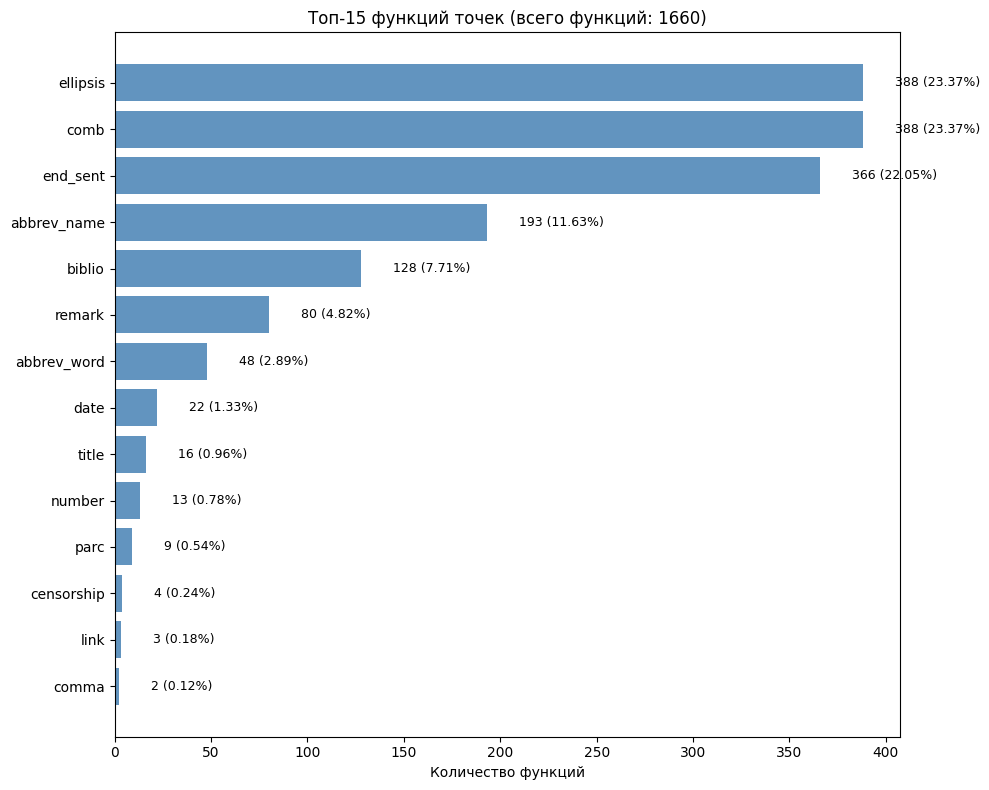

'period_functions_histogram.png'

In [740]:
visualize_punct_functions(period_func_stats_df, 'period', total_period_functions)

### Постановка/непостановка

In [741]:
period_presence_result = analyze_punctuation_presence(df_clean, 'period')

period_presence_lists = period_presence_result['punct_presence_lists']
total_periods_presence = period_presence_result['total_puncts_presence']
all_period_presence = period_presence_result['all_presence_values']
total_period_presence_values = period_presence_result['total_presence_values']
period_presence_counter = period_presence_result['presence_counter']
period_presence_stats_df = period_presence_result['presence_stats_df']

Анализ присутствия 'period':

   - Общее количество period: 1225
   - Уникальных значений присутствия: 2


In [742]:
print("Статистика по присутствию точек:\n")
print(period_presence_stats_df.to_string(index=False))

Статистика по присутствию точек:

Присутствие  Количество  Доля (%)
    present        1218     99.43
    missing           7      0.57


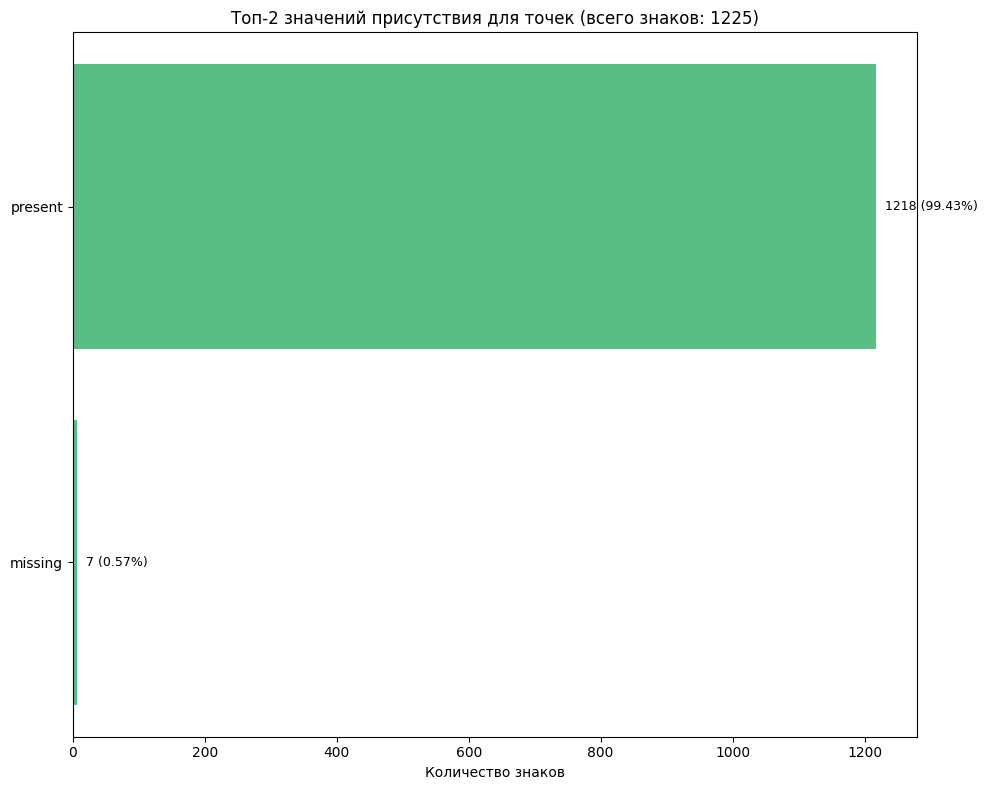

'period_presence_histogram.png'

In [743]:
visualize_presence_stats(period_presence_stats_df, 'period', total_periods_presence)

### Нормативность

In [744]:
period_normality_result = analyze_punctuation_normality(df_clean, 'period')

period_normality_lists = period_normality_result['punct_normality_lists']
total_periods_normality = period_normality_result['total_puncts_normality']
all_period_normality = period_normality_result['all_normality_values']
total_period_normality_values = period_normality_result['total_normality_values']
period_normality_counter = period_normality_result['normality_counter']
period_normality_stats_df = period_normality_result['normality_stats_df']

Анализ нормативности 'period':

   - Общее количество period: 1225
   - Уникальных значений нормативности: 4


In [745]:
print("Статистика по нормативности точек:\n")
print(period_normality_stats_df.to_string(index=False))

Статистика по нормативности точек:

Нормативность  Количество  Доля (%)
      correct        1196     97.63
          ind          14      1.14
      mistake          13      1.06
         typo           2      0.16


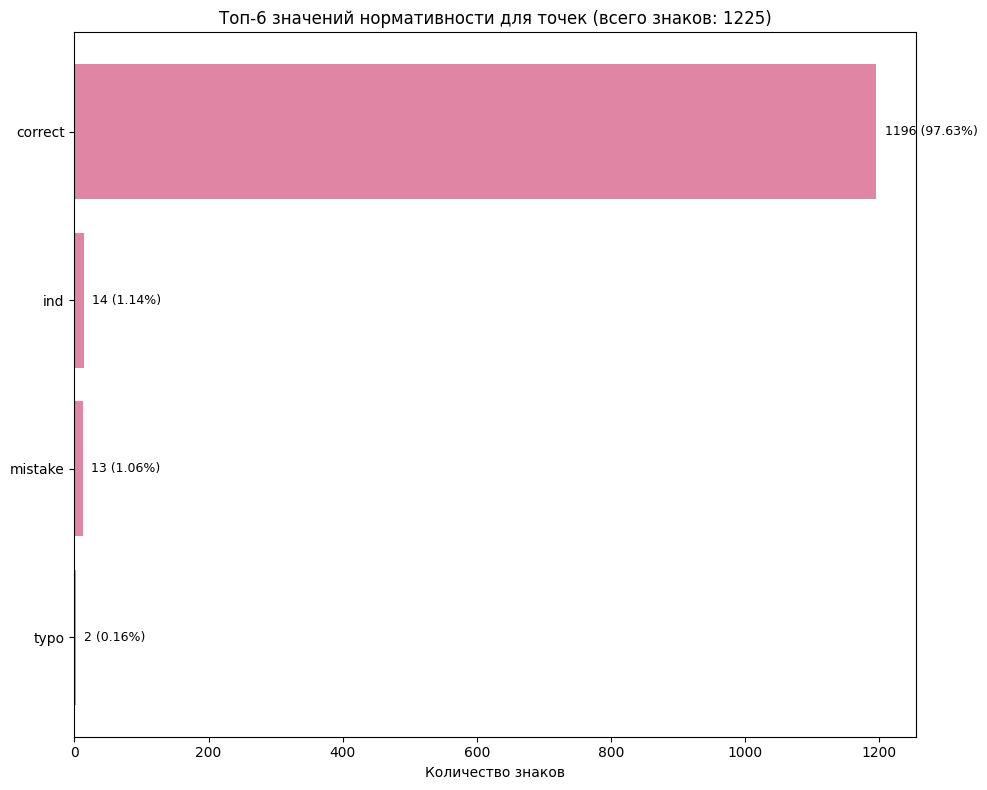

'period_normality_histogram.png'

In [746]:
visualize_normality_stats(period_normality_stats_df, 'period', total_periods_normality)

### Степень уверенности

In [747]:
period_reliance_result = analyze_punctuation_reliance(df_clean, 'period', total_puncts_expected=total_periods)

period_reliance_lists = period_reliance_result['punct_reliance_lists']
total_periods_reliance = period_reliance_result['total_puncts_reliance']
all_period_reliance = period_reliance_result['all_reliance_values']
total_period_reliance_values = period_reliance_result['total_reliance_values']
period_reliance_counter = period_reliance_result['reliance_counter']
period_reliance_stats_df = period_reliance_result['reliance_stats_df']
coverage_pct = period_reliance_result['coverage_pct']

Анализ степени уверенности 'period':

   - Знаков с размеченной степенью уверенности: 73
   - Общее количество period (по функциям): 1224
   - Покрытие разметки степени уверенности: 5.96%
   - Уникальных значений степени уверенности: 1


In [748]:
print("Статистика по степени уверенности точек:\n")
print(period_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности точек:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high          73     100.0                   5.96


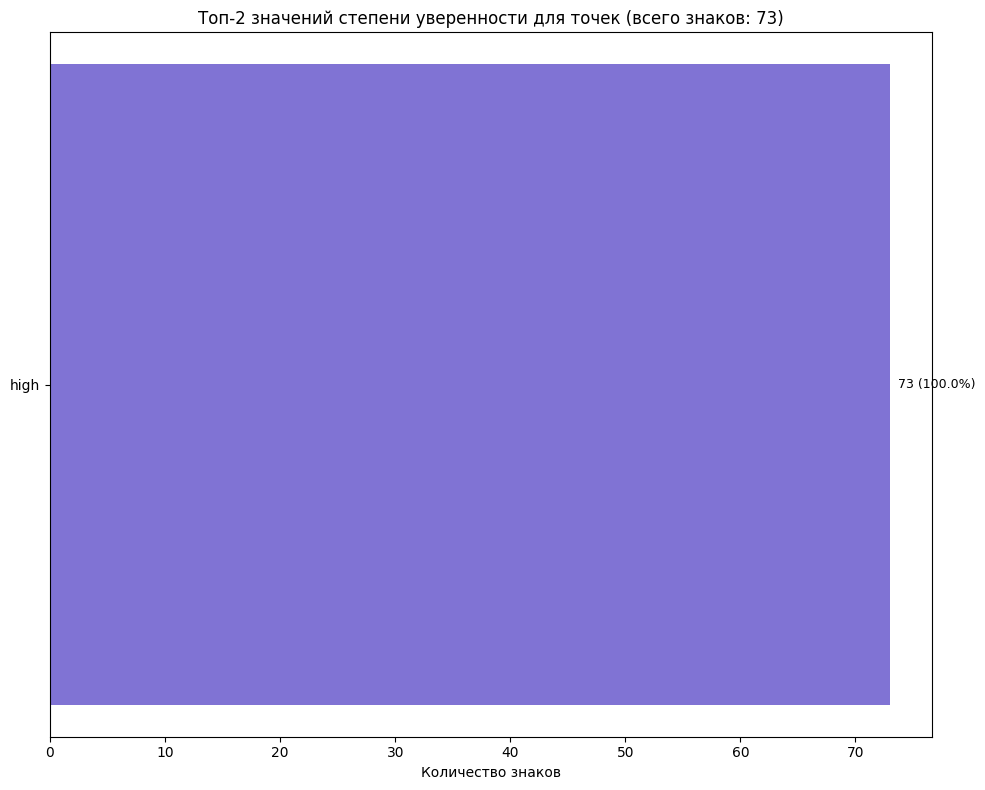

'period_reliance_histogram.png'

In [749]:
visualize_reliance_stats(period_reliance_stats_df, 'period', total_periods_reliance)

### Пробелы

In [750]:
period_spaces_result = analyze_punctuation_spaces(df_clean, 'period')

period_spaces_lists = period_spaces_result['punct_spaces_lists']
total_periods_spaces = period_spaces_result['total_puncts_spaces']
all_period_spaces = period_spaces_result['all_spaces_values']
total_period_spaces_values = period_spaces_result['total_spaces_values']
period_spaces_counter = period_spaces_result['spaces_counter']
period_spaces_stats_df = period_spaces_result['spaces_stats_df']

Анализ пробелов 'period':

   - Общее количество period: 1204
   - Уникальных значений пробелов: 4


In [751]:
print("Статистика по пробелам после точек:\n")
print(period_spaces_stats_df.to_string(index=False))

Статистика по пробелам после точек:

   Пробел  Количество  Доля (%)
    right         799     66.36
     zero         393     32.64
bilateral           7      0.58
     left           5      0.42


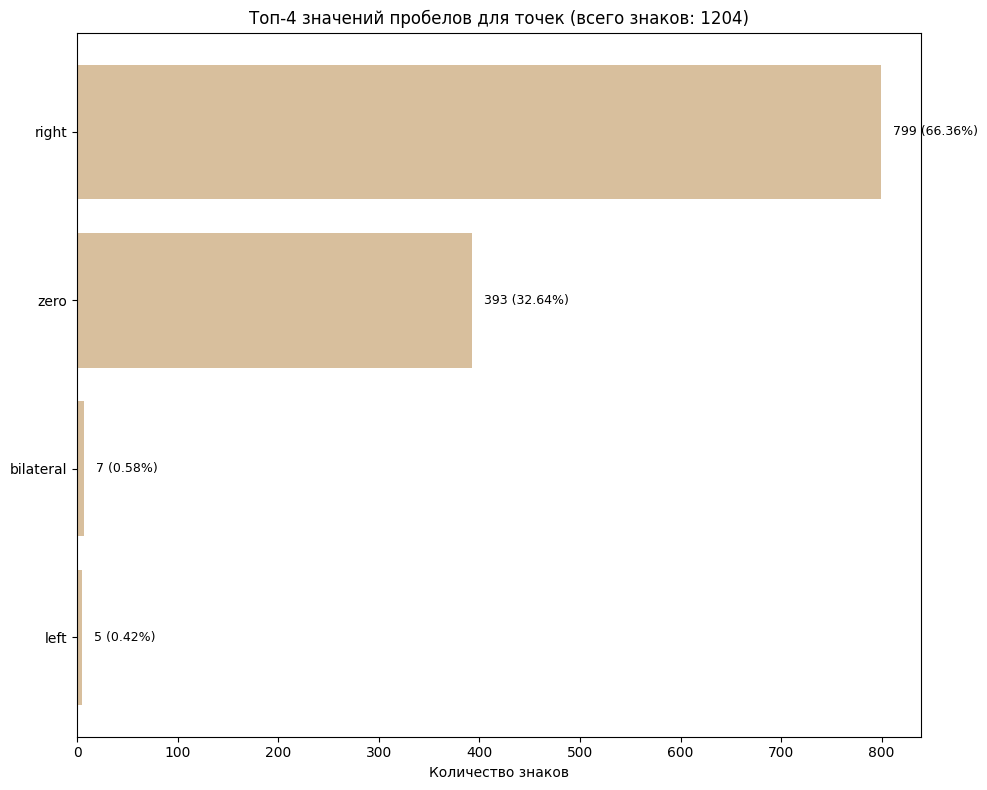

'period_spaces_histogram.png'

In [752]:
visualize_spaces_stats(period_spaces_stats_df, 'period', total_periods_spaces)

## Запятая

### Функции знака

In [753]:
comma_func_result = analyze_punctuation_func(df_clean, 'comma')

comma_func_lists = comma_func_result['punct_lists']
total_commas = comma_func_result['total_puncts']
all_comma_functions = comma_func_result['all_functions']
total_comma_functions = comma_func_result['total_functions']
comma_func_counter = comma_func_result['func_counter']
comma_func_stats_df = comma_func_result['func_stats_df']

Анализ функций 'comma':

   - Общее количество comma: 626
   - Общее количество функций (с повторениями): 864
   - Среднее количество функций на знак: 1.38
   - Уникальных функций: 57


In [754]:
print("Статистика по функциям запятых:\n")
print(comma_func_stats_df.to_string(index=False))

Статистика по функциям запятых:

         Функция  Количество  Доля (%)
           equal         142     16.44
          subord         125     14.47
       expletive          90     10.42
   determ_clause          45      5.21
    interjection          34      3.94
          compos          34      3.94
        no_union          30      3.47
      participle          30      3.47
   explan_clause          29      3.36
        vocative          28      3.24
   oppos_clauses          25      2.89
     cond_clause          20      2.31
       specifier          19      2.20
  adv_participle          18      2.08
          biblio          18      2.08
       attribute          13      1.50
     seq_clauses          11      1.27
          explan          11      1.27
   equal_clauses           9      1.04
parallel_clauses           8      0.93
            join           8      0.93
     time_clause           8      0.93
  united_clauses           7      0.81
              no           7   

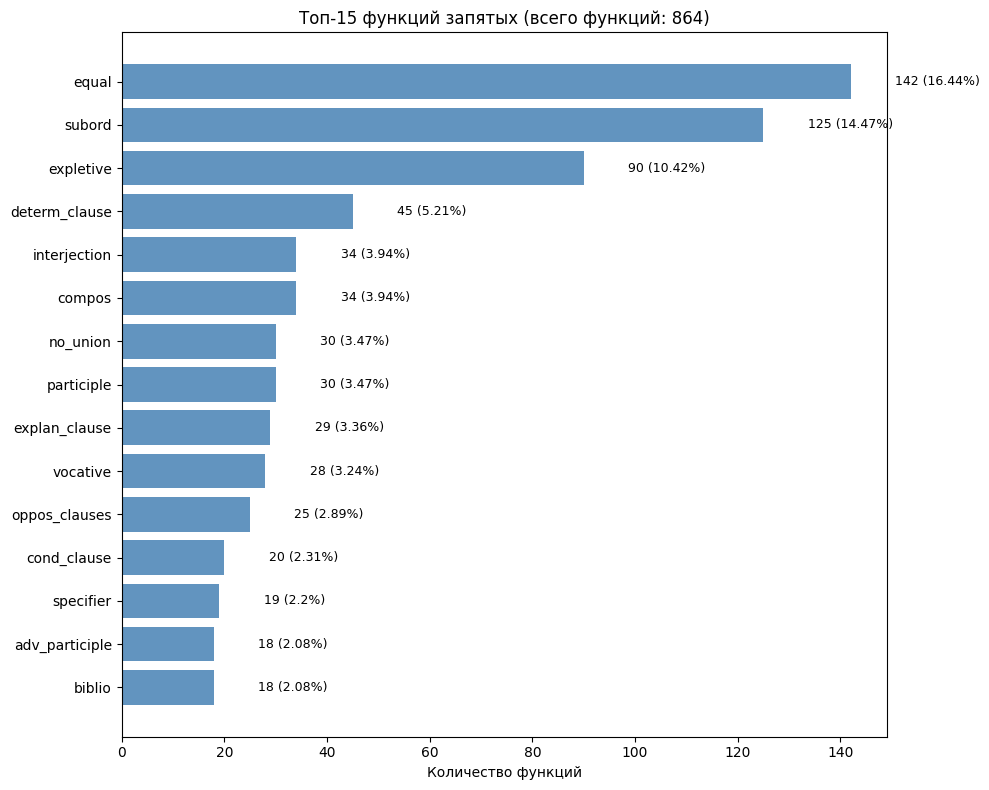

'comma_functions_histogram.png'

In [755]:
visualize_punct_functions(comma_func_stats_df, 'comma', total_comma_functions)

### Постановка/непостановка

In [756]:
comma_presence_result = analyze_punctuation_presence(df_clean, 'comma')

comma_presence_lists = comma_presence_result['punct_presence_lists']
total_commas_presence = comma_presence_result['total_puncts_presence']
all_comma_presence = comma_presence_result['all_presence_values']
total_comma_presence_values = comma_presence_result['total_presence_values']
comma_presence_counter = comma_presence_result['presence_counter']
comma_presence_stats_df = comma_presence_result['presence_stats_df']

Анализ присутствия 'comma':

   - Общее количество comma: 633
   - Уникальных значений присутствия: 2


In [757]:
print("Статистика по присутствию запятых:\n")
print(comma_presence_stats_df.to_string(index=False))

Статистика по присутствию запятых:

Присутствие  Количество  Доля (%)
    present         565     89.26
    missing          68     10.74


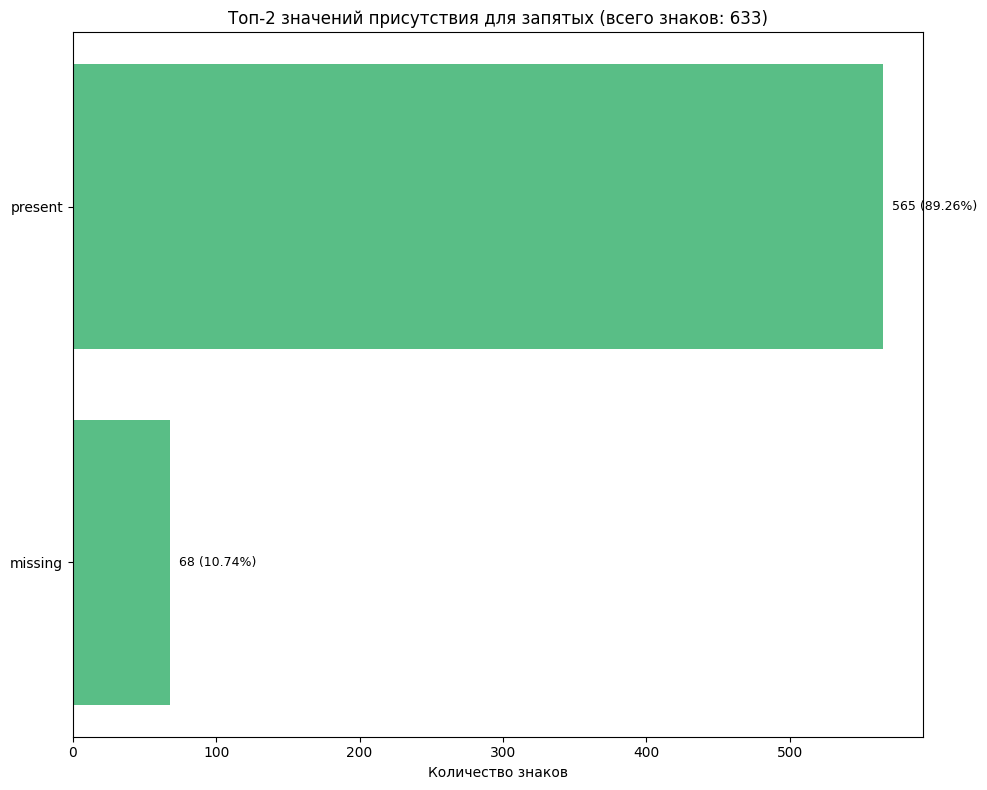

'comma_presence_histogram.png'

In [758]:
visualize_presence_stats(comma_presence_stats_df, 'comma', total_commas_presence)

### Нормативность

In [759]:
comma_normality_result = analyze_punctuation_normality(df_clean, 'comma')

comma_normality_lists = comma_normality_result['punct_normality_lists']
total_commas_normality = comma_normality_result['total_puncts_normality']
all_comma_normality = comma_normality_result['all_normality_values']
total_comma_normality_values = comma_normality_result['total_normality_values']
comma_normality_counter = comma_normality_result['normality_counter']
comma_normality_stats_df = comma_normality_result['normality_stats_df']

Анализ нормативности 'comma':

   - Общее количество comma: 636
   - Уникальных значений нормативности: 5


In [760]:
print("Статистика по нормативности запятых:\n")
print(comma_normality_stats_df.to_string(index=False))

Статистика по нормативности запятых:

Нормативность  Количество  Доля (%)
      correct         543     85.38
      mistake          57      8.96
          var          29      4.56
          alt           6      0.94
       facult           1      0.16


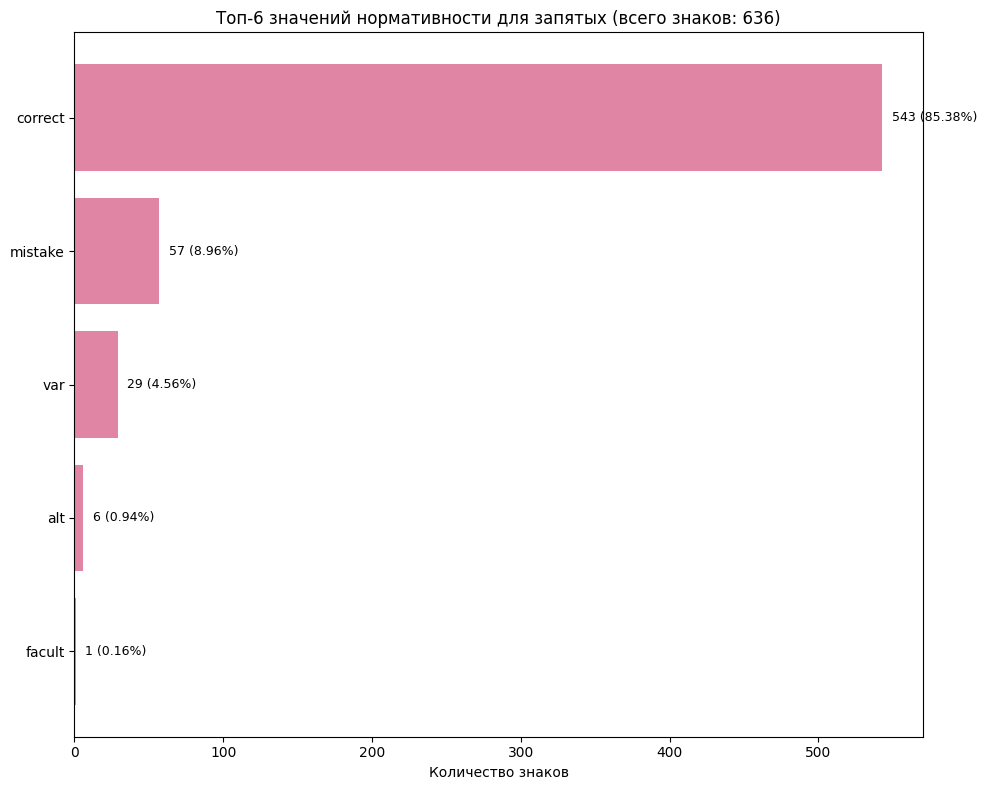

'comma_normality_histogram.png'

In [761]:
visualize_normality_stats(comma_normality_stats_df, 'comma', total_commas_normality)

### Степень уверенности

In [762]:
comma_reliance_result = analyze_punctuation_reliance(df_clean, 'comma', total_puncts_expected=total_commas)

comma_reliance_lists = comma_reliance_result['punct_reliance_lists']
total_commas_reliance = comma_reliance_result['total_puncts_reliance']
all_comma_reliance = comma_reliance_result['all_reliance_values']
total_comma_reliance_values = comma_reliance_result['total_reliance_values']
comma_reliance_counter = comma_reliance_result['reliance_counter']
comma_reliance_stats_df = comma_reliance_result['reliance_stats_df']
coverage_pct = comma_reliance_result['coverage_pct']

Анализ степени уверенности 'comma':

   - Знаков с размеченной степенью уверенности: 161
   - Общее количество comma (по функциям): 626
   - Покрытие разметки степени уверенности: 25.72%
   - Уникальных значений степени уверенности: 2


In [763]:
print("Статистика по степени уверенности запятых:\n")
print(comma_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности запятых:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high         158     98.14                  25.72
                low           3      1.86                  25.72


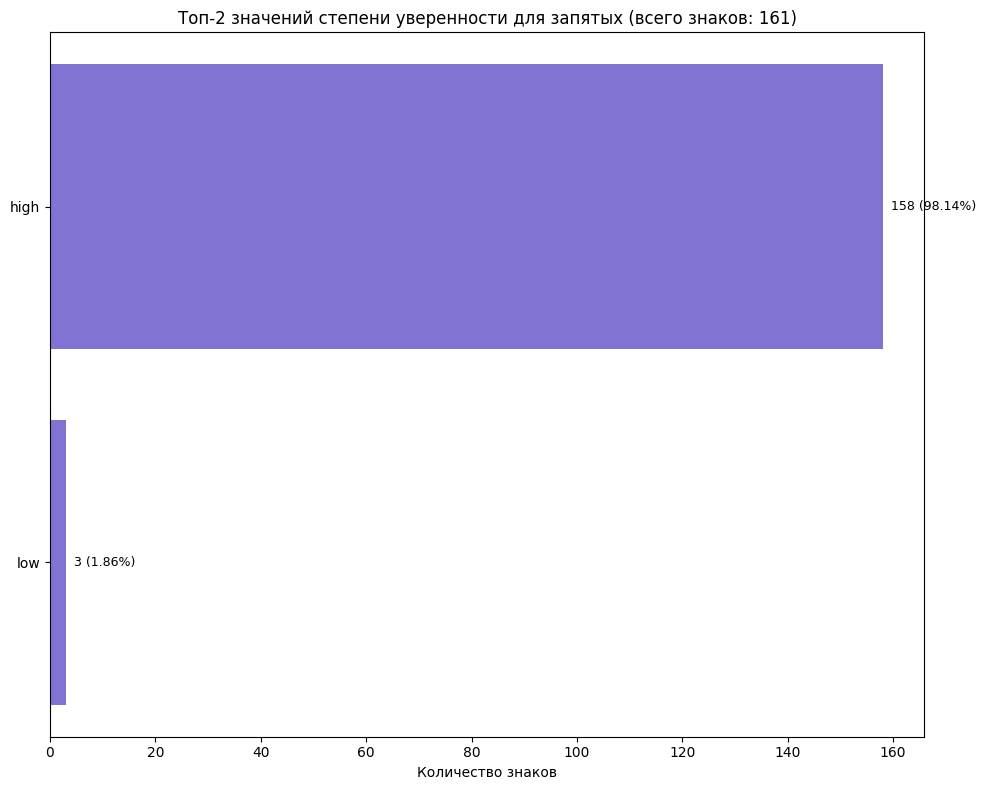

'comma_reliance_histogram.png'

In [764]:
visualize_reliance_stats(comma_reliance_stats_df, 'comma', total_commas_reliance)

### Пробелы

In [765]:
comma_spaces_result = analyze_punctuation_spaces(df_clean, 'comma')

comma_spaces_lists = comma_spaces_result['punct_spaces_lists']
total_commas_spaces = comma_spaces_result['total_puncts_spaces']
all_comma_spaces = comma_spaces_result['all_spaces_values']
total_comma_spaces_values = comma_spaces_result['total_spaces_values']
comma_spaces_counter = comma_spaces_result['spaces_counter']
comma_spaces_stats_df = comma_spaces_result['spaces_stats_df']

Анализ пробелов 'comma':

   - Общее количество comma: 636
   - Уникальных значений пробелов: 4


In [766]:
print("Статистика по пробелам после запятых:\n")
print(comma_spaces_stats_df.to_string(index=False))

Статистика по пробелам после запятых:

   Пробел  Количество  Доля (%)
    right         624     98.11
bilateral          10      1.57
     left           1      0.16
     zero           1      0.16


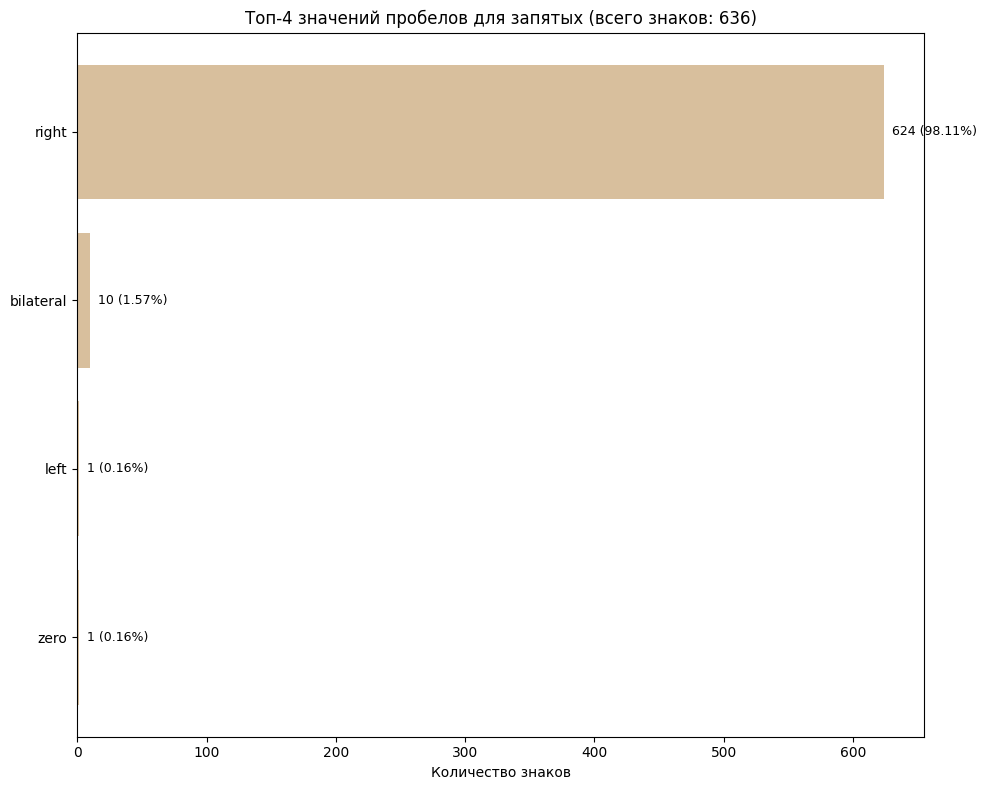

'comma_spaces_histogram.png'

In [767]:
visualize_spaces_stats(comma_spaces_stats_df, 'comma', total_commas_spaces)

## Восклицательный знак

### Функции знака

In [768]:
exclam_func_result = analyze_punctuation_func(df_clean, 'exclam')

exclam_func_lists = exclam_func_result['punct_lists']
total_exclams = exclam_func_result['total_puncts']
all_exclam_functions = exclam_func_result['all_functions']
total_exclam_functions = exclam_func_result['total_functions']
exclam_func_counter = exclam_func_result['func_counter']
exclam_func_stats_df = exclam_func_result['func_stats_df']

Анализ функций 'exclam':

   - Общее количество exclam: 134
   - Общее количество функций (с повторениями): 296
   - Среднее количество функций на знак: 2.21
   - Уникальных функций: 5


In [769]:
print("Статистика по функциям восклицательных знаков:\n")
print(exclam_func_stats_df.to_string(index=False))

Статистика по функциям восклицательных знаков:

 Функция  Количество  Доля (%)
end_sent         135     45.61
  exclam         134     45.27
    comb          13      4.39
 emotion           7      2.36
    loud           7      2.36


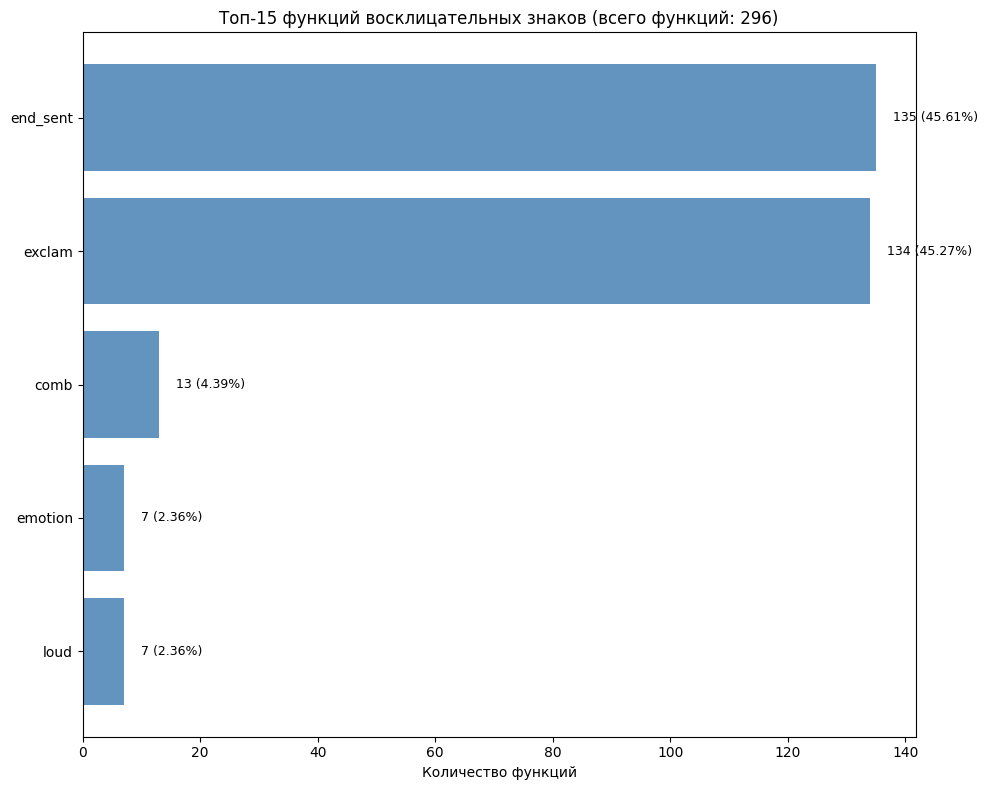

'exclam_functions_histogram.png'

In [770]:
visualize_punct_functions(exclam_func_stats_df, 'exclam', total_exclam_functions)

### Постановка/непостановка

In [771]:
exclam_presence_result = analyze_punctuation_presence(df_clean, 'exclam')

exclam_presence_lists = exclam_presence_result['punct_presence_lists']
total_exclams_presence = exclam_presence_result['total_puncts_presence']
all_exclam_presence = exclam_presence_result['all_presence_values']
total_exclam_presence_values = exclam_presence_result['total_presence_values']
exclam_presence_counter = exclam_presence_result['presence_counter']
exclam_presence_stats_df = exclam_presence_result['presence_stats_df']

Анализ присутствия 'exclam':

   - Общее количество exclam: 134
   - Уникальных значений присутствия: 2


In [772]:
print("Статистика по присутствию восклицательных знаков:\n")
print(exclam_presence_stats_df.to_string(index=False))

Статистика по присутствию восклицательных знаков:

Присутствие  Количество  Доля (%)
    present         133     99.25
    missing           1      0.75


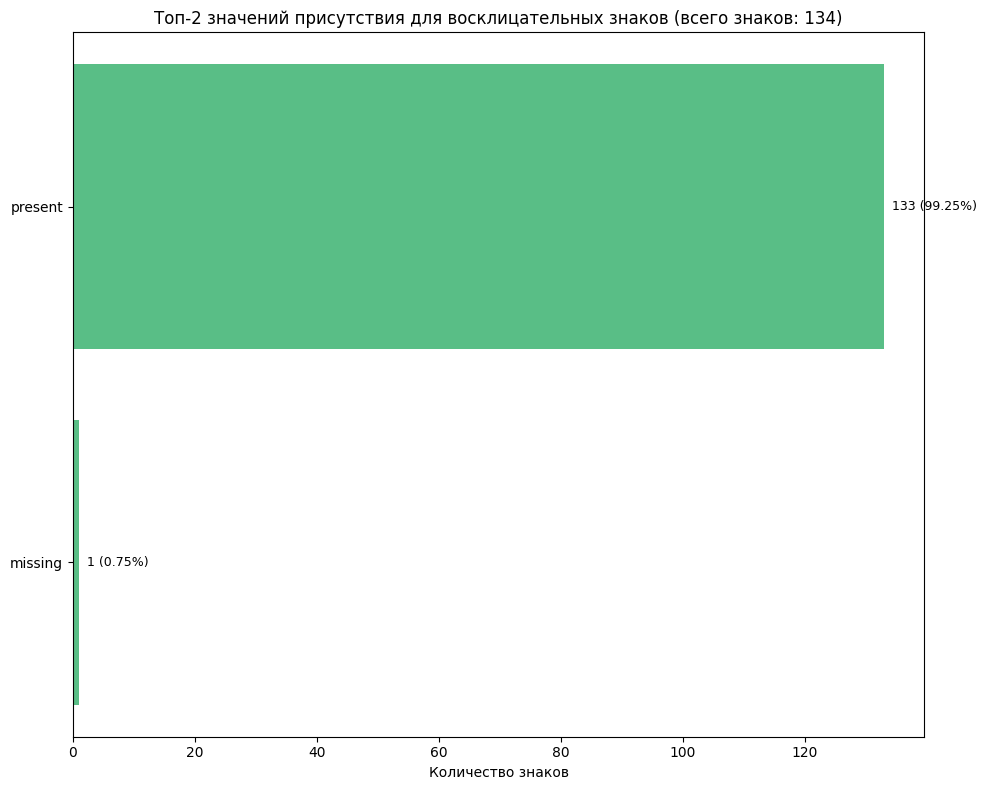

'exclam_presence_histogram.png'

In [773]:
visualize_presence_stats(exclam_presence_stats_df, 'exclam', total_exclams_presence)

### Нормативность

In [774]:
exclam_normality_result = analyze_punctuation_normality(df_clean, 'exclam')

exclam_normality_lists = exclam_normality_result['punct_normality_lists']
total_exclams_normality = exclam_normality_result['total_puncts_normality']
all_exclam_normality = exclam_normality_result['all_normality_values']
total_exclam_normality_values = exclam_normality_result['total_normality_values']
exclam_normality_counter = exclam_normality_result['normality_counter']
exclam_normality_stats_df = exclam_normality_result['normality_stats_df']

Анализ нормативности 'exclam':

   - Общее количество exclam: 134
   - Уникальных значений нормативности: 2


In [775]:
print("Статистика по нормативности восклицательных знаков:\n")
print(exclam_normality_stats_df.to_string(index=False))

Статистика по нормативности восклицательных знаков:

Нормативность  Количество  Доля (%)
      correct         131     97.76
          ind           3      2.24


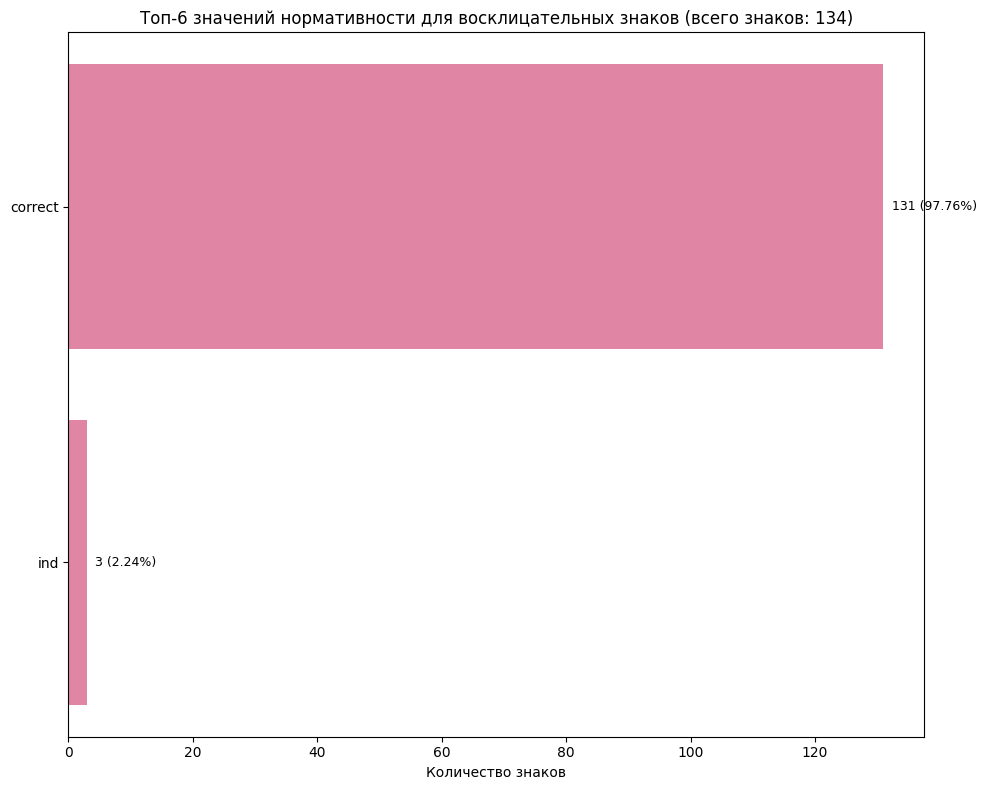

'exclam_normality_histogram.png'

In [776]:
visualize_normality_stats(exclam_normality_stats_df, 'exclam', total_exclams_normality)

### Степень уверенности

In [777]:
exclam_reliance_result = analyze_punctuation_reliance(df_clean, 'exclam', total_puncts_expected=total_exclams)

exclam_reliance_lists = exclam_reliance_result['punct_reliance_lists']
total_exclams_reliance = exclam_reliance_result['total_puncts_reliance']
all_exclam_reliance = exclam_reliance_result['all_reliance_values']
total_exclam_reliance_values = exclam_reliance_result['total_reliance_values']
exclam_reliance_counter = exclam_reliance_result['reliance_counter']
exclam_reliance_stats_df = exclam_reliance_result['reliance_stats_df']
coverage_pct = exclam_reliance_result['coverage_pct']

Анализ степени уверенности 'exclam':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество exclam (по функциям): 134
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [778]:
print("Статистика по степени уверенности восклицательных знаков:\n")
print(exclam_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности восклицательных знаков:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


In [779]:
# visualize_reliance_stats(exclam_reliance_stats_df, 'exclam', total_exclams_reliance)

### Пробелы

In [780]:
exclam_spaces_result = analyze_punctuation_spaces(df_clean, 'exclam')

exclam_spaces_lists = exclam_spaces_result['punct_spaces_lists']
total_exclams_spaces = exclam_spaces_result['total_puncts_spaces']
all_exclam_spaces = exclam_spaces_result['all_spaces_values']
total_exclam_spaces_values = exclam_spaces_result['total_spaces_values']
exclam_spaces_counter = exclam_spaces_result['spaces_counter']
exclam_spaces_stats_df = exclam_spaces_result['spaces_stats_df']

Анализ пробелов 'exclam':

   - Общее количество exclam: 131
   - Уникальных значений пробелов: 3


In [781]:
print("Статистика по пробелам после восклицательных знаков:\n")
print(exclam_spaces_stats_df.to_string(index=False))

Статистика по пробелам после восклицательных знаков:

Пробел  Количество  Доля (%)
 right         120     91.60
  zero           7      5.34
  left           4      3.05


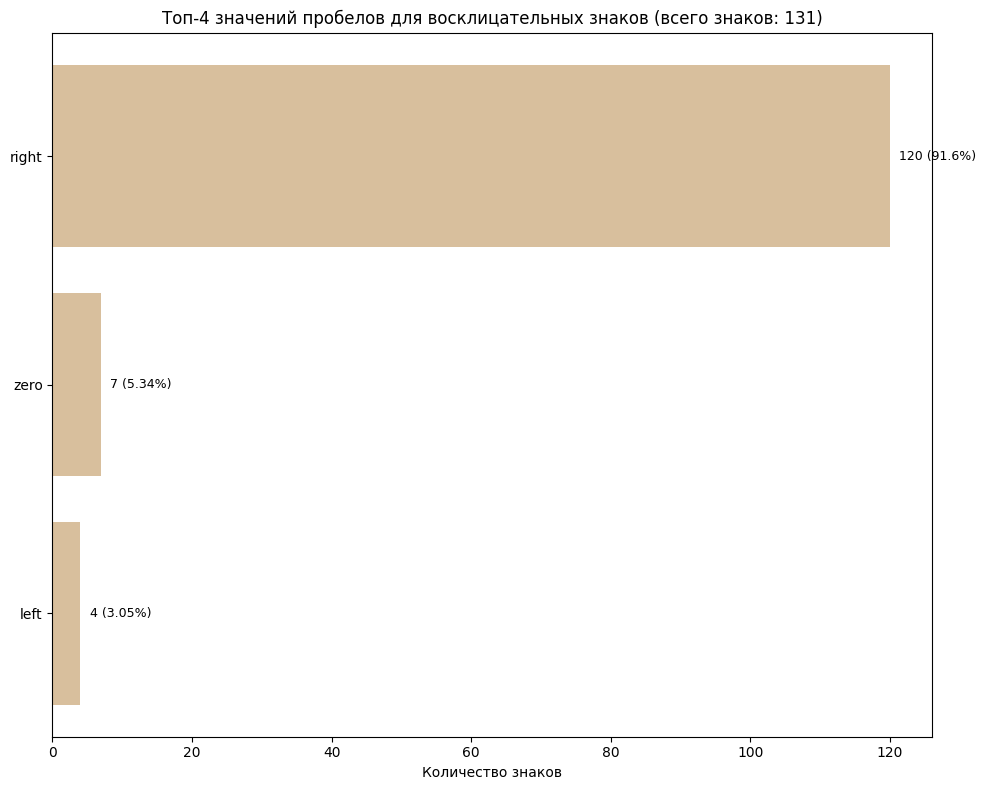

'exclam_spaces_histogram.png'

In [782]:
visualize_spaces_stats(exclam_spaces_stats_df, 'exclam', total_exclams_spaces)

## Вопросительный знак

### Функции знака

In [783]:
question_func_result = analyze_punctuation_func(df_clean, 'question')

question_func_lists = question_func_result['punct_lists']
total_questions = question_func_result['total_puncts']
all_question_functions = question_func_result['all_functions']
total_question_functions = question_func_result['total_functions']
question_func_counter = question_func_result['func_counter']
question_func_stats_df = question_func_result['func_stats_df']

Анализ функций 'question':

   - Общее количество question: 107
   - Общее количество функций (с повторениями): 215
   - Среднее количество функций на знак: 2.01
   - Уникальных функций: 3


In [784]:
print("Статистика по функциям восклицательных знаков:\n")
print(question_func_stats_df.to_string(index=False))

Статистика по функциям восклицательных знаков:

 Функция  Количество  Доля (%)
end_sent         107     49.77
question         107     49.77
    comb           1      0.47


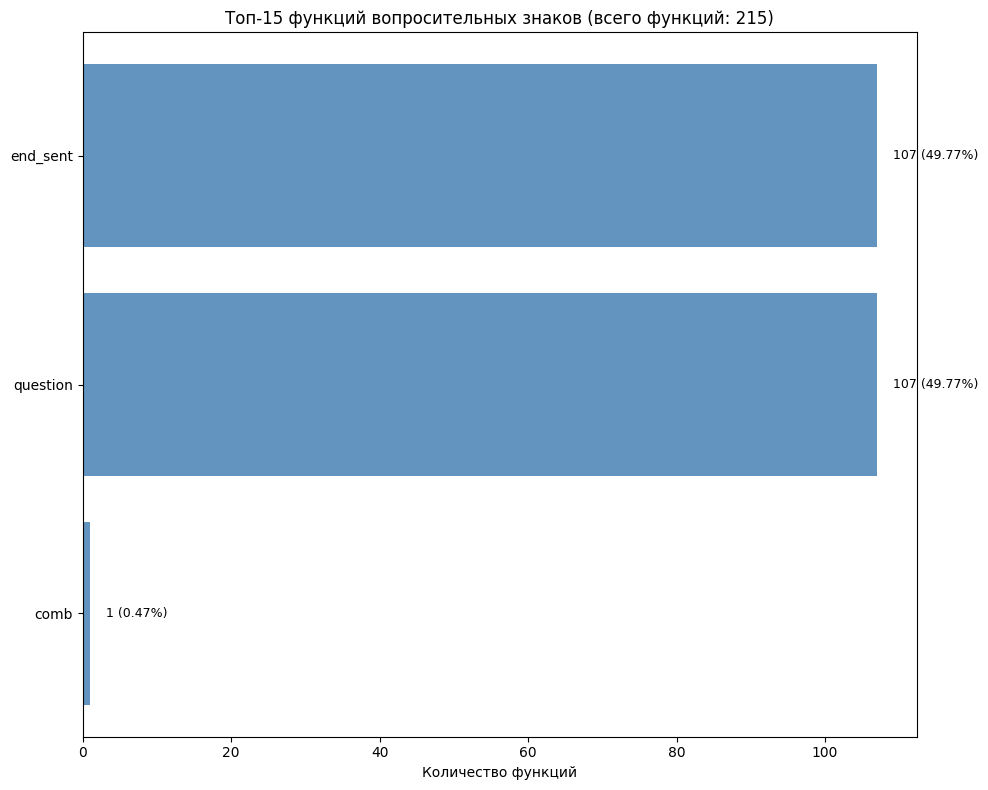

'question_functions_histogram.png'

In [785]:
visualize_punct_functions(question_func_stats_df, 'question', total_question_functions)

### Постановка/непостановка

In [786]:
question_presence_result = analyze_punctuation_presence(df_clean, 'question')

question_presence_lists = question_presence_result['punct_presence_lists']
total_questions_presence = question_presence_result['total_puncts_presence']
all_question_presence = question_presence_result['all_presence_values']
total_question_presence_values = question_presence_result['total_presence_values']
question_presence_counter = question_presence_result['presence_counter']
question_presence_stats_df = question_presence_result['presence_stats_df']

Анализ присутствия 'question':

   - Общее количество question: 106
   - Уникальных значений присутствия: 2


In [787]:
print("Статистика по присутствию вопросительных знаков:\n")
print(question_presence_stats_df.to_string(index=False))

Статистика по присутствию вопросительных знаков:

Присутствие  Количество  Доля (%)
    present         103     97.17
    missing           3      2.83


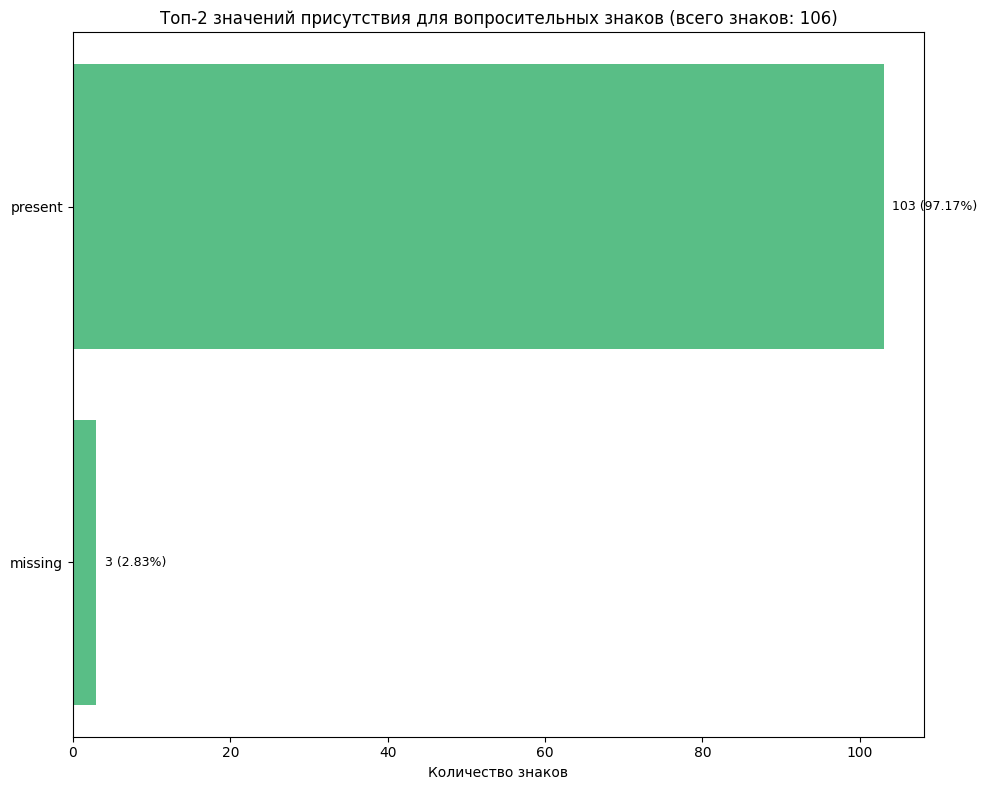

'question_presence_histogram.png'

In [788]:
visualize_presence_stats(question_presence_stats_df, 'question', total_questions_presence)

### Нормативность

In [789]:
question_normality_result = analyze_punctuation_normality(df_clean, 'question')

question_normality_lists = question_normality_result['punct_normality_lists']
total_questions_normality = question_normality_result['total_puncts_normality']
all_question_normality = question_normality_result['all_normality_values']
total_question_normality_values = question_normality_result['total_normality_values']
question_normality_counter = question_normality_result['normality_counter']
question_normality_stats_df = question_normality_result['normality_stats_df']

Анализ нормативности 'question':

   - Общее количество question: 99
   - Уникальных значений нормативности: 2


In [790]:
print("Статистика по нормативности вопросительных знаков:\n")
print(question_normality_stats_df.to_string(index=False))

Статистика по нормативности вопросительных знаков:

Нормативность  Количество  Доля (%)
      correct          96     96.97
          ind           3      3.03


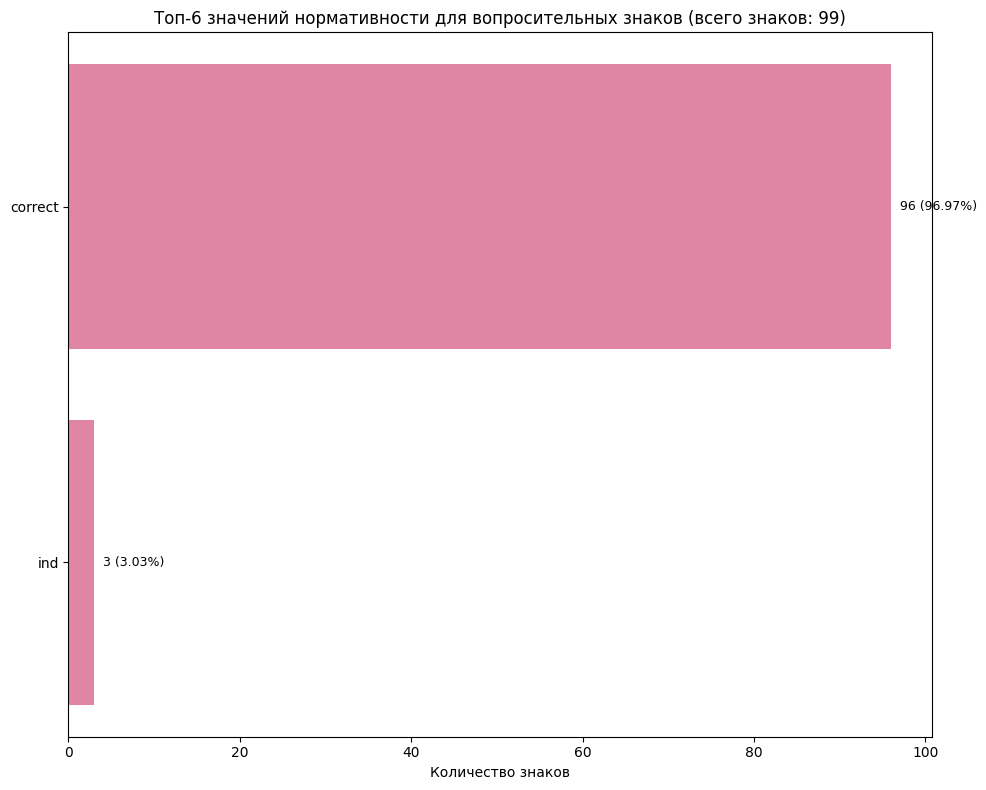

'question_normality_histogram.png'

In [791]:
visualize_normality_stats(question_normality_stats_df, 'question', total_questions_normality)

### Степень уверенности

In [792]:
question_reliance_result = analyze_punctuation_reliance(df_clean, 'question', total_puncts_expected=total_questions)

question_reliance_lists = question_reliance_result['punct_reliance_lists']
total_questions_reliance = question_reliance_result['total_puncts_reliance']
all_question_reliance = question_reliance_result['all_reliance_values']
total_question_reliance_values = question_reliance_result['total_reliance_values']
question_reliance_counter = question_reliance_result['reliance_counter']
question_reliance_stats_df = question_reliance_result['reliance_stats_df']
coverage_pct = question_reliance_result['coverage_pct']

Анализ степени уверенности 'question':

   - Знаков с размеченной степенью уверенности: 3
   - Общее количество question (по функциям): 107
   - Покрытие разметки степени уверенности: 2.8%
   - Уникальных значений степени уверенности: 1


In [793]:
print("Статистика по степени уверенности вопросительных знаков:\n")
print(question_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности вопросительных знаков:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           3     100.0                    2.8


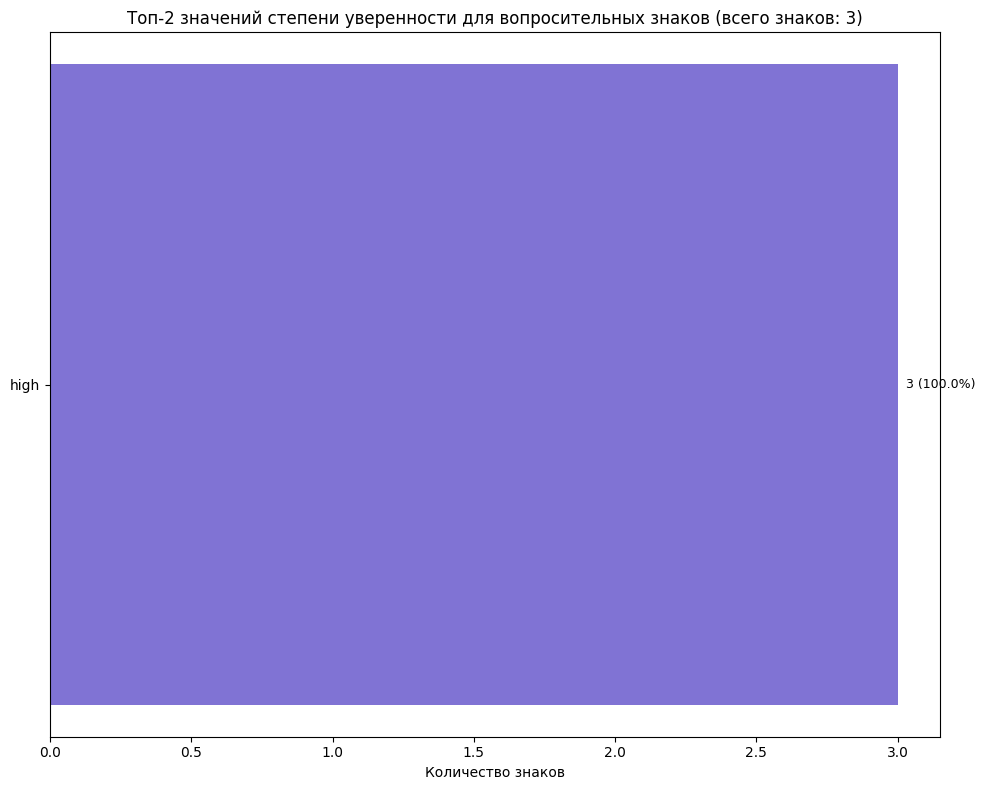

'question_reliance_histogram.png'

In [794]:
visualize_reliance_stats(question_reliance_stats_df, 'question', total_questions_reliance)

### Пробелы

In [795]:
question_spaces_result = analyze_punctuation_spaces(df_clean, 'question')

question_spaces_lists = question_spaces_result['punct_spaces_lists']
total_questions_spaces = question_spaces_result['total_puncts_spaces']
all_question_spaces = question_spaces_result['all_spaces_values']
total_question_spaces_values = question_spaces_result['total_spaces_values']
question_spaces_counter = question_spaces_result['spaces_counter']
question_spaces_stats_df = question_spaces_result['spaces_stats_df']

Анализ пробелов 'question':

   - Общее количество question: 106
   - Уникальных значений пробелов: 2


In [796]:
print("Статистика по пробелам после вопросительных знаков:\n")
print(question_spaces_stats_df.to_string(index=False))

Статистика по пробелам после вопросительных знаков:

Пробел  Количество  Доля (%)
 right         103     97.17
  zero           3      2.83


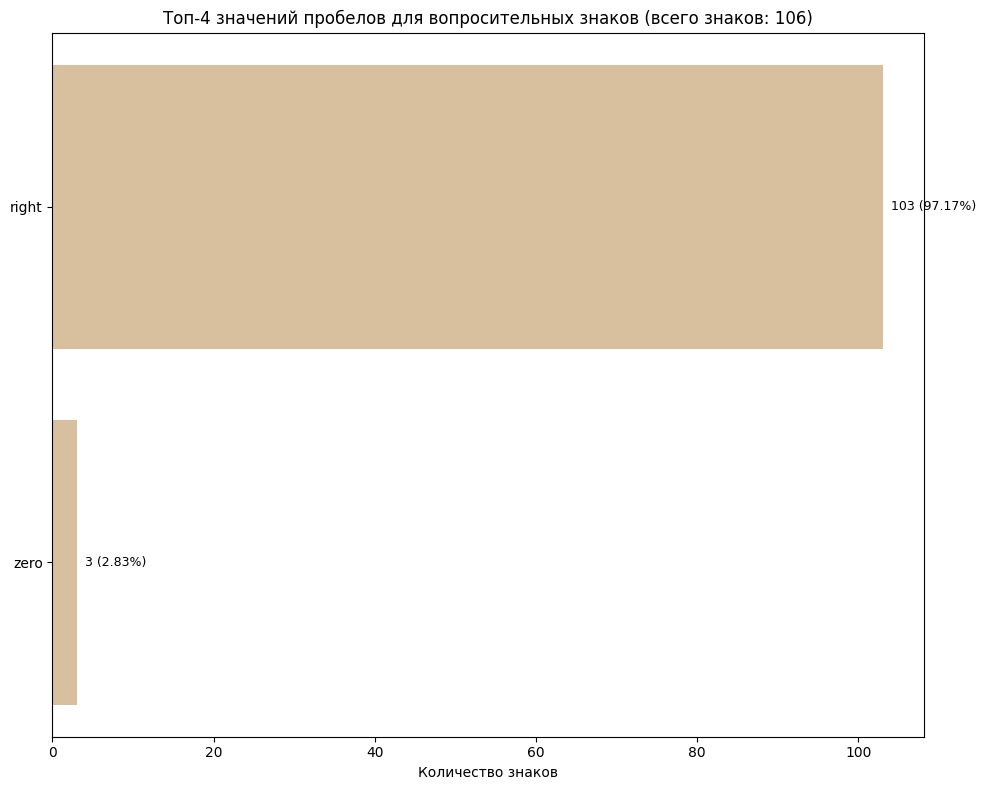

'question_spaces_histogram.png'

In [797]:
visualize_spaces_stats(question_spaces_stats_df, 'question', total_questions_spaces)

## Двоеточие

### Функции знака

In [798]:
colon_func_result = analyze_punctuation_func(df_clean, 'colon')

colon_func_lists = colon_func_result['punct_lists']
total_colons = colon_func_result['total_puncts']
all_colon_functions = colon_func_result['all_functions']
total_colon_functions = colon_func_result['total_functions']
colon_func_counter = colon_func_result['func_counter']
colon_func_stats_df = colon_func_result['func_stats_df']

Анализ функций 'colon':

   - Общее количество colon: 53
   - Общее количество функций (с повторениями): 66
   - Среднее количество функций на знак: 1.25
   - Уникальных функций: 11


In [799]:
print("Статистика по функциям двоеточий:\n")
print(colon_func_stats_df.to_string(index=False))

Статистика по функциям двоеточий:

             Функция  Количество  Доля (%)
              biblio          18     27.27
            no_union          13     19.70
              explan          12     18.18
        direct_start           7     10.61
       general_equal           5      7.58
               title           3      4.55
general_construction           3      4.55
                link           2      3.03
                join           1      1.52
              conces           1      1.52
     indirect_speech           1      1.52


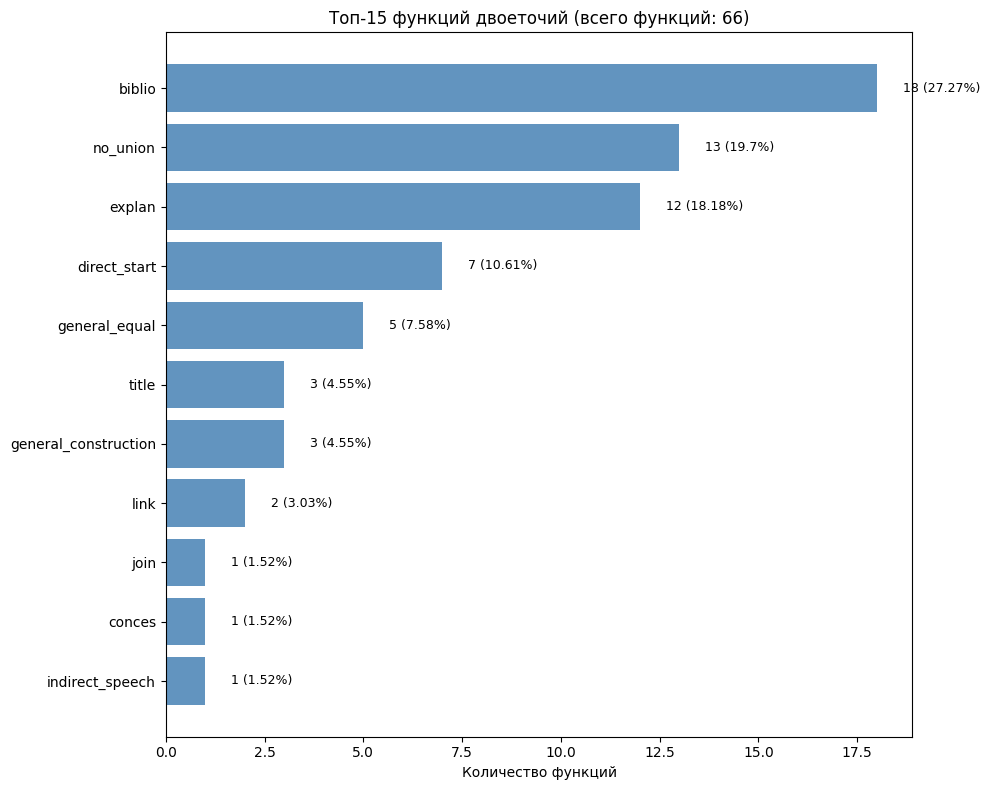

'colon_functions_histogram.png'

In [800]:
visualize_punct_functions(colon_func_stats_df, 'colon', total_colon_functions)

### Постановка/непостановка

In [801]:
colon_presence_result = analyze_punctuation_presence(df_clean, 'colon')

colon_presence_lists = colon_presence_result['punct_presence_lists']
total_colons_presence = colon_presence_result['total_puncts_presence']
all_colon_presence = colon_presence_result['all_presence_values']
total_colon_presence_values = colon_presence_result['total_presence_values']
colon_presence_counter = colon_presence_result['presence_counter']
colon_presence_stats_df = colon_presence_result['presence_stats_df']

Анализ присутствия 'colon':

   - Общее количество colon: 53
   - Уникальных значений присутствия: 2


In [802]:
print("Статистика по присутствию двоеточий:\n")
print(colon_presence_stats_df.to_string(index=False))

Статистика по присутствию двоеточий:

Присутствие  Количество  Доля (%)
    present          51     96.23
    missing           2      3.77


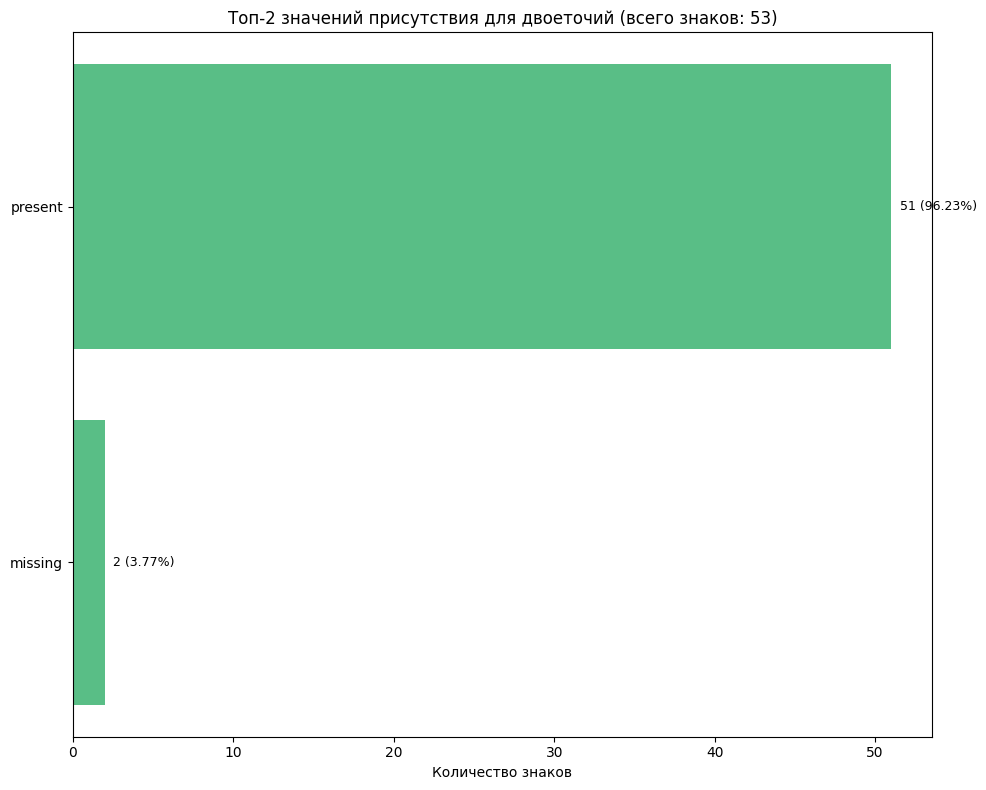

'colon_presence_histogram.png'

In [803]:
visualize_presence_stats(colon_presence_stats_df, 'colon', total_colons_presence)

### Нормативность

In [804]:
colon_normality_result = analyze_punctuation_normality(df_clean, 'colon')

colon_normality_lists = colon_normality_result['punct_normality_lists']
total_colons_normality = colon_normality_result['total_puncts_normality']
all_colon_normality = colon_normality_result['all_normality_values']
total_colon_normality_values = colon_normality_result['total_normality_values']
colon_normality_counter = colon_normality_result['normality_counter']
colon_normality_stats_df = colon_normality_result['normality_stats_df']

Анализ нормативности 'colon':

   - Общее количество colon: 50
   - Уникальных значений нормативности: 3


In [805]:
print("Статистика по нормативности двоеточий:\n")
print(colon_normality_stats_df.to_string(index=False))

Статистика по нормативности двоеточий:

Нормативность  Количество  Доля (%)
      correct          45      90.0
      mistake           4       8.0
       facult           1       2.0


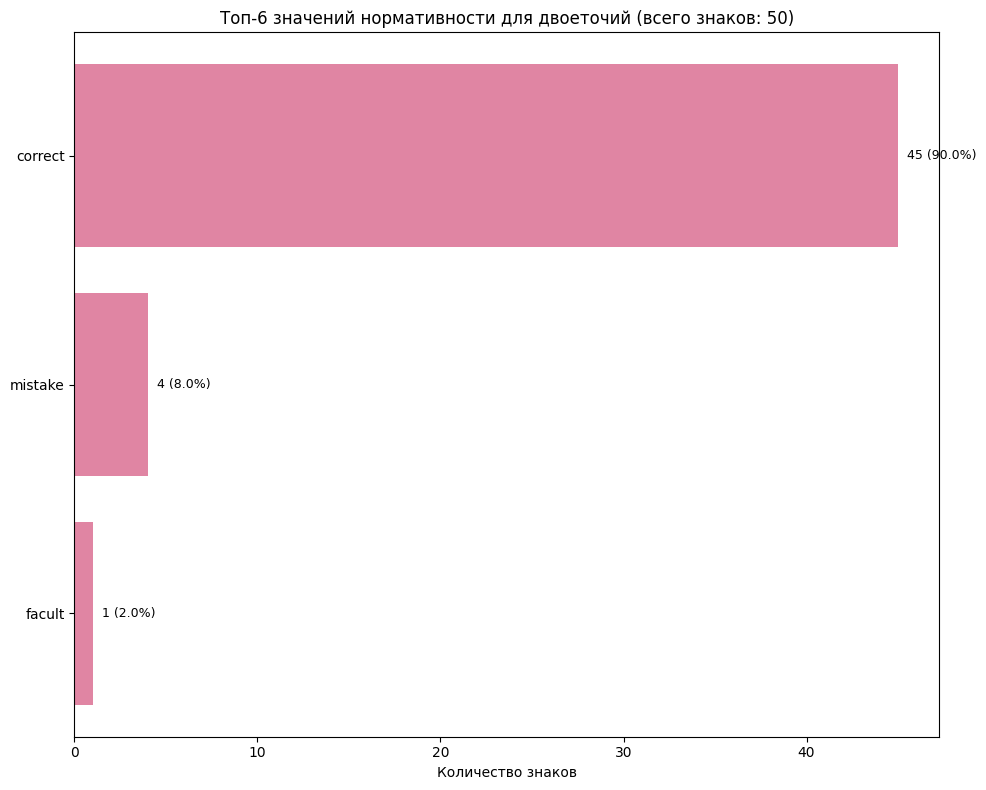

'colon_normality_histogram.png'

In [806]:
visualize_normality_stats(colon_normality_stats_df, 'colon', total_colons_normality)

### Степень уверенности

In [807]:
colon_reliance_result = analyze_punctuation_reliance(df_clean, 'colon', total_puncts_expected=total_colons)

colon_reliance_lists = colon_reliance_result['punct_reliance_lists']
total_colons_reliance = colon_reliance_result['total_puncts_reliance']
all_colon_reliance = colon_reliance_result['all_reliance_values']
total_colon_reliance_values = colon_reliance_result['total_reliance_values']
colon_reliance_counter = colon_reliance_result['reliance_counter']
colon_reliance_stats_df = colon_reliance_result['reliance_stats_df']
coverage_pct = colon_reliance_result['coverage_pct']

Анализ степени уверенности 'colon':

   - Знаков с размеченной степенью уверенности: 3
   - Общее количество colon (по функциям): 53
   - Покрытие разметки степени уверенности: 5.66%
   - Уникальных значений степени уверенности: 1


In [808]:
print("Статистика по степени уверенности двоеточий:\n")
print(colon_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности двоеточий:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           3     100.0                   5.66


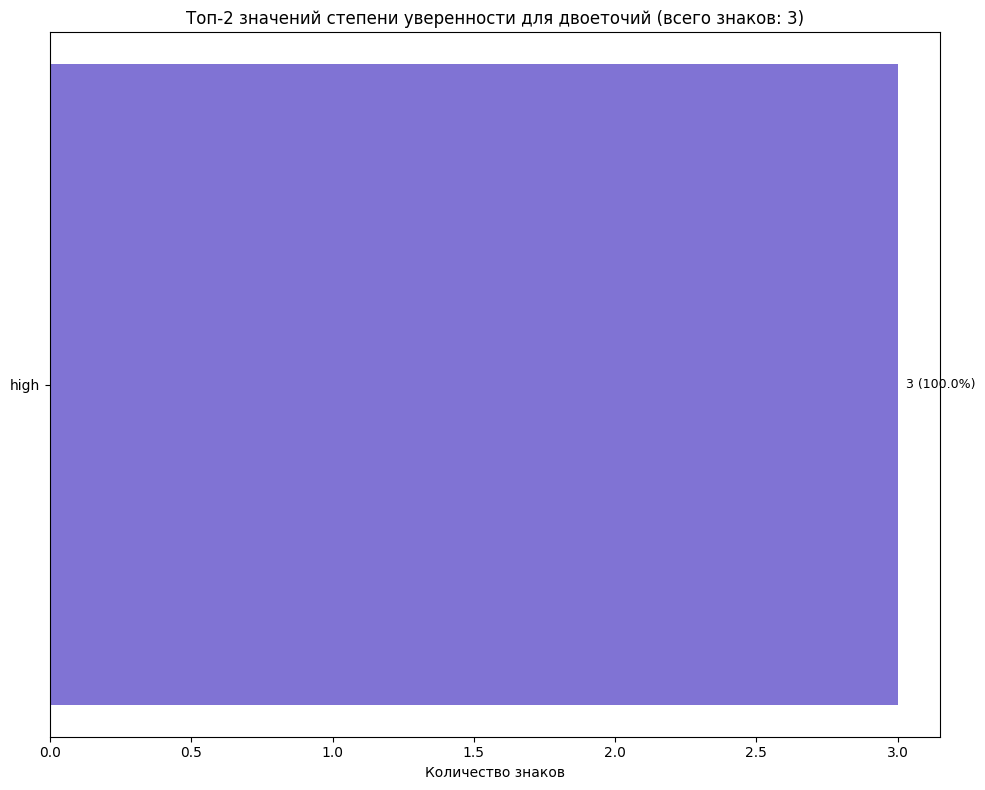

'colon_reliance_histogram.png'

In [809]:
visualize_reliance_stats(colon_reliance_stats_df, 'colon', total_colons_reliance)

### Пробелы

In [810]:
colon_spaces_result = analyze_punctuation_spaces(df_clean, 'colon')

colon_spaces_lists = colon_spaces_result['punct_spaces_lists']
total_colons_spaces = colon_spaces_result['total_puncts_spaces']
all_colon_spaces = colon_spaces_result['all_spaces_values']
total_colon_spaces_values = colon_spaces_result['total_spaces_values']
colon_spaces_counter = colon_spaces_result['spaces_counter']
colon_spaces_stats_df = colon_spaces_result['spaces_stats_df']

Анализ пробелов 'colon':

   - Общее количество colon: 49
   - Уникальных значений пробелов: 2


In [811]:
print("Статистика по пробелам после двоеточий:\n")
print(colon_spaces_stats_df.to_string(index=False))

Статистика по пробелам после двоеточий:

Пробел  Количество  Доля (%)
 right          48     97.96
  zero           1      2.04


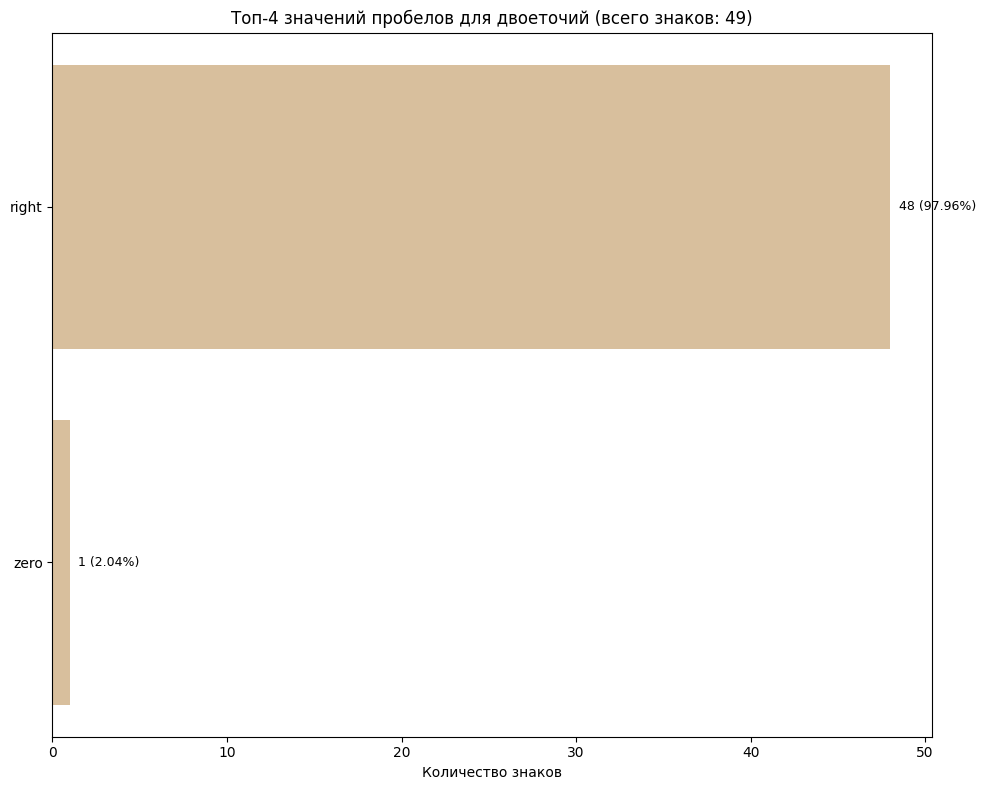

'colon_spaces_histogram.png'

In [812]:
visualize_spaces_stats(colon_spaces_stats_df, 'colon', total_colons_spaces)

## Точка с запятой

### Функции знака

In [813]:
semicolon_func_result = analyze_punctuation_func(df_clean, 'semicolon')

semicolon_func_lists = semicolon_func_result['punct_lists']
total_semicolons = semicolon_func_result['total_puncts']
all_semicolon_functions = semicolon_func_result['all_functions']
total_semicolon_functions = semicolon_func_result['total_functions']
semicolon_func_counter = semicolon_func_result['func_counter']
semicolon_func_stats_df = semicolon_func_result['func_stats_df']

Анализ функций 'semicolon':

   - Общее количество semicolon: 29
   - Общее количество функций (с повторениями): 30
   - Среднее количество функций на знак: 1.03
   - Уникальных функций: 5


In [814]:
print("Статистика по функциям точек с запятой:\n")
print(semicolon_func_stats_df.to_string(index=False))

Статистика по функциям точек с запятой:

      Функция  Количество  Доля (%)
equal_members          15     50.00
equal_clauses           7     23.33
         join           6     20.00
       explan           1      3.33
       biblio           1      3.33


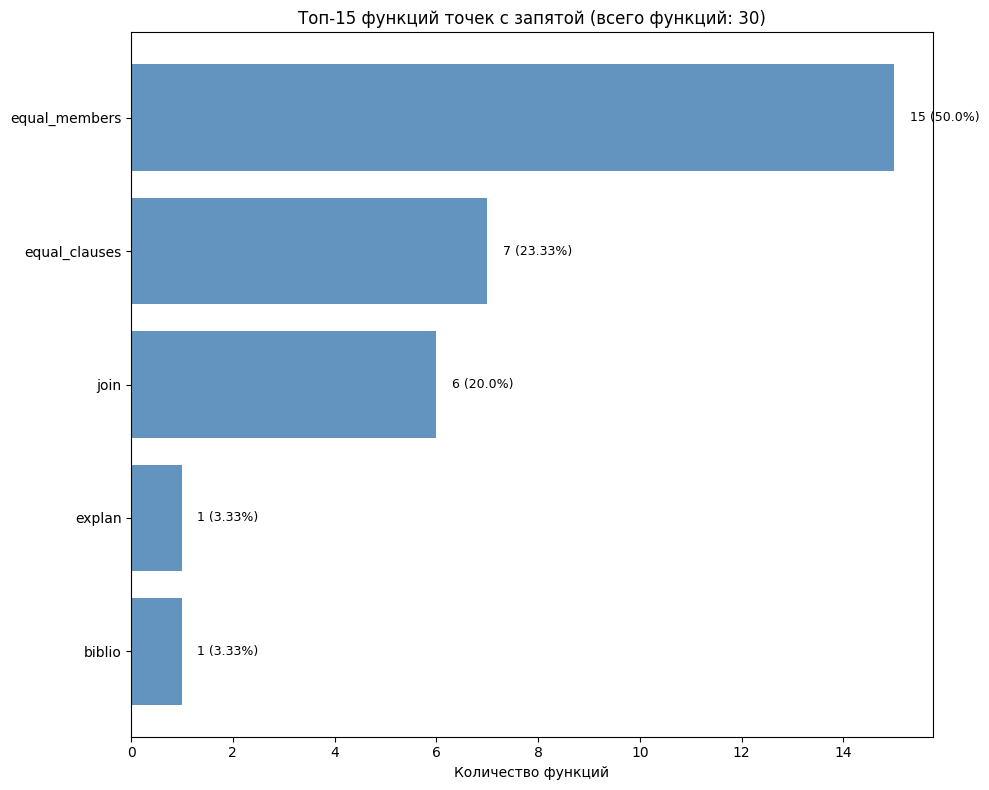

'semicolon_functions_histogram.png'

In [815]:
visualize_punct_functions(semicolon_func_stats_df, 'semicolon', total_semicolon_functions)

### Постановка/непостановка

In [816]:
semicolon_presence_result = analyze_punctuation_presence(df_clean, 'semicolon')

semicolon_presence_lists = semicolon_presence_result['punct_presence_lists']
total_semicolons_presence = semicolon_presence_result['total_puncts_presence']
all_semicolon_presence = semicolon_presence_result['all_presence_values']
total_semicolon_presence_values = semicolon_presence_result['total_presence_values']
semicolon_presence_counter = semicolon_presence_result['presence_counter']
semicolon_presence_stats_df = semicolon_presence_result['presence_stats_df']

Анализ присутствия 'semicolon':

   - Общее количество semicolon: 37
   - Уникальных значений присутствия: 1


In [817]:
print("Статистика по присутствию точек с запятой:\n")
print(semicolon_presence_stats_df.to_string(index=False))

Статистика по присутствию точек с запятой:

Присутствие  Количество  Доля (%)
    present          37     100.0


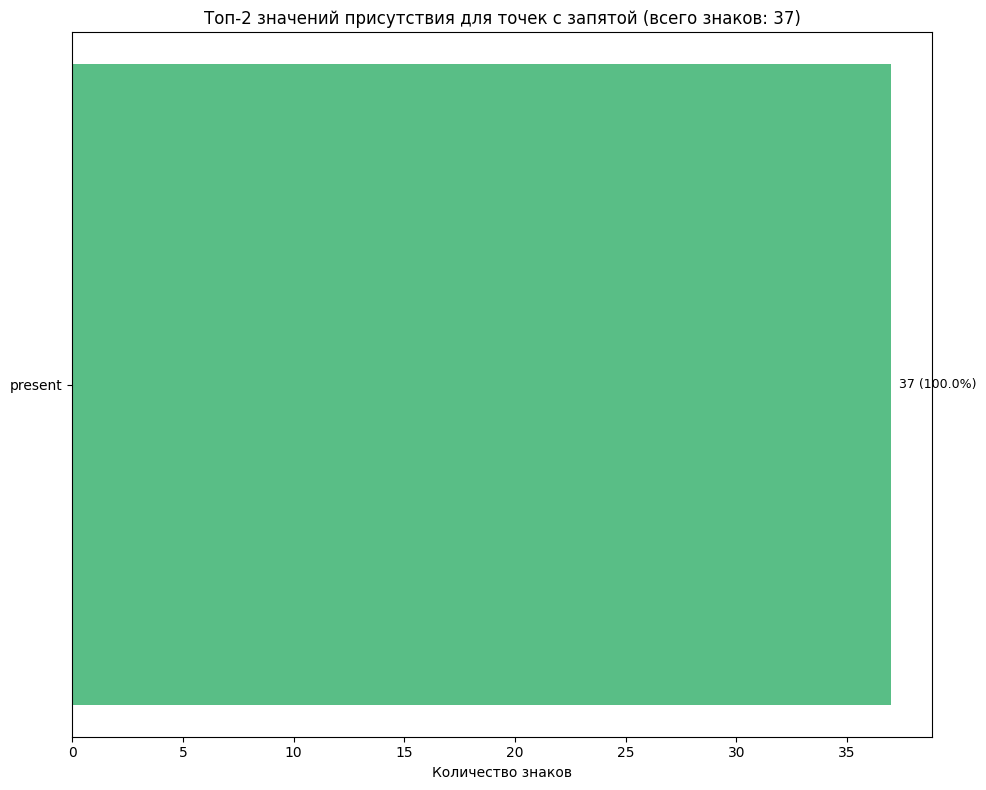

'semicolon_presence_histogram.png'

In [818]:
visualize_presence_stats(semicolon_presence_stats_df, 'semicolon', total_semicolons_presence)

### Нормативность

In [819]:
semicolon_normality_result = analyze_punctuation_normality(df_clean, 'semicolon')

semicolon_normality_lists = semicolon_normality_result['punct_normality_lists']
total_semicolons_normality = semicolon_normality_result['total_puncts_normality']
all_semicolon_normality = semicolon_normality_result['all_normality_values']
total_semicolon_normality_values = semicolon_normality_result['total_normality_values']
semicolon_normality_counter = semicolon_normality_result['normality_counter']
semicolon_normality_stats_df = semicolon_normality_result['normality_stats_df']

Анализ нормативности 'semicolon':

   - Общее количество semicolon: 37
   - Уникальных значений нормативности: 1


In [820]:
print("Статистика по нормативности точек с запятой:\n")
print(semicolon_normality_stats_df.to_string(index=False))

Статистика по нормативности точек с запятой:

Нормативность  Количество  Доля (%)
      correct          37     100.0


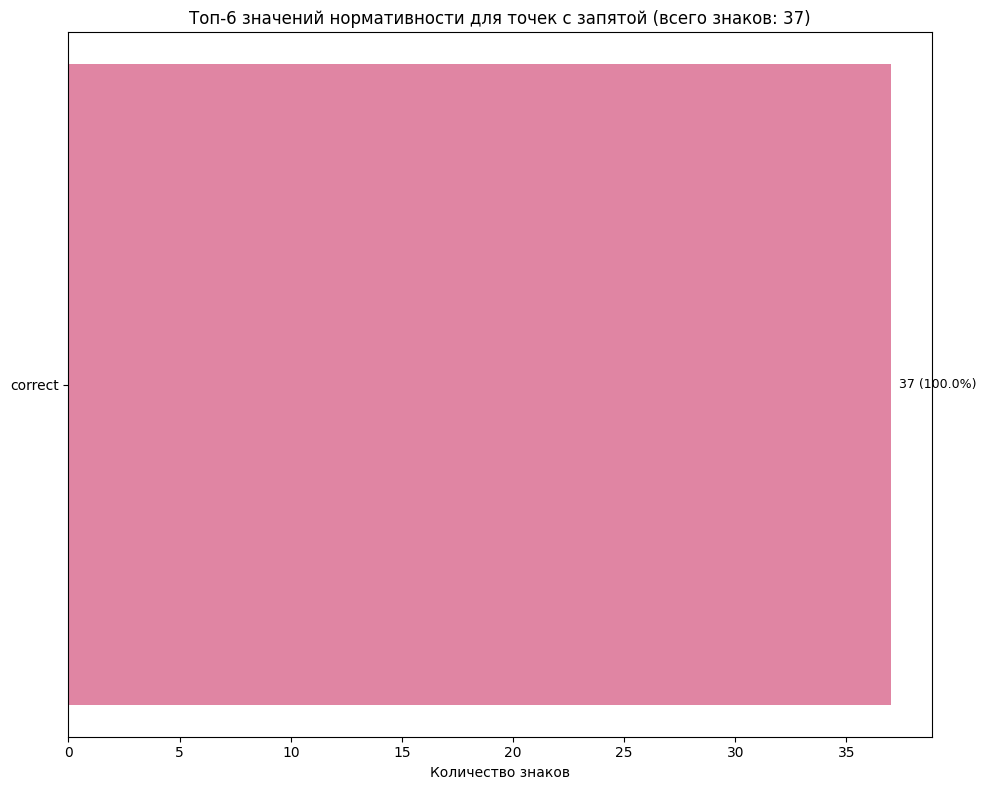

'semicolon_normality_histogram.png'

In [821]:
visualize_normality_stats(semicolon_normality_stats_df, 'semicolon', total_semicolons_normality)

### Степень уверенности

In [822]:
semicolon_reliance_result = analyze_punctuation_reliance(df_clean, 'semicolon',
                                                         total_puncts_expected=total_semicolons)

semicolon_reliance_lists = semicolon_reliance_result['punct_reliance_lists']
total_semicolons_reliance = semicolon_reliance_result['total_puncts_reliance']
all_semicolon_reliance = semicolon_reliance_result['all_reliance_values']
total_semicolon_reliance_values = semicolon_reliance_result['total_reliance_values']
semicolon_reliance_counter = semicolon_reliance_result['reliance_counter']
semicolon_reliance_stats_df = semicolon_reliance_result['reliance_stats_df']
coverage_pct = semicolon_reliance_result['coverage_pct']

Анализ степени уверенности 'semicolon':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество semicolon (по функциям): 29
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [823]:
print("Статистика по степени уверенности точек с запятой:\n")
print(semicolon_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности точек с запятой:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


In [824]:
# visualize_reliance_stats(semicolon_reliance_stats_df, 'semicolon', total_semicolons_reliance)

### Пробелы

In [825]:
semicolon_spaces_result = analyze_punctuation_spaces(df_clean, 'semicolon')

semicolon_spaces_lists = semicolon_spaces_result['punct_spaces_lists']
total_semicolons_spaces = semicolon_spaces_result['total_puncts_spaces']
all_semicolon_spaces = semicolon_spaces_result['all_spaces_values']
total_semicolon_spaces_values = semicolon_spaces_result['total_spaces_values']
semicolon_spaces_counter = semicolon_spaces_result['spaces_counter']
semicolon_spaces_stats_df = semicolon_spaces_result['spaces_stats_df']

Анализ пробелов 'semicolon':

   - Общее количество semicolon: 37
   - Уникальных значений пробелов: 1


In [826]:
print("Статистика по пробелам после точек с запятой:\n")
print(semicolon_spaces_stats_df.to_string(index=False))

Статистика по пробелам после точек с запятой:

Пробел  Количество  Доля (%)
 right          37     100.0


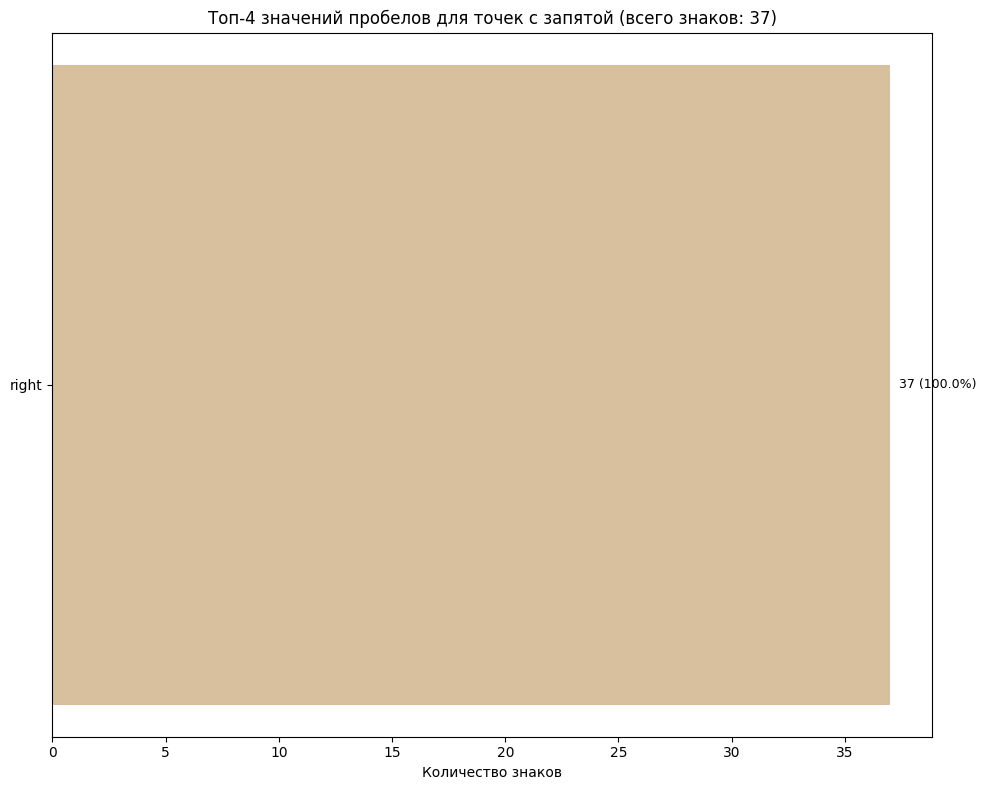

'semicolon_spaces_histogram.png'

In [827]:
visualize_spaces_stats(semicolon_spaces_stats_df, 'semicolon', total_semicolons_spaces)

## Тире

### Функции знака

In [828]:
dash_func_result = analyze_punctuation_func(df_clean, 'dash')

dash_func_lists = dash_func_result['punct_lists']
total_dashes = dash_func_result['total_puncts']
all_dash_functions = dash_func_result['all_functions']
total_dash_functions = dash_func_result['total_functions']
dash_func_counter = dash_func_result['func_counter']
dash_func_stats_df = dash_func_result['func_stats_df']

Анализ функций 'dash':

   - Общее количество dash: 310
   - Общее количество функций (с повторениями): 327
   - Среднее количество функций на знак: 1.05
   - Уникальных функций: 32


In [829]:
print("Статистика по функциям тире:\n")
print(dash_func_stats_df.to_string(index=False))

Статистика по функциям тире:

       Функция  Количество  Доля (%)
  dialog_start         116     35.47
     subj_pred          33     10.09
 average_pause          31      9.48
          list          27      8.26
  dialog_break          16      4.89
         blank          15      4.59
      no_union          14      4.28
subj_highlight          10      3.06
         range           9      2.75
    apposition           9      2.75
     attribute           6      1.83
        explan           6      1.83
      open_par           4      1.22
  direct_break           4      1.22
        conseq           4      1.22
 general_equal           3      0.92
     close_par           3      0.92
          cond           2      0.61
      fronting           2      0.61
    direct_end           1      0.31
         oppos           1      0.31
     adverbial           1      0.31
     expletive           1      0.31
      vocative           1      0.31
        reason           1      0.31
        

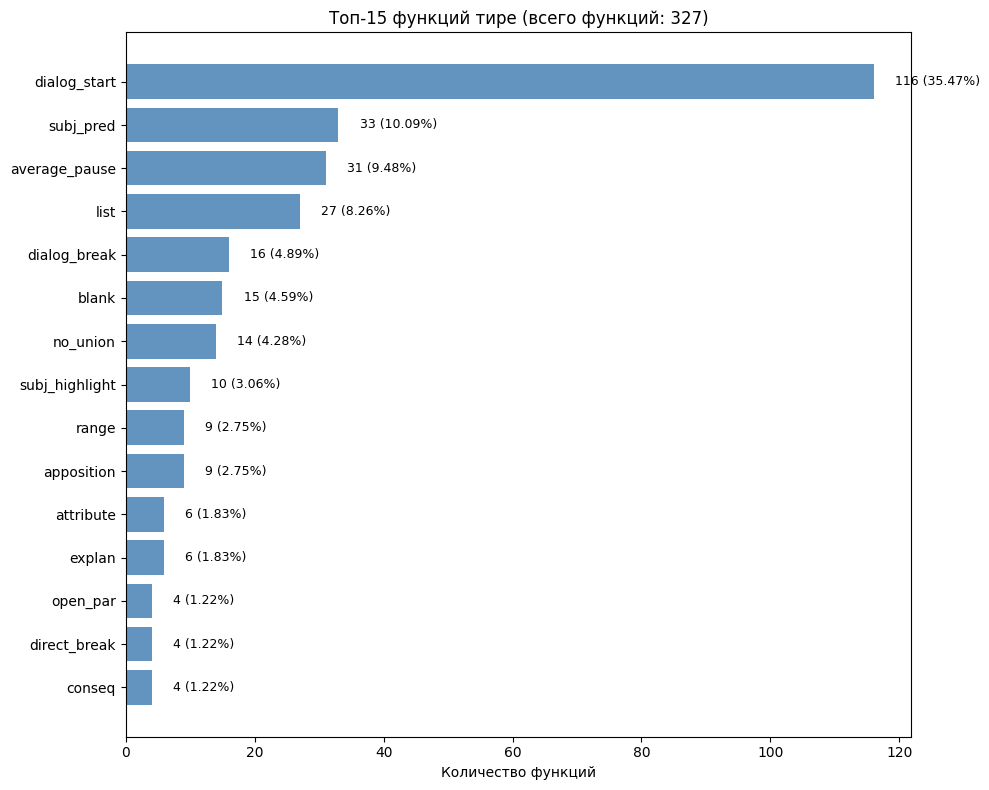

'dash_functions_histogram.png'

In [830]:
visualize_punct_functions(dash_func_stats_df, 'dash', total_dash_functions)

### Постановка/непостановка

In [831]:
dash_presence_result = analyze_punctuation_presence(df_clean, 'dash')

dash_presence_lists = dash_presence_result['punct_presence_lists']
total_dashes_presence = dash_presence_result['total_puncts_presence']
all_dash_presence = dash_presence_result['all_presence_values']
total_dash_presence_values = dash_presence_result['total_presence_values']
dash_presence_counter = dash_presence_result['presence_counter']
dash_presence_stats_df = dash_presence_result['presence_stats_df']

Анализ присутствия 'dash':

   - Общее количество dash: 310
   - Уникальных значений присутствия: 2


In [832]:
print("Статистика по присутствию тире:\n")
print(dash_presence_stats_df.to_string(index=False))

Статистика по присутствию тире:

Присутствие  Количество  Доля (%)
    present         309     99.68
    missing           1      0.32


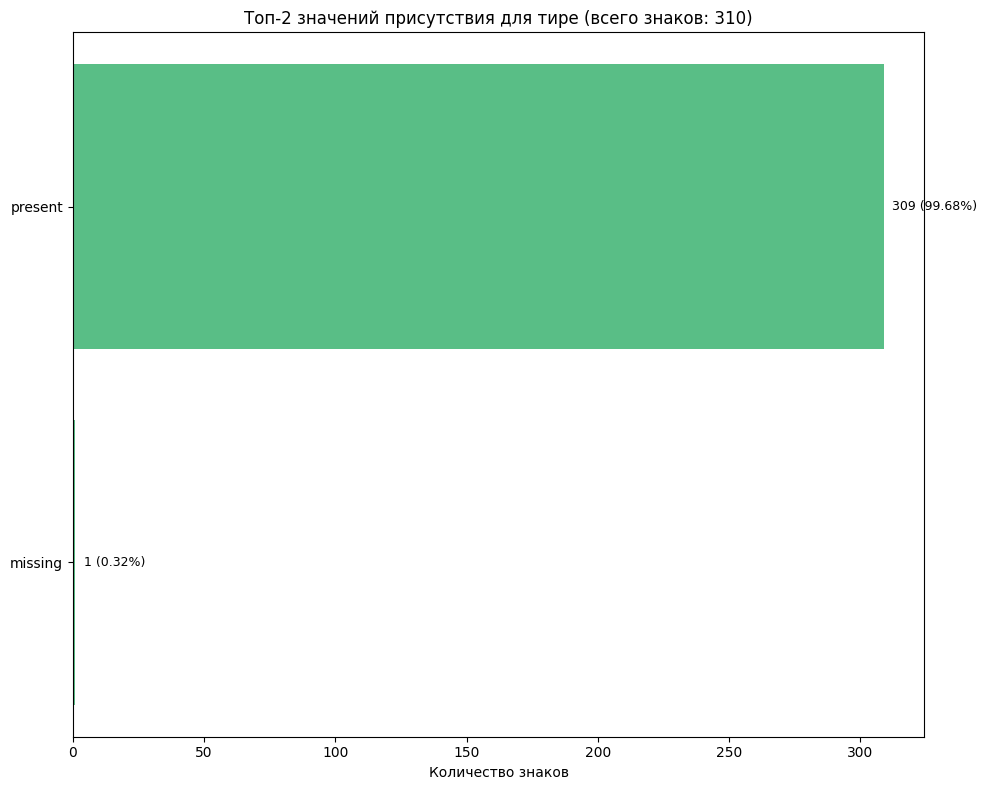

'dash_presence_histogram.png'

In [833]:
visualize_presence_stats(dash_presence_stats_df, 'dash', total_dashes_presence)

### Нормативность

In [834]:
dash_normality_result = analyze_punctuation_normality(df_clean, 'dash')

dash_normality_lists = dash_normality_result['punct_normality_lists']
total_dashes_normality = dash_normality_result['total_puncts_normality']
all_dash_normality = dash_normality_result['all_normality_values']
total_dash_normality_values = dash_normality_result['total_normality_values']
dash_normality_counter = dash_normality_result['normality_counter']
dash_normality_stats_df = dash_normality_result['normality_stats_df']

Анализ нормативности 'dash':

   - Общее количество dash: 310
   - Уникальных значений нормативности: 5


In [835]:
print("Статистика по нормативности тире:\n")
print(dash_normality_stats_df.to_string(index=False))

Статистика по нормативности тире:

Нормативность  Количество  Доля (%)
      correct         266     85.81
          ind          31     10.00
      mistake           7      2.26
       facult           3      0.97
          alt           3      0.97


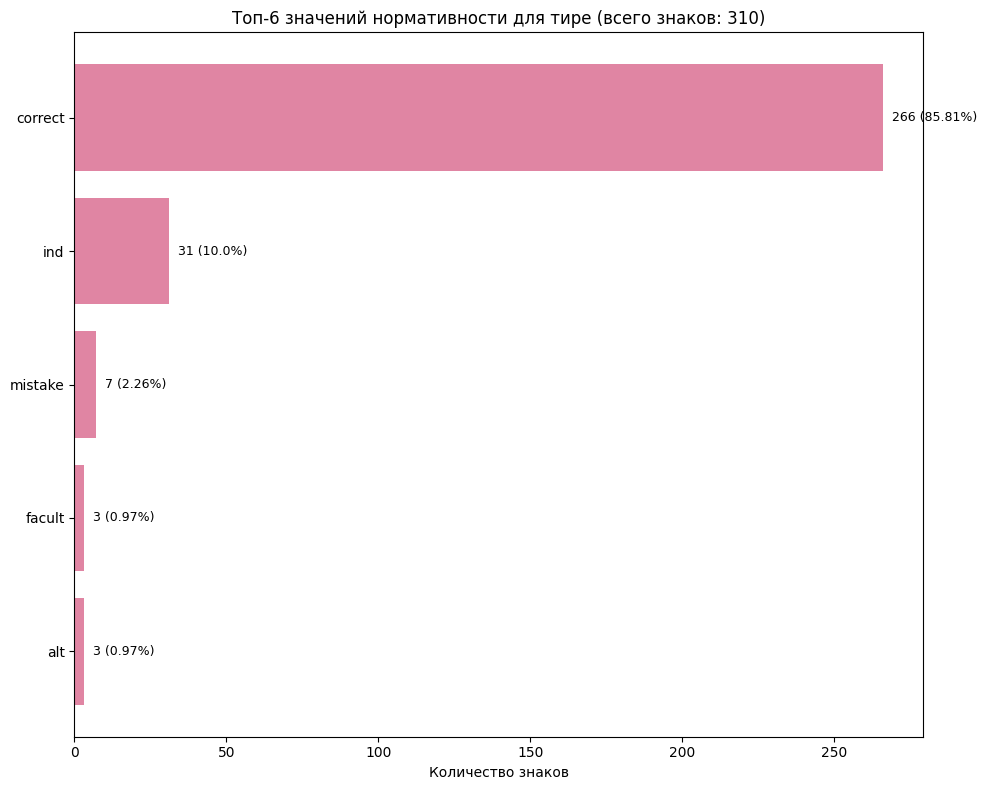

'dash_normality_histogram.png'

In [836]:
visualize_normality_stats(dash_normality_stats_df, 'dash', total_dashes_normality)

### Степень уверенности

In [837]:
dash_reliance_result = analyze_punctuation_reliance(df_clean, 'dash', total_puncts_expected=total_dashes)

dash_reliance_lists = dash_reliance_result['punct_reliance_lists']
total_dashes_reliance = dash_reliance_result['total_puncts_reliance']
all_dash_reliance = dash_reliance_result['all_reliance_values']
total_dash_reliance_values = dash_reliance_result['total_reliance_values']
dash_reliance_counter = dash_reliance_result['reliance_counter']
dash_reliance_stats_df = dash_reliance_result['reliance_stats_df']
coverage_pct = dash_reliance_result['coverage_pct']

Анализ степени уверенности 'dash':

   - Знаков с размеченной степенью уверенности: 34
   - Общее количество dash (по функциям): 310
   - Покрытие разметки степени уверенности: 10.97%
   - Уникальных значений степени уверенности: 2


In [838]:
print("Статистика по степени уверенности тире:\n")
print(dash_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности тире:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
                low          22     64.71                  10.97
               high          12     35.29                  10.97


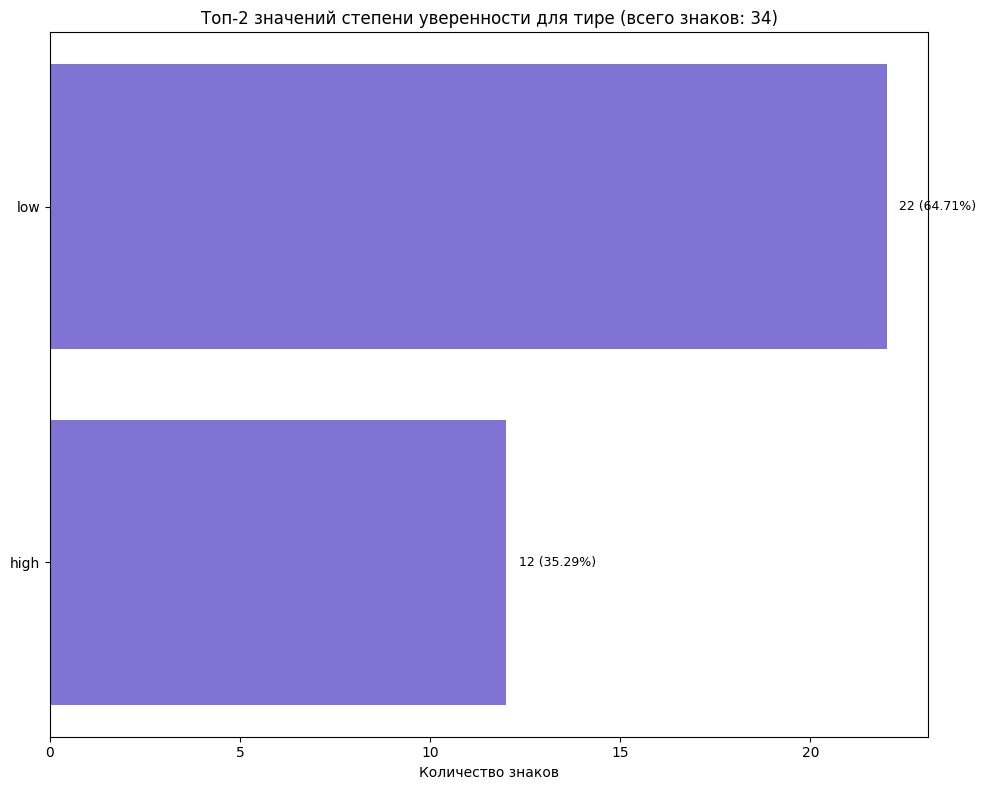

'dash_reliance_histogram.png'

In [839]:
visualize_reliance_stats(dash_reliance_stats_df, 'dash', total_dashes_reliance)

### Пробелы

In [840]:
dash_spaces_result = analyze_punctuation_spaces(df_clean, 'dash')

dash_spaces_lists = dash_spaces_result['punct_spaces_lists']
total_dashes_spaces = dash_spaces_result['total_puncts_spaces']
all_dash_spaces = dash_spaces_result['all_spaces_values']
total_dash_spaces_values = dash_spaces_result['total_spaces_values']
dash_spaces_counter = dash_spaces_result['spaces_counter']
dash_spaces_stats_df = dash_spaces_result['spaces_stats_df']

Анализ пробелов 'dash':

   - Общее количество dash: 310
   - Уникальных значений пробелов: 4


In [841]:
print("Статистика по пробелам после тире:\n")
print(dash_spaces_stats_df.to_string(index=False))

Статистика по пробелам после тире:

   Пробел  Количество  Доля (%)
bilateral         184     59.35
    right         115     37.10
     zero          10      3.23
     left           1      0.32


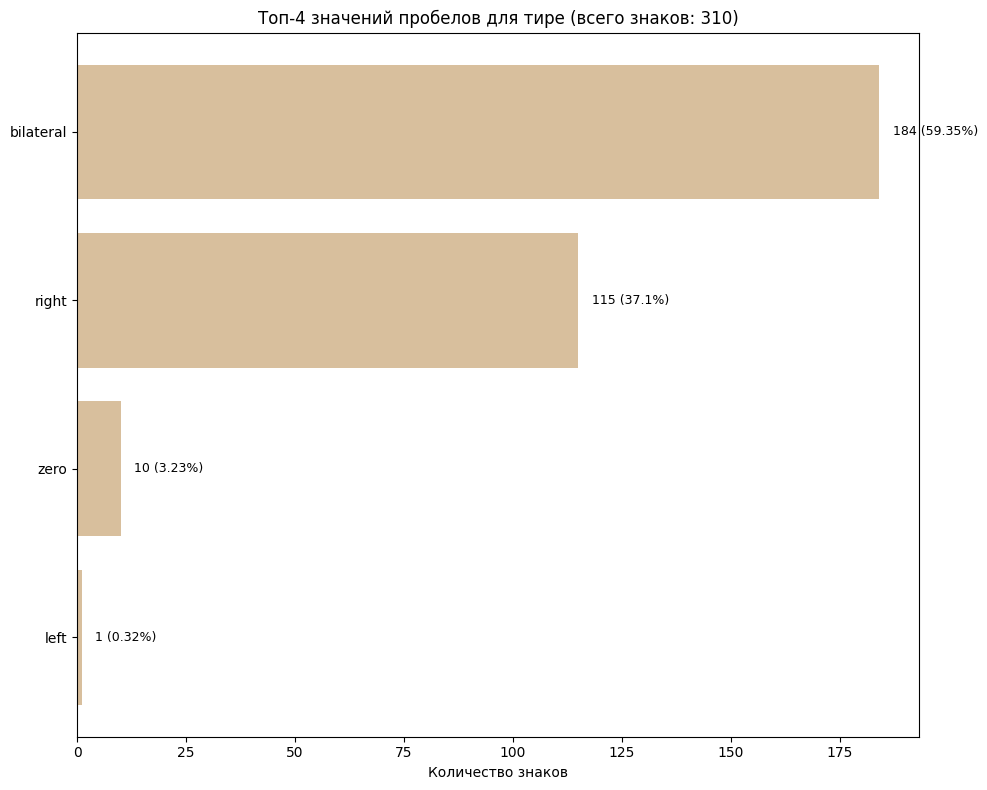

'dash_spaces_histogram.png'

In [842]:
visualize_spaces_stats(dash_spaces_stats_df, 'dash', total_dashes_spaces)

### Форма выражения

In [843]:
dash_expression_result = analyze_punctuation_expression(df_clean, 'dash')

dash_expression_lists = dash_expression_result['punct_expression_lists']
total_dashes_expression = dash_expression_result['total_puncts_expression']
all_dash_expression = dash_expression_result['all_expression_values']
total_dash_expression_values = dash_expression_result['total_expression_values']
dash_expression_counter = dash_expression_result['expression_counter']
dash_expression_stats_df = dash_expression_result['expression_stats_df']

Анализ формы выражения 'dash':

   - Общее количество dash: 308
   - Уникальных форм выражения: 5


In [844]:
print("Статистика по форме выражения тире:\n")
print(dash_expression_stats_df.to_string(index=False))

Статистика по форме выражения тире:

Форма выражения  Количество  Доля (%)
  double_hyphen         244     79.22
         n_dash          33     10.71
         hyphen          24      7.79
    double_dash           4      1.30
         m_dash           3      0.97


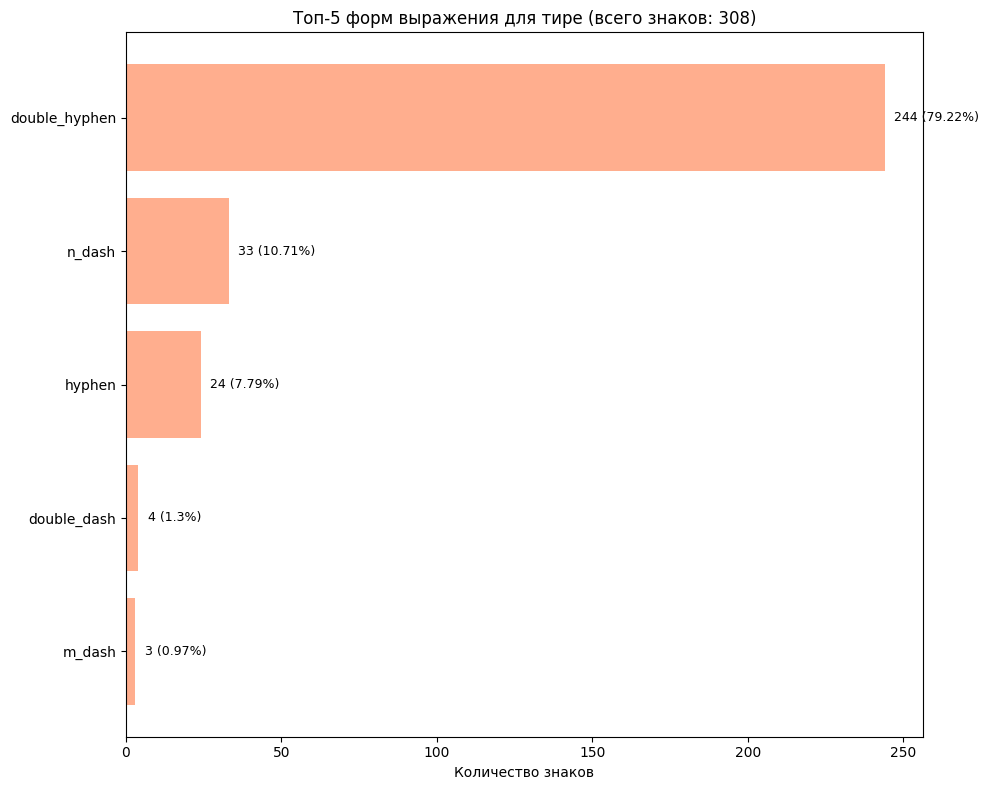

'dash_expression_histogram.png'

In [845]:
visualize_expression_stats(dash_expression_stats_df, 'dash', total_dashes_expression)

## Дефис

### Функции знака

In [846]:
hyphen_func_result = analyze_punctuation_func(df_clean, 'hyphen')

hyphen_func_lists = hyphen_func_result['punct_lists']
total_hyphens = hyphen_func_result['total_puncts']
all_hyphen_functions = hyphen_func_result['all_functions']
total_hyphen_functions = hyphen_func_result['total_functions']
hyphen_func_counter = hyphen_func_result['func_counter']
hyphen_func_stats_df = hyphen_func_result['func_stats_df']

Анализ функций 'hyphen':

   - Общее количество hyphen: 53
   - Общее количество функций (с повторениями): 53
   - Среднее количество функций на знак: 1.00
   - Уникальных функций: 8


In [847]:
print("Статистика по функциям дефиса:\n")
print(hyphen_func_stats_df.to_string(index=False))

Статистика по функциям дефиса:

    Функция  Количество  Доля (%)
 word_parts          30     56.60
abbrev_word          11     20.75
     number           3      5.66
     redupl           3      5.66
 long_sound           3      5.66
      range           1      1.89
    options           1      1.89
double_name           1      1.89


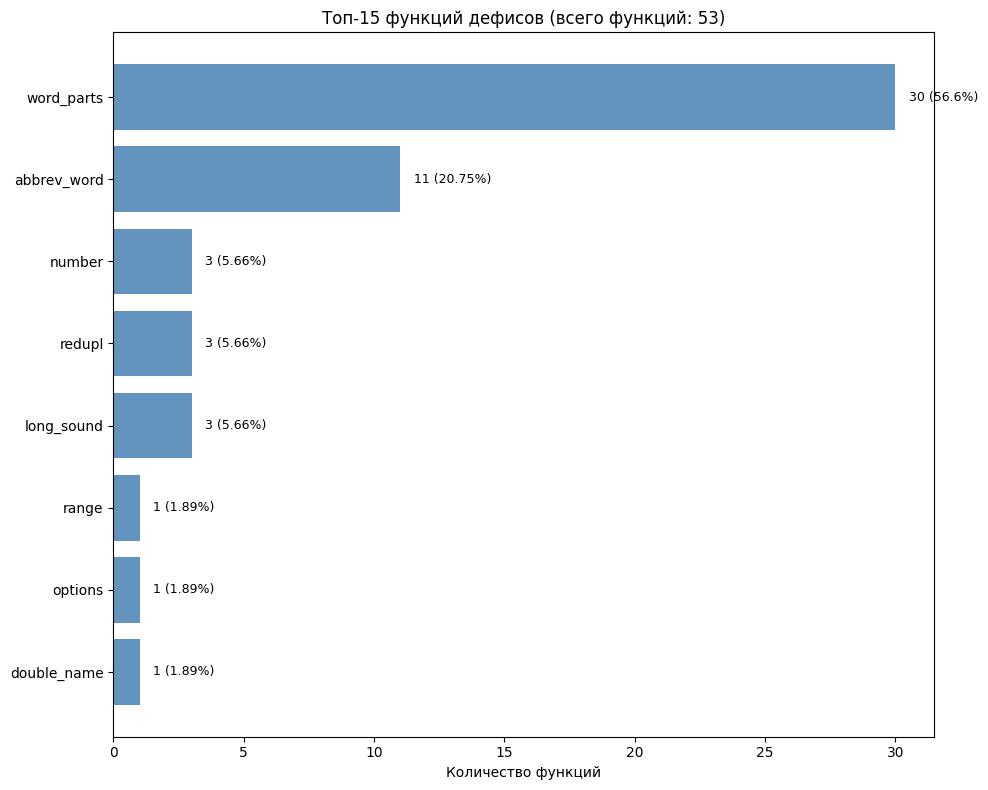

'hyphen_functions_histogram.png'

In [848]:
visualize_punct_functions(hyphen_func_stats_df, 'hyphen', total_hyphen_functions)

### Постановка/непостановка

In [849]:
hyphen_presence_result = analyze_punctuation_presence(df_clean, 'hyphen')

hyphen_presence_lists = hyphen_presence_result['punct_presence_lists']
total_hyphens_presence = hyphen_presence_result['total_puncts_presence']
all_hyphen_presence = hyphen_presence_result['all_presence_values']
total_hyphen_presence_values = hyphen_presence_result['total_presence_values']
hyphen_presence_counter = hyphen_presence_result['presence_counter']
hyphen_presence_stats_df = hyphen_presence_result['presence_stats_df']

Анализ присутствия 'hyphen':

   - Общее количество hyphen: 54
   - Уникальных значений присутствия: 2


In [850]:
print("Статистика по присутствию дефисов:\n")
print(hyphen_presence_stats_df.to_string(index=False))

Статистика по присутствию дефисов:

Присутствие  Количество  Доля (%)
    present          53     98.15
    missing           1      1.85


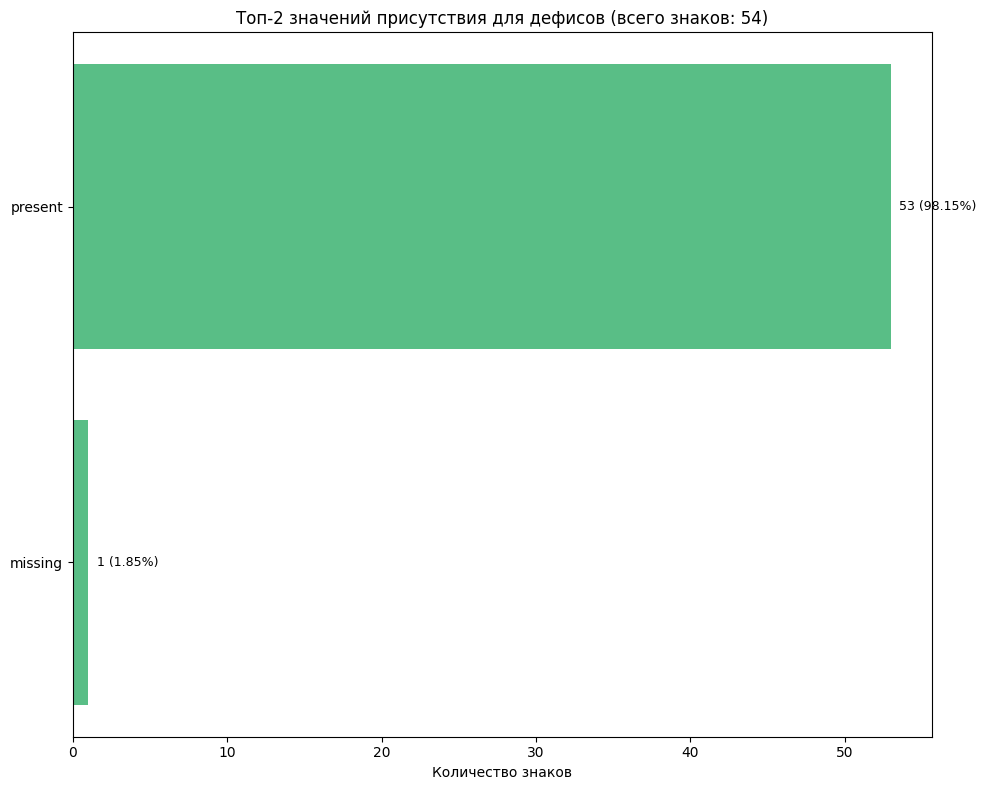

'hyphen_presence_histogram.png'

In [851]:
visualize_presence_stats(hyphen_presence_stats_df, 'hyphen', total_hyphens_presence)

### Нормативность

In [852]:
hyphen_normality_result = analyze_punctuation_normality(df_clean, 'hyphen')

hyphen_normality_lists = hyphen_normality_result['punct_normality_lists']
total_hyphens_normality = hyphen_normality_result['total_puncts_normality']
all_hyphen_normality = hyphen_normality_result['all_normality_values']
total_hyphen_normality_values = hyphen_normality_result['total_normality_values']
hyphen_normality_counter = hyphen_normality_result['normality_counter']
hyphen_normality_stats_df = hyphen_normality_result['normality_stats_df']

Анализ нормативности 'hyphen':

   - Общее количество hyphen: 54
   - Уникальных значений нормативности: 2


In [853]:
print("Статистика по нормативности дефисов:\n")
print(hyphen_normality_stats_df.to_string(index=False))

Статистика по нормативности дефисов:

Нормативность  Количество  Доля (%)
      correct          52      96.3
      mistake           2       3.7


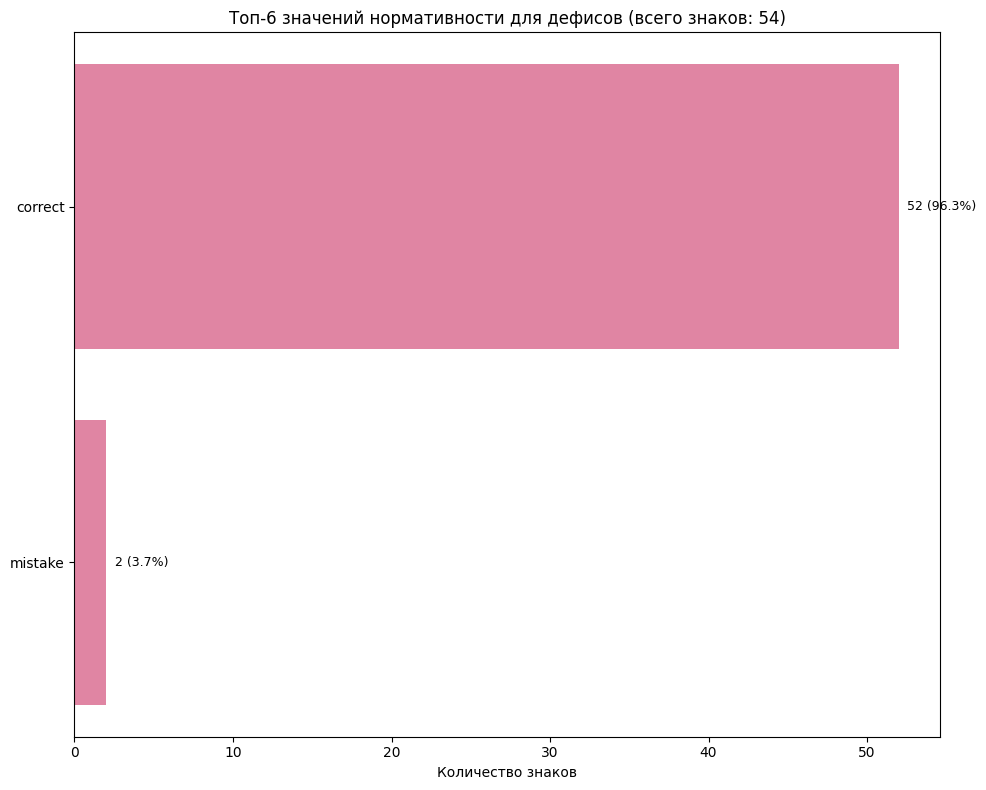

'hyphen_normality_histogram.png'

In [854]:
visualize_normality_stats(hyphen_normality_stats_df, 'hyphen', total_hyphens_normality)

### Степень уверенности

In [855]:
hyphen_reliance_result = analyze_punctuation_reliance(df_clean, 'hyphen',
                                                      total_puncts_expected=total_hyphens)

hyphen_reliance_lists = hyphen_reliance_result['punct_reliance_lists']
total_hyphens_reliance = hyphen_reliance_result['total_puncts_reliance']
all_hyphen_reliance = hyphen_reliance_result['all_reliance_values']
total_hyphen_reliance_values = hyphen_reliance_result['total_reliance_values']
hyphen_reliance_counter = hyphen_reliance_result['reliance_counter']
hyphen_reliance_stats_df = hyphen_reliance_result['reliance_stats_df']
coverage_pct = hyphen_reliance_result['coverage_pct']

Анализ степени уверенности 'hyphen':

   - Знаков с размеченной степенью уверенности: 2
   - Общее количество hyphen (по функциям): 53
   - Покрытие разметки степени уверенности: 3.77%
   - Уникальных значений степени уверенности: 1


In [856]:
print("Статистика по степени уверенности дефисов:\n")
print(hyphen_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности дефисов:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           2     100.0                   3.77


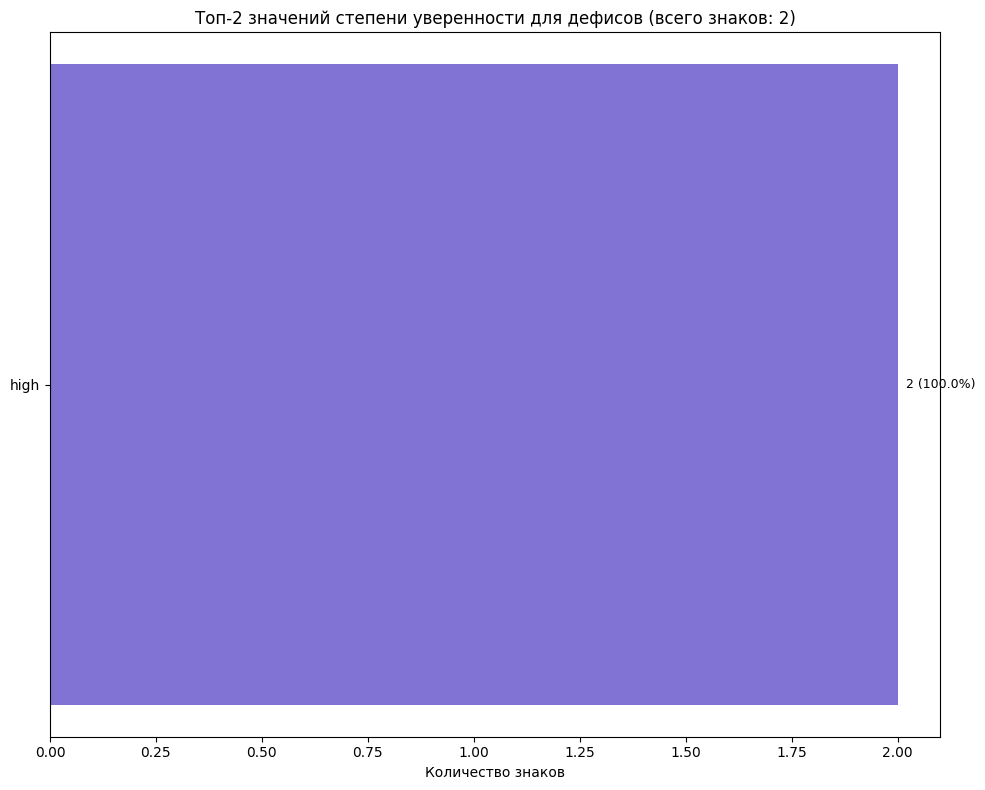

'hyphen_reliance_histogram.png'

In [857]:
visualize_reliance_stats(hyphen_reliance_stats_df, 'hyphen', total_hyphens_reliance)

### Пробелы

In [858]:
hyphen_spaces_result = analyze_punctuation_spaces(df_clean, 'hyphen')

hyphen_spaces_lists = hyphen_spaces_result['punct_spaces_lists']
total_hyphens_spaces = hyphen_spaces_result['total_puncts_spaces']
all_hyphen_spaces = hyphen_spaces_result['all_spaces_values']
total_hyphen_spaces_values = hyphen_spaces_result['total_spaces_values']
hyphen_spaces_counter = hyphen_spaces_result['spaces_counter']
hyphen_spaces_stats_df = hyphen_spaces_result['spaces_stats_df']

Анализ пробелов 'hyphen':

   - Общее количество hyphen: 54
   - Уникальных значений пробелов: 1


In [859]:
print("Статистика по пробелам после дефисов:\n")
print(hyphen_spaces_stats_df.to_string(index=False))

Статистика по пробелам после дефисов:

Пробел  Количество  Доля (%)
  zero          54     100.0


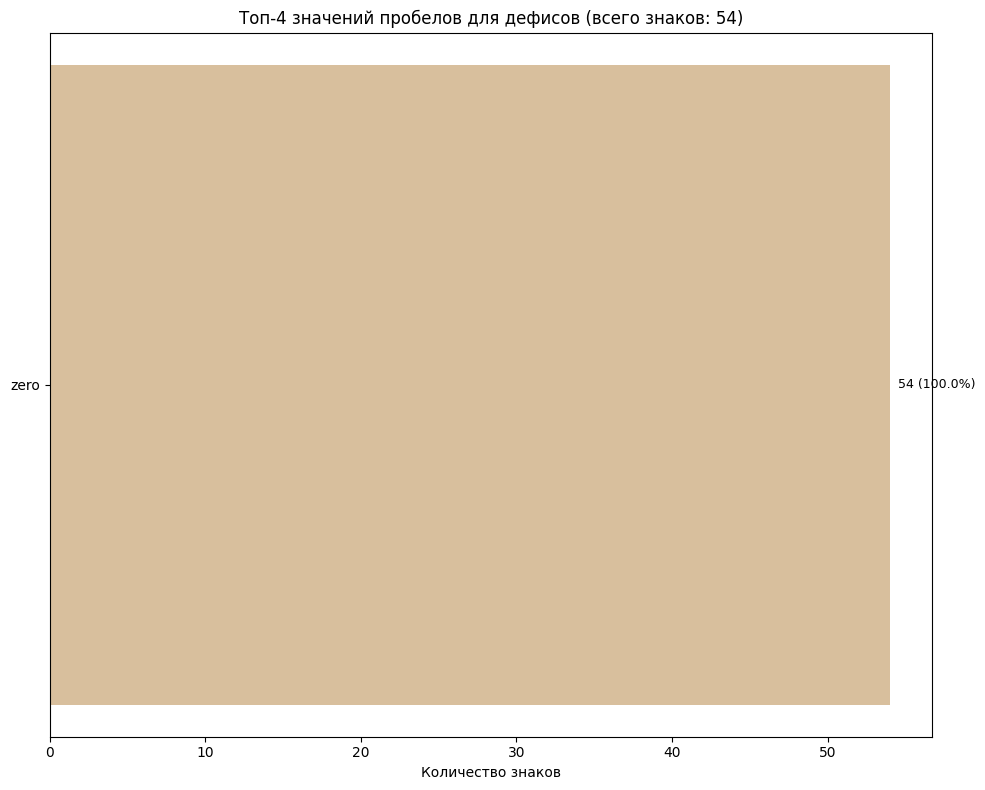

'hyphen_spaces_histogram.png'

In [860]:
visualize_spaces_stats(hyphen_spaces_stats_df, 'hyphen', total_hyphens_spaces)

### Форма выражения

Такой колонки пока нет (появится), но на данный момент у всех дефисов форма выражения была бы hyphen.

## Открывающая круглая скобка

### Функции знака

In [861]:
left_parenthesis_func_result = analyze_punctuation_func(df_clean, 'left_parenthesis')

left_parenthesis_func_lists = left_parenthesis_func_result['punct_lists']
total_left_parenthesis = left_parenthesis_func_result['total_puncts']
all_left_parenthesis_functions = left_parenthesis_func_result['all_functions']
total_left_parenthesis_functions = left_parenthesis_func_result['total_functions']
left_parenthesis_func_counter = left_parenthesis_func_result['func_counter']
left_parenthesis_func_stats_df = left_parenthesis_func_result['func_stats_df']

Анализ функций 'left_parenthesis':

   - Общее количество left_parenthesis: 89
   - Общее количество функций (с повторениями): 89
   - Среднее количество функций на знак: 1.00
   - Уникальных функций: 3


In [862]:
print("Статистика по функциям открывающей круглой скобки:\n")
print(left_parenthesis_func_stats_df.to_string(index=False))

Статистика по функциям открывающей круглой скобки:

 Функция  Количество  Доля (%)
open_par          57     64.04
  remark          31     34.83
  number           1      1.12


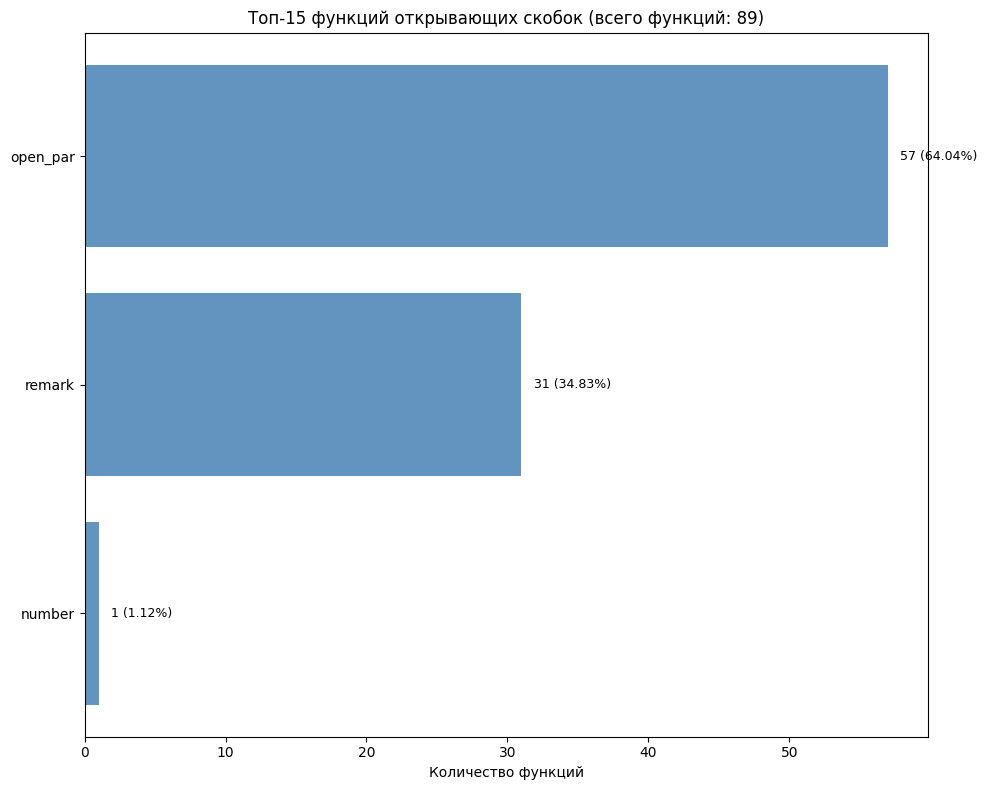

'left_parenthesis_functions_histogram.png'

In [863]:
visualize_punct_functions(left_parenthesis_func_stats_df, 'left_parenthesis', total_left_parenthesis_functions)

### Постановка/непостановка

In [864]:
left_parenthesis_presence_result = analyze_punctuation_presence(df_clean, 'left_parenthesis')

left_parenthesis_presence_lists = left_parenthesis_presence_result['punct_presence_lists']
total_left_parenthesis_presence = left_parenthesis_presence_result['total_puncts_presence']
all_left_parenthesis_presence = left_parenthesis_presence_result['all_presence_values']
total_left_parenthesis_presence_values = left_parenthesis_presence_result['total_presence_values']
left_parenthesis_presence_counter = left_parenthesis_presence_result['presence_counter']
left_parenthesis_presence_stats_df = left_parenthesis_presence_result['presence_stats_df']

Анализ присутствия 'left_parenthesis':

   - Общее количество left_parenthesis: 89
   - Уникальных значений присутствия: 1


In [865]:
print("Статистика по присутствию открывающих круглых скобок:\n")
print(left_parenthesis_presence_stats_df.to_string(index=False))

Статистика по присутствию открывающих круглых скобок:

Присутствие  Количество  Доля (%)
    present          89     100.0


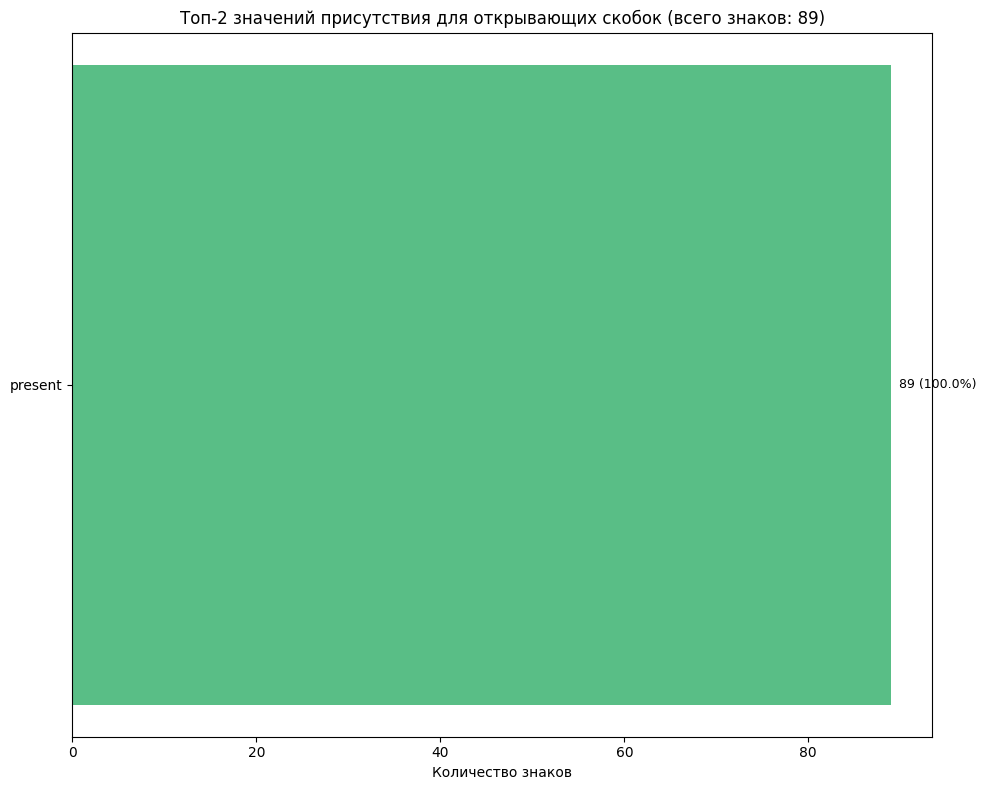

'left_parenthesis_presence_histogram.png'

In [866]:
visualize_presence_stats(left_parenthesis_presence_stats_df, 'left_parenthesis', total_left_parenthesis_presence)

### Нормативность

In [867]:
left_parenthesis_normality_result = analyze_punctuation_normality(df_clean, 'left_parenthesis')

left_parenthesis_normality_lists = left_parenthesis_normality_result['punct_normality_lists']
total_left_parenthesis_normality = left_parenthesis_normality_result['total_puncts_normality']
all_left_parenthesis_normality = left_parenthesis_normality_result['all_normality_values']
total_left_parenthesis_normality_values = left_parenthesis_normality_result['total_normality_values']
left_parenthesis_normality_counter = left_parenthesis_normality_result['normality_counter']
left_parenthesis_normality_stats_df = left_parenthesis_normality_result['normality_stats_df']

Анализ нормативности 'left_parenthesis':

   - Общее количество left_parenthesis: 89
   - Уникальных значений нормативности: 1


In [868]:
print("Статистика по нормативности открывающих круглых скобок:\n")
print(left_parenthesis_normality_stats_df.to_string(index=False))

Статистика по нормативности открывающих круглых скобок:

Нормативность  Количество  Доля (%)
      correct          89     100.0


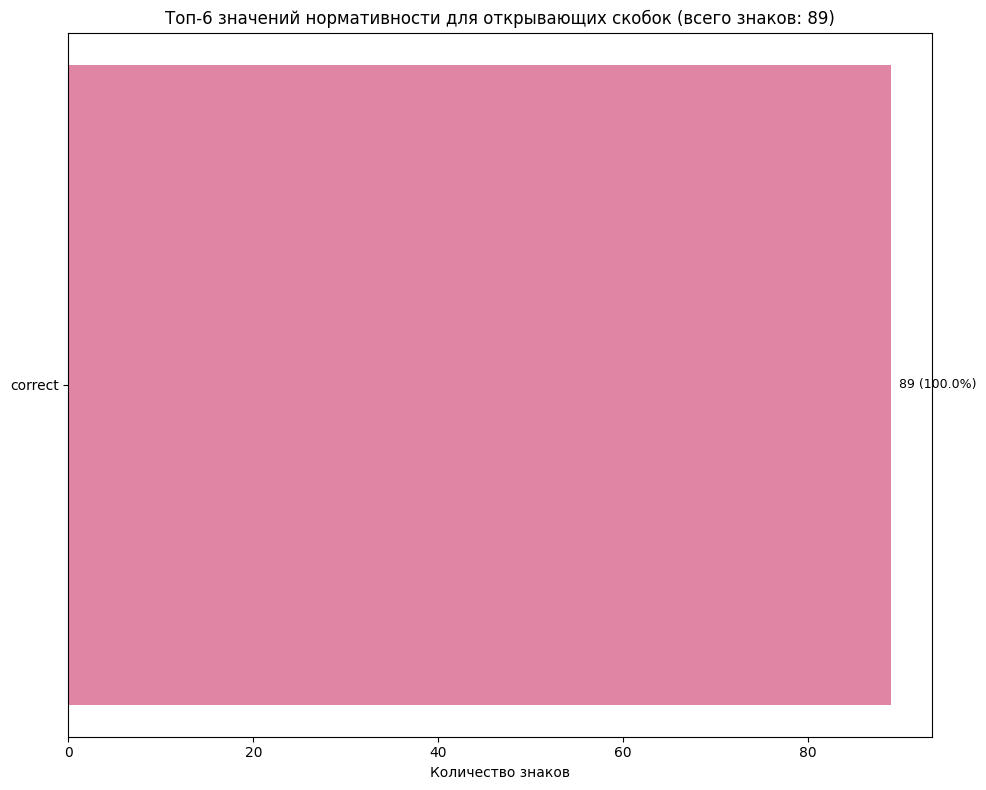

'left_parenthesis_normality_histogram.png'

In [869]:
visualize_normality_stats(left_parenthesis_normality_stats_df, 'left_parenthesis', total_left_parenthesis_normality)

### Степень уверенности

In [870]:
left_parenthesis_reliance_result = analyze_punctuation_reliance(df_clean, 'left_parenthesis',
                                                                total_puncts_expected=total_left_parenthesis)

left_parenthesis_reliance_lists = left_parenthesis_reliance_result['punct_reliance_lists']
total_left_parenthesis_reliance = left_parenthesis_reliance_result['total_puncts_reliance']
all_left_parenthesis_reliance = left_parenthesis_reliance_result['all_reliance_values']
total_left_parenthesis_reliance_values = left_parenthesis_reliance_result['total_reliance_values']
left_parenthesis_reliance_counter = left_parenthesis_reliance_result['reliance_counter']
left_parenthesis_reliance_stats_df = left_parenthesis_reliance_result['reliance_stats_df']
coverage_pct = left_parenthesis_reliance_result['coverage_pct']

Анализ степени уверенности 'left_parenthesis':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество left_parenthesis (по функциям): 89
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [871]:
print("Статистика по степени уверенности открывающих круглых скобок:\n")
print(left_parenthesis_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности открывающих круглых скобок:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


In [872]:
# visualize_reliance_stats(left_parenthesis_reliance_stats_df, 'left_parenthesis', total_left_parenthesis_reliance)

### Пробелы

In [873]:
left_parenthesis_presence_result = analyze_punctuation_presence(df_clean, 'left_parenthesis')

left_parenthesis_presence_lists = left_parenthesis_presence_result['punct_presence_lists']
total_left_parenthesis_presence = left_parenthesis_presence_result['total_puncts_presence']
all_left_parenthesis_presence = left_parenthesis_presence_result['all_presence_values']
total_left_parenthesis_presence_values = left_parenthesis_presence_result['total_presence_values']
left_parenthesis_presence_counter = left_parenthesis_presence_result['presence_counter']
left_parenthesis_presence_stats_df = left_parenthesis_presence_result['presence_stats_df']

Анализ присутствия 'left_parenthesis':

   - Общее количество left_parenthesis: 89
   - Уникальных значений присутствия: 1


In [874]:
print("Статистика по присутствию открывающих круглых скобок:\n")
print(left_parenthesis_presence_stats_df.to_string(index=False))

Статистика по присутствию открывающих круглых скобок:

Присутствие  Количество  Доля (%)
    present          89     100.0


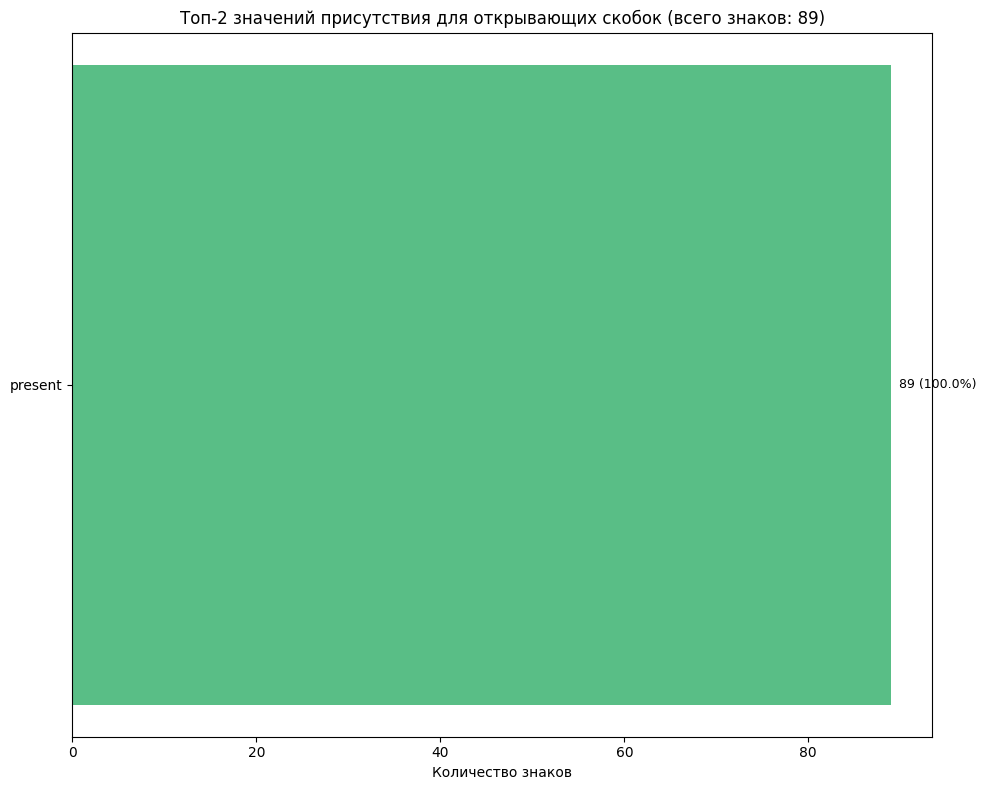

'left_parenthesis_presence_histogram.png'

In [875]:
visualize_presence_stats(left_parenthesis_presence_stats_df, 'left_parenthesis', total_left_parenthesis_presence)

## Закрывающая круглая скобка

### Функции знака

In [876]:
right_parenthesis_func_result = analyze_punctuation_func(df_clean, 'right_parenthesis')

right_parenthesis_func_lists = right_parenthesis_func_result['punct_lists']
total_right_parenthesis = right_parenthesis_func_result['total_puncts']
all_right_parenthesis_functions = right_parenthesis_func_result['all_functions']
total_right_parenthesis_functions = right_parenthesis_func_result['total_functions']
right_parenthesis_func_counter = right_parenthesis_func_result['func_counter']
right_parenthesis_func_stats_df = right_parenthesis_func_result['func_stats_df']

Анализ функций 'right_parenthesis':

   - Общее количество right_parenthesis: 98
   - Общее количество функций (с повторениями): 98
   - Среднее количество функций на знак: 1.00
   - Уникальных функций: 4


In [877]:
print("Статистика по функциям закрывающей круглой скобки:\n")
print(right_parenthesis_func_stats_df.to_string(index=False))

Статистика по функциям закрывающей круглой скобки:

  Функция  Количество  Доля (%)
close_par          56     57.14
   remark          32     32.65
non_punct           9      9.18
   number           1      1.02


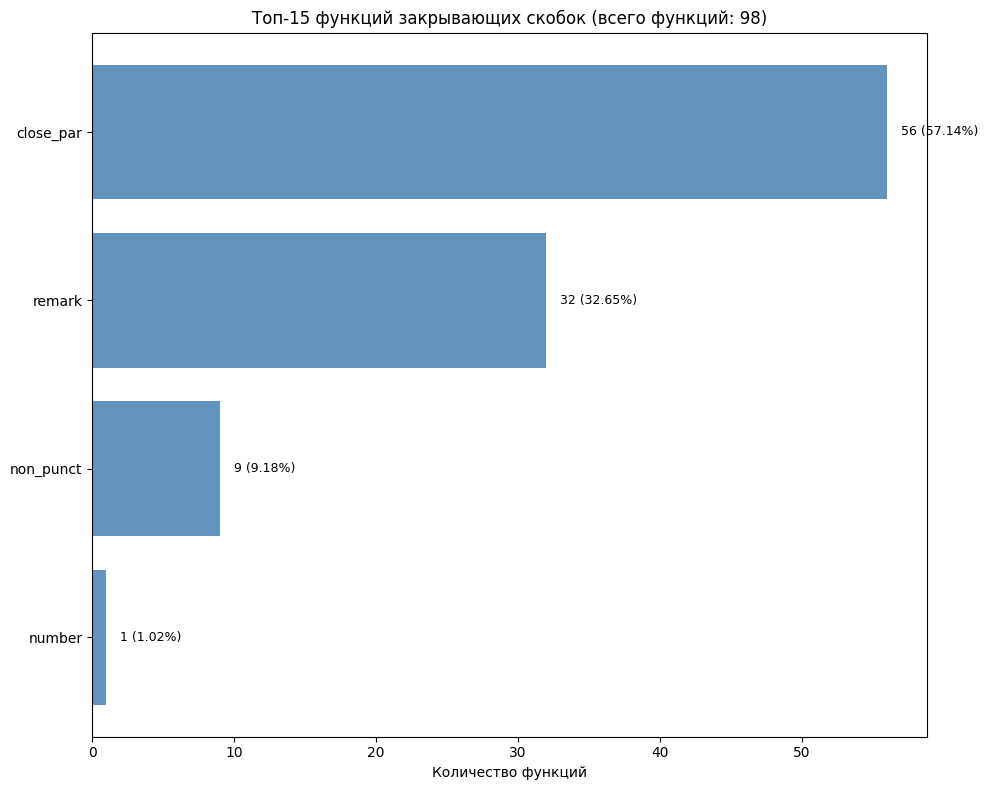

'right_parenthesis_functions_histogram.png'

In [878]:
visualize_punct_functions(right_parenthesis_func_stats_df, 'right_parenthesis', total_right_parenthesis_functions)

### Постановка/непостановка

In [879]:
right_parenthesis_presence_result = analyze_punctuation_presence(df_clean, 'right_parenthesis')

right_parenthesis_presence_lists = right_parenthesis_presence_result['punct_presence_lists']
total_right_parenthesis_presence = right_parenthesis_presence_result['total_puncts_presence']
all_right_parenthesis_presence = right_parenthesis_presence_result['all_presence_values']
total_right_parenthesis_presence_values = right_parenthesis_presence_result['total_presence_values']
right_parenthesis_presence_counter = right_parenthesis_presence_result['presence_counter']
right_parenthesis_presence_stats_df = right_parenthesis_presence_result['presence_stats_df']

Анализ присутствия 'right_parenthesis':

   - Общее количество right_parenthesis: 98
   - Уникальных значений присутствия: 1


In [880]:
print("Статистика по присутствию закрывающих круглых скобок:\n")
print(right_parenthesis_presence_stats_df.to_string(index=False))

Статистика по присутствию закрывающих круглых скобок:

Присутствие  Количество  Доля (%)
    present          98     100.0


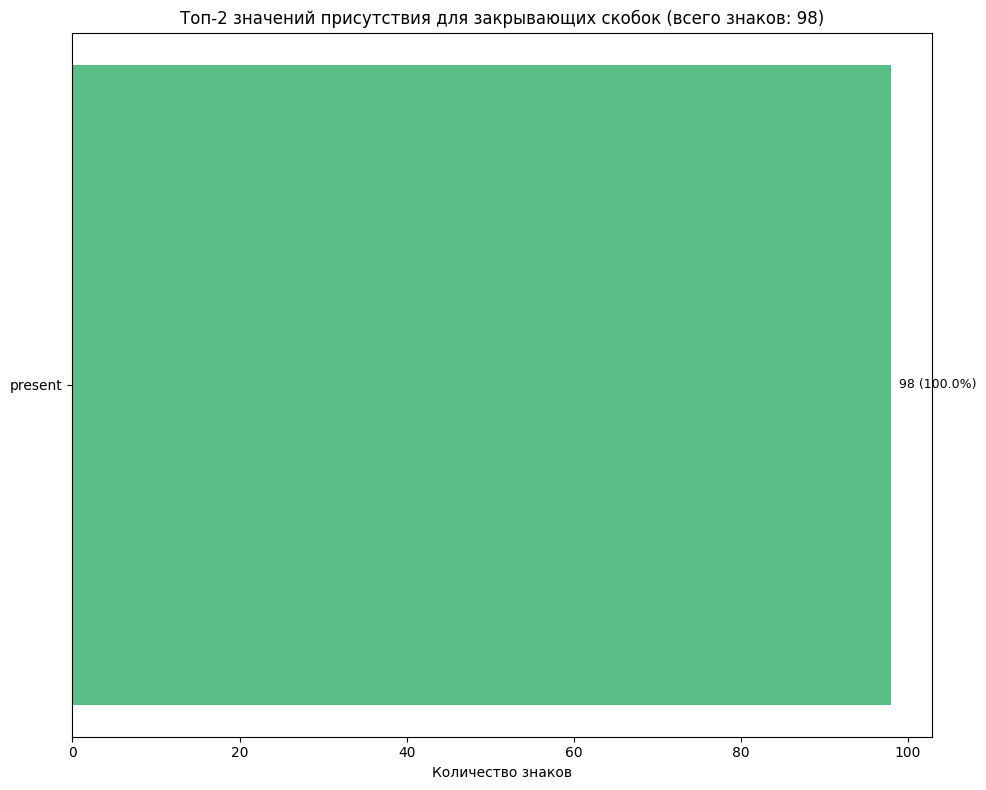

'right_parenthesis_presence_histogram.png'

In [881]:
visualize_presence_stats(right_parenthesis_presence_stats_df, 'right_parenthesis', total_right_parenthesis_presence)

### Нормативность

In [882]:
right_parenthesis_normality_result = analyze_punctuation_normality(df_clean, 'right_parenthesis')

right_parenthesis_normality_lists = right_parenthesis_normality_result['punct_normality_lists']
total_right_parenthesis_normality = right_parenthesis_normality_result['total_puncts_normality']
all_right_parenthesis_normality = right_parenthesis_normality_result['all_normality_values']
total_right_parenthesis_normality_values = right_parenthesis_normality_result['total_normality_values']
right_parenthesis_normality_counter = right_parenthesis_normality_result['normality_counter']
right_parenthesis_normality_stats_df = right_parenthesis_normality_result['normality_stats_df']

Анализ нормативности 'right_parenthesis':

   - Общее количество right_parenthesis: 98
   - Уникальных значений нормативности: 3


In [883]:
print("Статистика по нормативности закрывающих круглых скобок:\n")
print(right_parenthesis_normality_stats_df.to_string(index=False))

Статистика по нормативности закрывающих круглых скобок:

Нормативность  Количество  Доля (%)
      correct          88     89.80
          ind           9      9.18
         typo           1      1.02


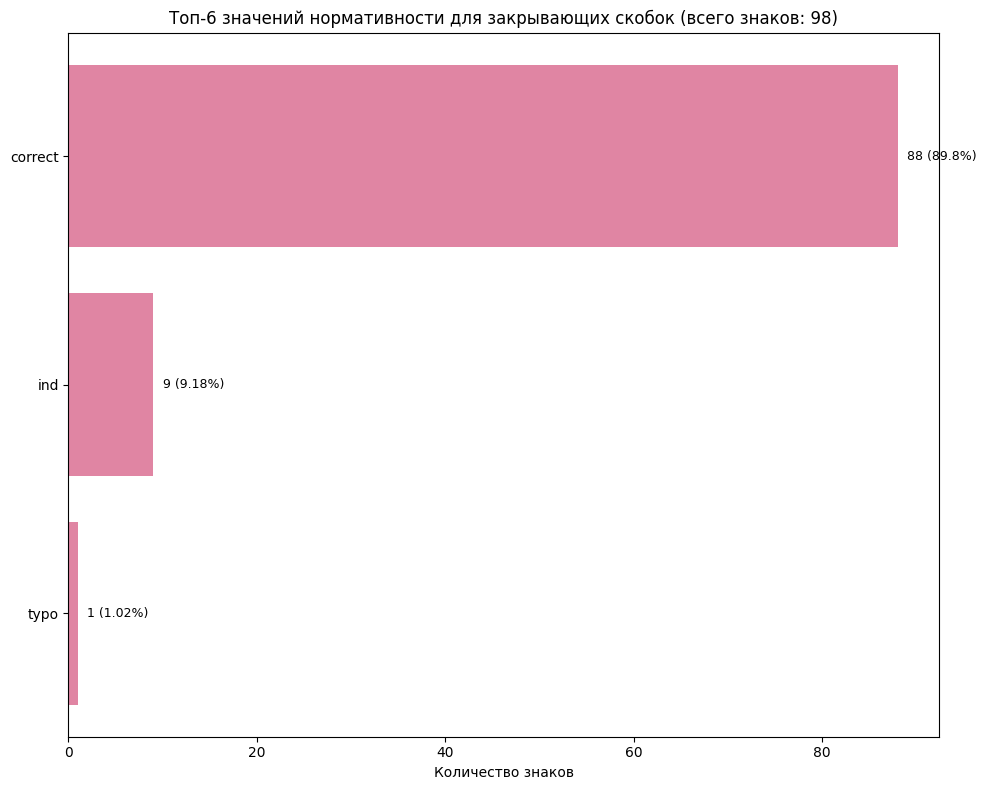

'right_parenthesis_normality_histogram.png'

In [884]:
visualize_normality_stats(right_parenthesis_normality_stats_df, 'right_parenthesis', total_right_parenthesis_normality)

### Степень уверенности

In [885]:
right_parenthesis_reliance_result = analyze_punctuation_reliance(df_clean, 'right_parenthesis',
                                                                 total_puncts_expected=total_right_parenthesis)

right_parenthesis_reliance_lists = right_parenthesis_reliance_result['punct_reliance_lists']
total_right_parenthesis_reliance = right_parenthesis_reliance_result['total_puncts_reliance']
all_right_parenthesis_reliance = right_parenthesis_reliance_result['all_reliance_values']
total_right_parenthesis_reliance_values = right_parenthesis_reliance_result['total_reliance_values']
right_parenthesis_reliance_counter = right_parenthesis_reliance_result['reliance_counter']
right_parenthesis_reliance_stats_df = right_parenthesis_reliance_result['reliance_stats_df']
coverage_pct = right_parenthesis_reliance_result['coverage_pct']

Анализ степени уверенности 'right_parenthesis':

   - Знаков с размеченной степенью уверенности: 9
   - Общее количество right_parenthesis (по функциям): 98
   - Покрытие разметки степени уверенности: 9.18%
   - Уникальных значений степени уверенности: 1


In [886]:
print("Статистика по степени уверенности закрывающих круглых скобок:\n")
print(right_parenthesis_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности закрывающих круглых скобок:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           9     100.0                   9.18


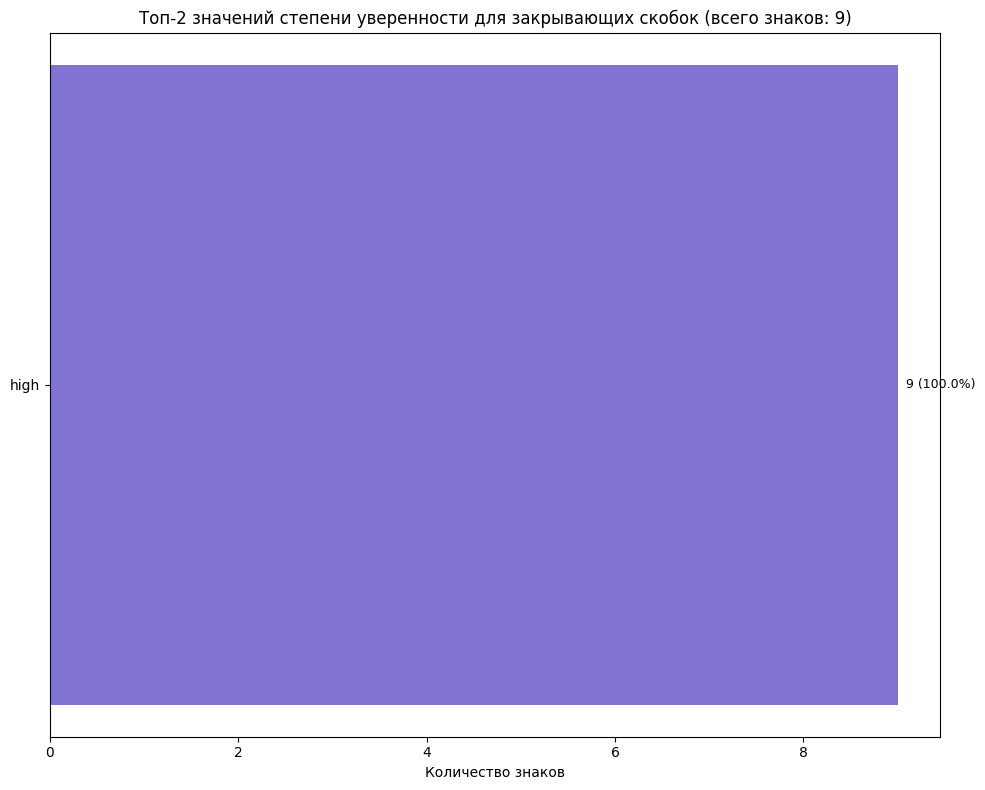

'right_parenthesis_reliance_histogram.png'

In [887]:
visualize_reliance_stats(right_parenthesis_reliance_stats_df, 'right_parenthesis', total_right_parenthesis_reliance)

### Пробелы

In [888]:
right_parenthesis_spaces_result = analyze_punctuation_spaces(df_clean, 'right_parenthesis')

right_parenthesis_spaces_lists = right_parenthesis_spaces_result['punct_spaces_lists']
total_right_parenthesis_spaces = right_parenthesis_spaces_result['total_puncts_spaces']
all_right_parenthesis_spaces = right_parenthesis_spaces_result['all_spaces_values']
total_right_parenthesis_spaces_values = right_parenthesis_spaces_result['total_spaces_values']
right_parenthesis_spaces_counter = right_parenthesis_spaces_result['spaces_counter']
right_parenthesis_spaces_stats_df = right_parenthesis_spaces_result['spaces_stats_df']

Анализ пробелов 'right_parenthesis':

   - Общее количество right_parenthesis: 92
   - Уникальных значений пробелов: 3


In [889]:
print("Статистика по пробелам после закрывающих круглых скобок:\n")
print(right_parenthesis_spaces_stats_df.to_string(index=False))

Статистика по пробелам после закрывающих круглых скобок:

Пробел  Количество  Доля (%)
  zero          58     63.04
 right          33     35.87
  left           1      1.09


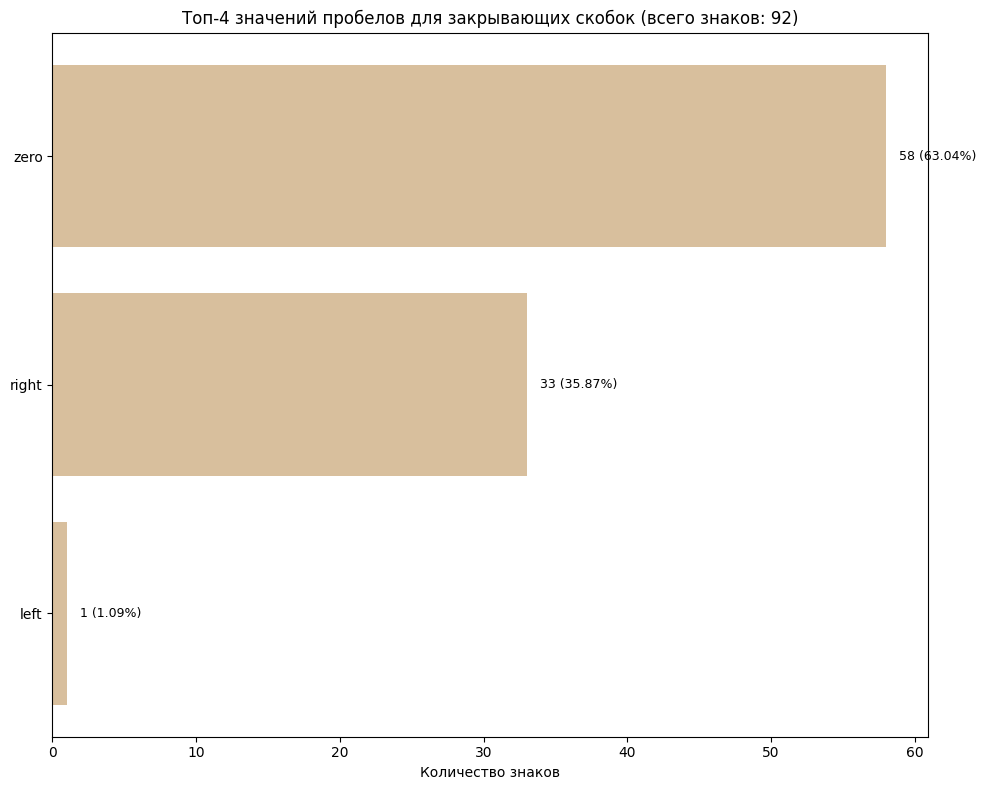

'right_parenthesis_spaces_histogram.png'

In [890]:
visualize_spaces_stats(right_parenthesis_spaces_stats_df, 'right_parenthesis', total_right_parenthesis_spaces)

## Открывающая квадратная скобка

### Функции знака

In [891]:
left_square_bracket_func_result = analyze_punctuation_func(df_clean, 'left_square_bracket')

left_square_bracket_func_lists = left_square_bracket_func_result['punct_lists']
total_left_square_brackets = left_square_bracket_func_result['total_puncts']
all_left_square_bracket_functions = left_square_bracket_func_result['all_functions']
total_left_square_bracket_functions = left_square_bracket_func_result['total_functions']
left_square_bracket_func_counter = left_square_bracket_func_result['func_counter']
left_square_bracket_func_stats_df = left_square_bracket_func_result['func_stats_df']

Анализ функций 'left_square_bracket':

   - Общее количество left_square_bracket: 1
   - Общее количество функций (с повторениями): 1
   - Среднее количество функций на знак: 1.00
   - Уникальных функций: 1


In [892]:
print("Статистика по функциям открывающей квадратной скобки:\n")
print(left_square_bracket_func_stats_df.to_string(index=False))

Статистика по функциям открывающей квадратной скобки:

Функция  Количество  Доля (%)
 biblio           1     100.0


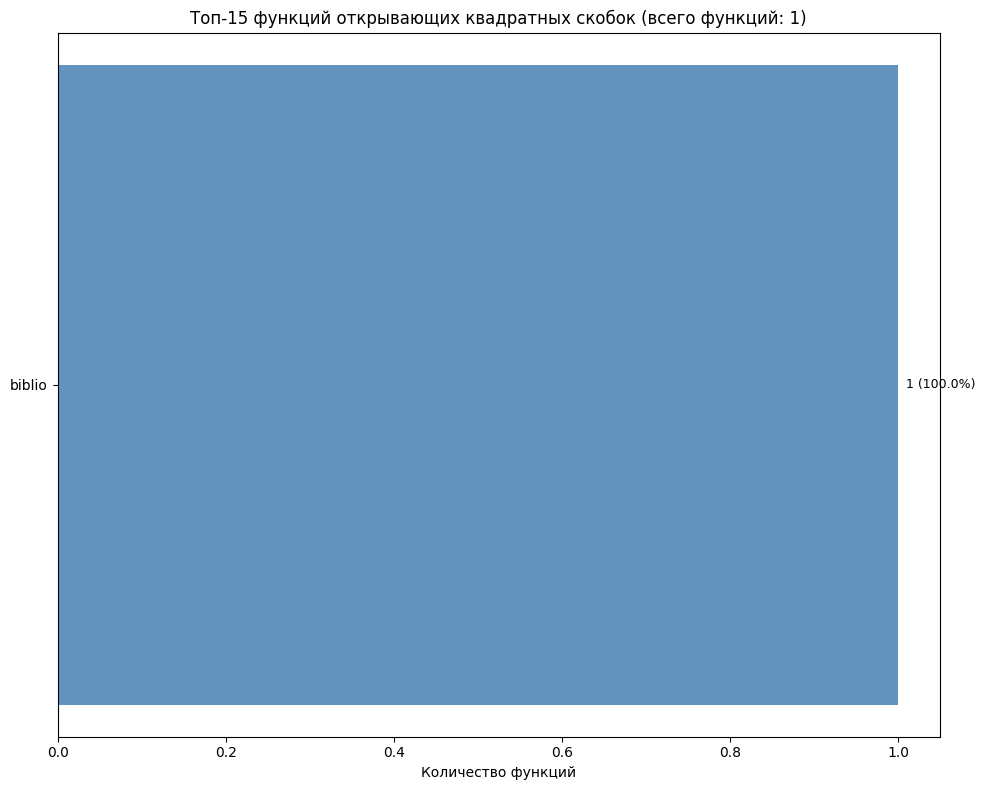

'left_square_bracket_functions_histogram.png'

In [893]:
visualize_punct_functions(left_square_bracket_func_stats_df, 'left_square_bracket', total_left_square_bracket_functions)

### Постановка/непостановка

In [894]:
left_square_bracket_presence_result = analyze_punctuation_presence(df_clean, 'left_square_bracket')

left_square_bracket_presence_lists = left_square_bracket_presence_result['punct_presence_lists']
total_left_square_brackets_presence = left_square_bracket_presence_result['total_puncts_presence']
all_left_square_bracket_presence = left_square_bracket_presence_result['all_presence_values']
total_left_square_bracket_presence_values = left_square_bracket_presence_result['total_presence_values']
left_square_bracket_presence_counter = left_square_bracket_presence_result['presence_counter']
left_square_bracket_presence_stats_df = left_square_bracket_presence_result['presence_stats_df']

Анализ присутствия 'left_square_bracket':

   - Общее количество left_square_bracket: 1
   - Уникальных значений присутствия: 1


In [895]:
print("Статистика по присутствию открывающих квадратных скобок:\n")
print(left_square_bracket_presence_stats_df.to_string(index=False))

Статистика по присутствию открывающих квадратных скобок:

Присутствие  Количество  Доля (%)
    present           1     100.0


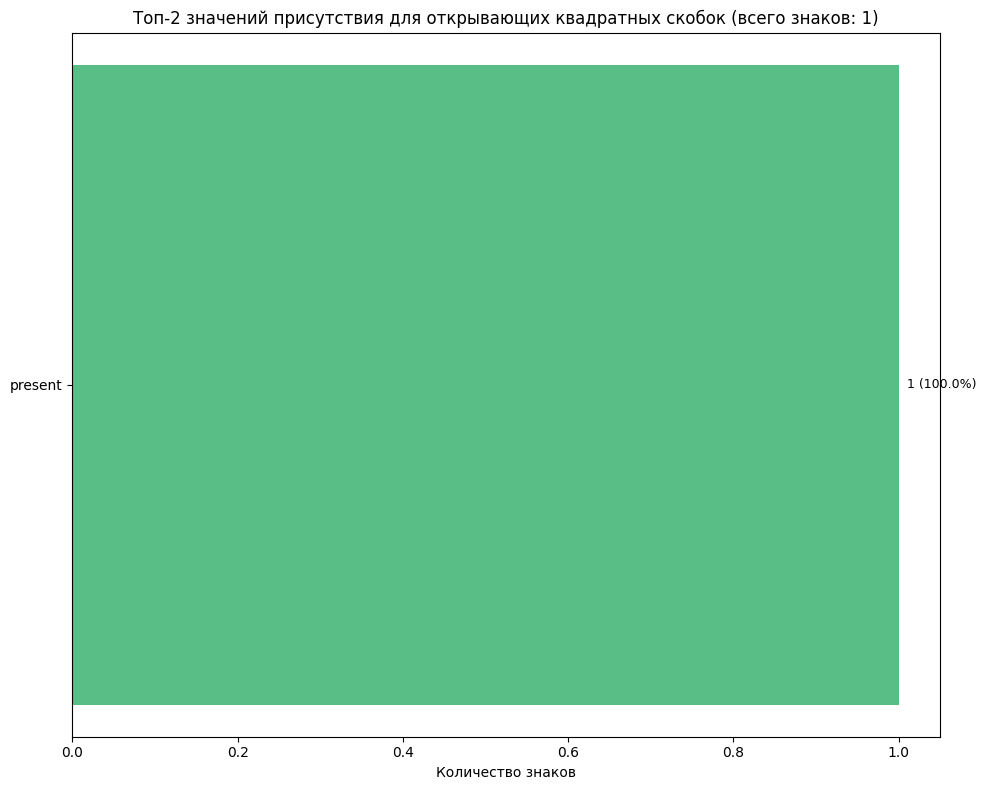

'left_square_bracket_presence_histogram.png'

In [896]:
visualize_presence_stats(left_square_bracket_presence_stats_df, 'left_square_bracket', total_left_square_brackets_presence)

### Нормативность

In [897]:
left_square_bracket_normality_result = analyze_punctuation_normality(df_clean, 'left_square_bracket')

left_square_bracket_normality_lists = left_square_bracket_normality_result['punct_normality_lists']
total_left_square_brackets_normality = left_square_bracket_normality_result['total_puncts_normality']
all_left_square_bracket_normality = left_square_bracket_normality_result['all_normality_values']
total_left_square_bracket_normality_values = left_square_bracket_normality_result['total_normality_values']
left_square_bracket_normality_counter = left_square_bracket_normality_result['normality_counter']
left_square_bracket_normality_stats_df = left_square_bracket_normality_result['normality_stats_df']

Анализ нормативности 'left_square_bracket':

   - Общее количество left_square_bracket: 1
   - Уникальных значений нормативности: 1


In [898]:
print("Статистика по нормативности открывающих квадратных скобок:\n")
print(left_square_bracket_normality_stats_df.to_string(index=False))

Статистика по нормативности открывающих квадратных скобок:

Нормативность  Количество  Доля (%)
      correct           1     100.0


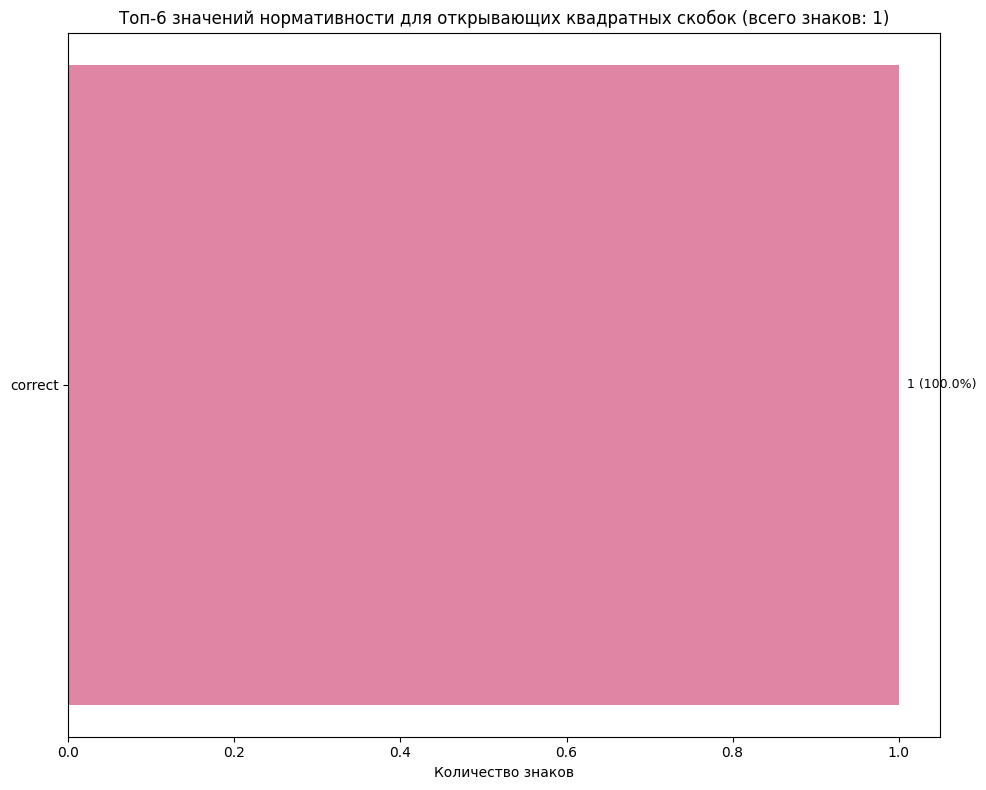

'left_square_bracket_normality_histogram.png'

In [899]:
visualize_normality_stats(left_square_bracket_normality_stats_df, 'left_square_bracket', total_left_square_brackets_normality)

### Степень уверенности

In [900]:
left_square_bracket_reliance_result = analyze_punctuation_reliance(df_clean, 'left_square_bracket',
                                                                   total_puncts_expected=total_left_square_brackets)

left_square_bracket_reliance_lists = left_square_bracket_reliance_result['punct_reliance_lists']
total_left_square_brackets_reliance = left_square_bracket_reliance_result['total_puncts_reliance']
all_left_square_bracket_reliance = left_square_bracket_reliance_result['all_reliance_values']
total_left_square_bracket_reliance_values = left_square_bracket_reliance_result['total_reliance_values']
left_square_bracket_reliance_counter = left_square_bracket_reliance_result['reliance_counter']
left_square_bracket_reliance_stats_df = left_square_bracket_reliance_result['reliance_stats_df']
coverage_pct = left_square_bracket_reliance_result['coverage_pct']

Анализ степени уверенности 'left_square_bracket':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество left_square_bracket (по функциям): 1
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [901]:
print("Статистика по степени уверенности открывающих квадратных скобок:\n")
print(left_square_bracket_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности открывающих квадратных скобок:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


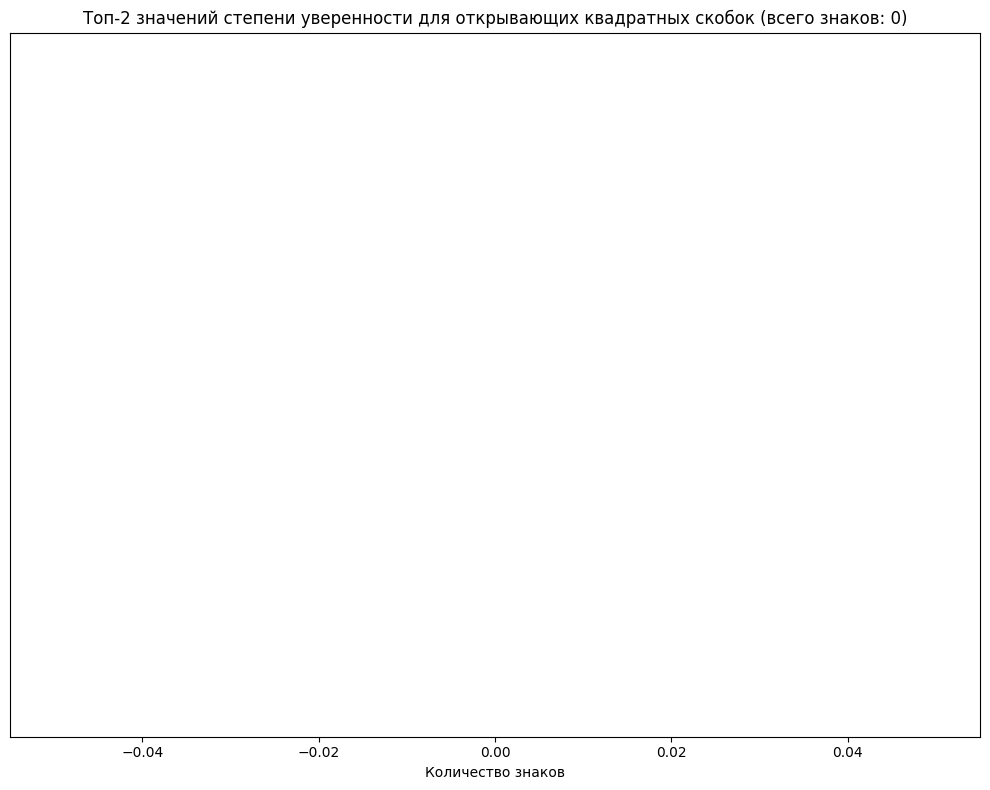

'left_square_bracket_reliance_histogram.png'

In [902]:
visualize_reliance_stats(left_square_bracket_reliance_stats_df, 'left_square_bracket', total_left_square_brackets_reliance)

### Пробелы

In [903]:
left_square_bracket_spaces_result = analyze_punctuation_spaces(df_clean, 'left_square_bracket')

left_square_bracket_spaces_lists = left_square_bracket_spaces_result['punct_spaces_lists']
total_left_square_brackets_spaces = left_square_bracket_spaces_result['total_puncts_spaces']
all_left_square_bracket_spaces = left_square_bracket_spaces_result['all_spaces_values']
total_left_square_bracket_spaces_values = left_square_bracket_spaces_result['total_spaces_values']
left_square_bracket_spaces_counter = left_square_bracket_spaces_result['spaces_counter']
left_square_bracket_spaces_stats_df = left_square_bracket_spaces_result['spaces_stats_df']

Анализ пробелов 'left_square_bracket':

   - Общее количество left_square_bracket: 1
   - Уникальных значений пробелов: 1


In [904]:
print("Статистика по пробелам после открывающих квадратных скобок:\n")
print(left_square_bracket_spaces_stats_df.to_string(index=False))

Статистика по пробелам после открывающих квадратных скобок:

Пробел  Количество  Доля (%)
  left           1     100.0


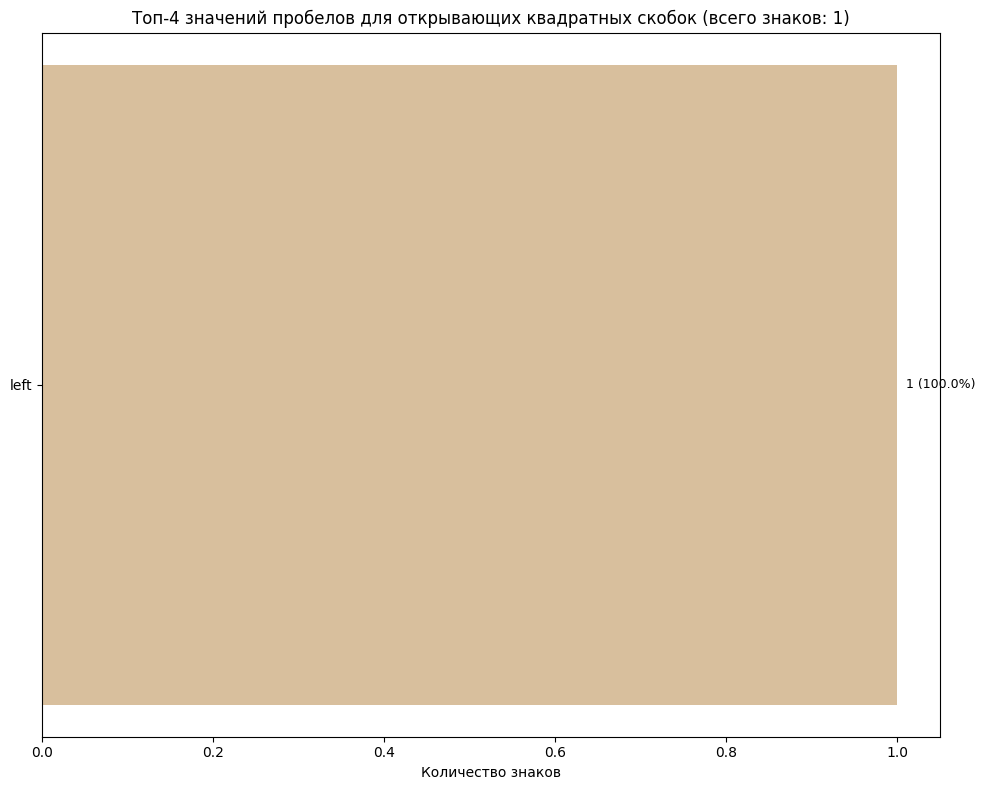

'left_square_bracket_spaces_histogram.png'

In [905]:
visualize_spaces_stats(left_square_bracket_spaces_stats_df, 'left_square_bracket', total_left_square_brackets_spaces)

## Закрывающая квадратная скобка

### Функции знака

In [906]:
right_square_bracket_func_result = analyze_punctuation_func(df_clean, 'right_square_bracket')

right_square_bracket_func_lists = right_square_bracket_func_result['punct_lists']
total_right_square_brackets = right_square_bracket_func_result['total_puncts']
all_right_square_bracket_functions = right_square_bracket_func_result['all_functions']
total_right_square_bracket_functions = right_square_bracket_func_result['total_functions']
right_square_bracket_func_counter = right_square_bracket_func_result['func_counter']
right_square_bracket_func_stats_df = right_square_bracket_func_result['func_stats_df']

Анализ функций 'right_square_bracket':

   - Общее количество right_square_bracket: 1
   - Общее количество функций (с повторениями): 1
   - Среднее количество функций на знак: 1.00
   - Уникальных функций: 1


In [907]:
print("Статистика по функциям закрывающей квадратной скобки:\n")
print(right_square_bracket_func_stats_df.to_string(index=False))

Статистика по функциям закрывающей квадратной скобки:

Функция  Количество  Доля (%)
 biblio           1     100.0


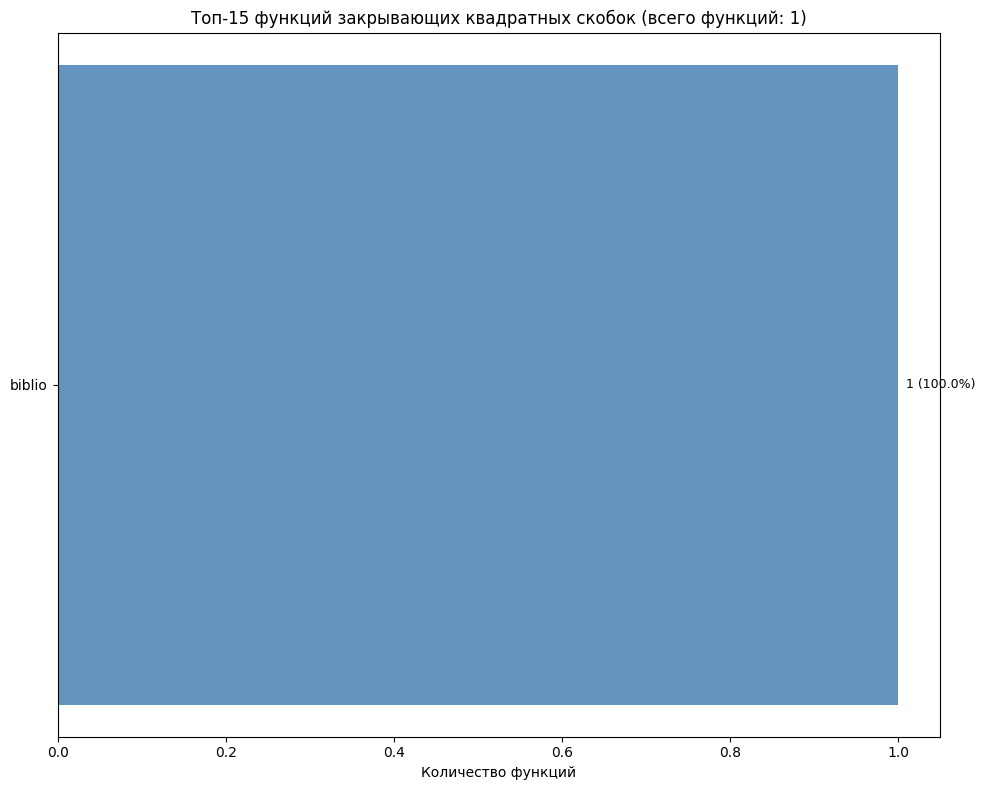

'right_square_bracket_functions_histogram.png'

In [908]:
visualize_punct_functions(right_square_bracket_func_stats_df, 'right_square_bracket', total_right_square_bracket_functions)

### Постановка/непостановка

In [909]:
right_square_bracket_presence_result = analyze_punctuation_presence(df_clean, 'right_square_bracket')

right_square_bracket_presence_lists = right_square_bracket_presence_result['punct_presence_lists']
total_right_square_brackets_presence = right_square_bracket_presence_result['total_puncts_presence']
all_right_square_bracket_presence = right_square_bracket_presence_result['all_presence_values']
total_right_square_bracket_presence_values = right_square_bracket_presence_result['total_presence_values']
right_square_bracket_presence_counter = right_square_bracket_presence_result['presence_counter']
right_square_bracket_presence_stats_df = right_square_bracket_presence_result['presence_stats_df']

Анализ присутствия 'right_square_bracket':

   - Общее количество right_square_bracket: 1
   - Уникальных значений присутствия: 1


In [910]:
print("Статистика по присутствию закрывающих квадратных скобок:\n")
print(right_square_bracket_presence_stats_df.to_string(index=False))

Статистика по присутствию закрывающих квадратных скобок:

Присутствие  Количество  Доля (%)
    present           1     100.0


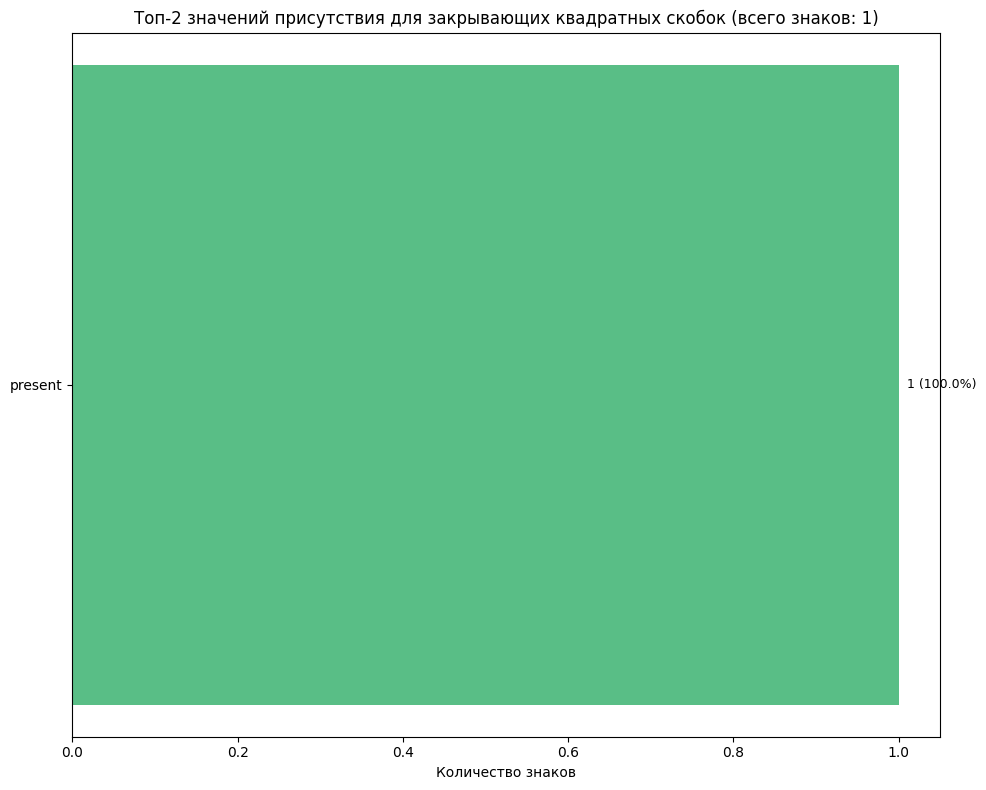

'right_square_bracket_presence_histogram.png'

In [911]:
visualize_presence_stats(right_square_bracket_presence_stats_df, 'right_square_bracket', total_right_square_brackets_presence)

### Нормативность

In [912]:
right_square_bracket_normality_result = analyze_punctuation_normality(df_clean, 'right_square_bracket')

right_square_bracket_normality_lists = right_square_bracket_normality_result['punct_normality_lists']
total_right_square_brackets_normality = right_square_bracket_normality_result['total_puncts_normality']
all_right_square_bracket_normality = right_square_bracket_normality_result['all_normality_values']
total_right_square_bracket_normality_values = right_square_bracket_normality_result['total_normality_values']
right_square_bracket_normality_counter = right_square_bracket_normality_result['normality_counter']
right_square_bracket_normality_stats_df = right_square_bracket_normality_result['normality_stats_df']

Анализ нормативности 'right_square_bracket':

   - Общее количество right_square_bracket: 1
   - Уникальных значений нормативности: 1


In [913]:
print("Статистика по нормативности закрывающих квадратных скобок:\n")
print(right_square_bracket_normality_stats_df.to_string(index=False))

Статистика по нормативности закрывающих квадратных скобок:

Нормативность  Количество  Доля (%)
      correct           1     100.0


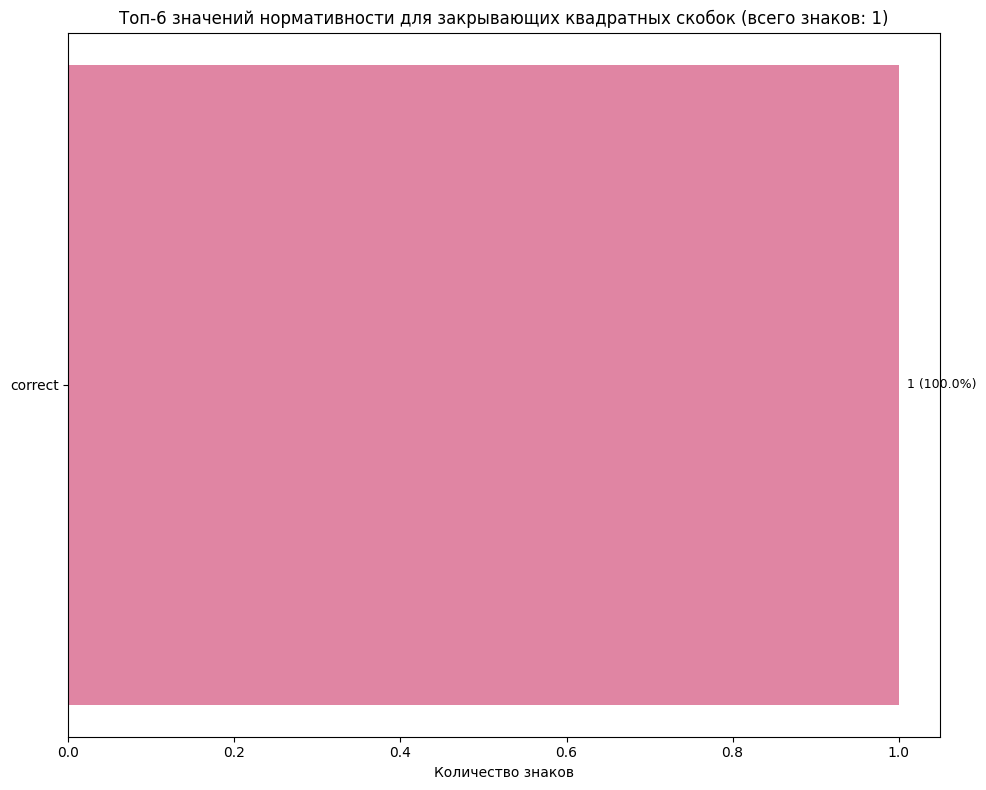

'right_square_bracket_normality_histogram.png'

In [914]:
visualize_normality_stats(right_square_bracket_normality_stats_df, 'right_square_bracket', total_right_square_brackets_normality)

### Степень уверенности

In [915]:
right_square_bracket_reliance_result = analyze_punctuation_reliance(df_clean, 'right_square_bracket',
                                                                    total_puncts_expected=total_right_square_brackets)

right_square_bracket_reliance_lists = right_square_bracket_reliance_result['punct_reliance_lists']
total_right_square_brackets_reliance = right_square_bracket_reliance_result['total_puncts_reliance']
all_right_square_bracket_reliance = right_square_bracket_reliance_result['all_reliance_values']
total_right_square_bracket_reliance_values = right_square_bracket_reliance_result['total_reliance_values']
right_square_bracket_reliance_counter = right_square_bracket_reliance_result['reliance_counter']
right_square_bracket_reliance_stats_df = right_square_bracket_reliance_result['reliance_stats_df']
coverage_pct = right_square_bracket_reliance_result['coverage_pct']

Анализ степени уверенности 'right_square_bracket':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество right_square_bracket (по функциям): 1
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [916]:
print("Статистика по степени уверенности закрывающих квадратных скобок:\n")
print(right_square_bracket_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности закрывающих квадратных скобок:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


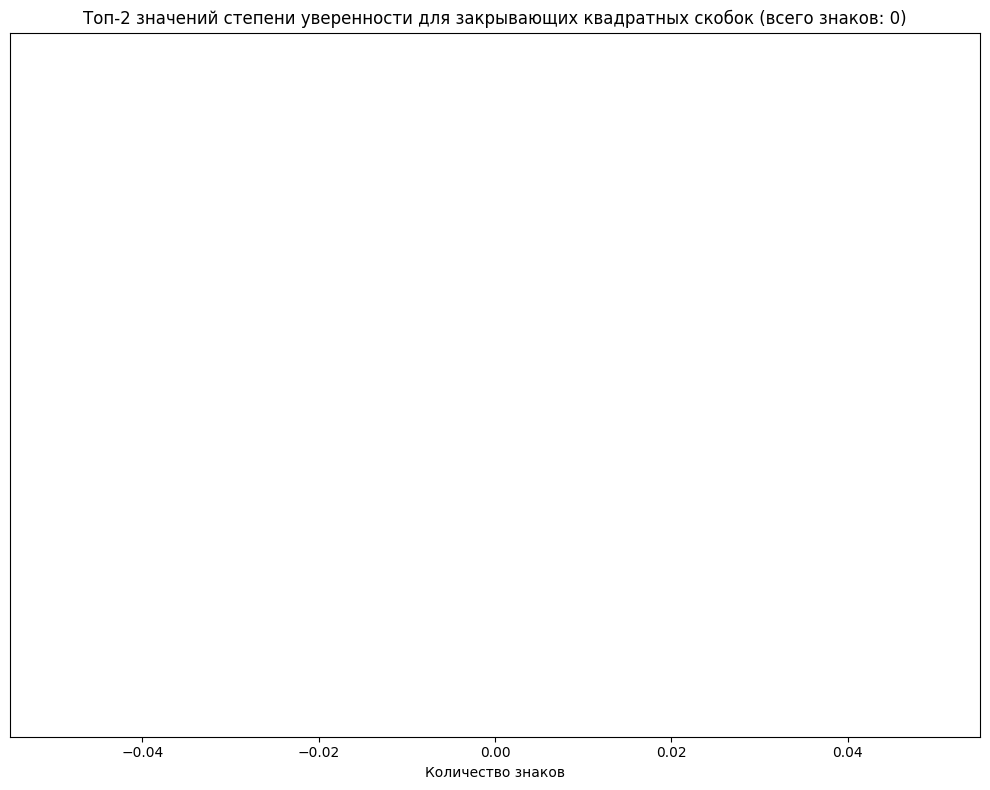

'right_square_bracket_reliance_histogram.png'

In [917]:
visualize_reliance_stats(right_square_bracket_reliance_stats_df, 'right_square_bracket', total_right_square_brackets_reliance)

### Пробелы

In [918]:
right_square_bracket_spaces_result = analyze_punctuation_spaces(df_clean, 'right_square_bracket')

right_square_bracket_spaces_lists = right_square_bracket_spaces_result['punct_spaces_lists']
total_right_square_brackets_spaces = right_square_bracket_spaces_result['total_puncts_spaces']
all_right_square_bracket_spaces = right_square_bracket_spaces_result['all_spaces_values']
total_right_square_bracket_spaces_values = right_square_bracket_spaces_result['total_spaces_values']
right_square_bracket_spaces_counter = right_square_bracket_spaces_result['spaces_counter']
right_square_bracket_spaces_stats_df = right_square_bracket_spaces_result['spaces_stats_df']

Анализ пробелов 'right_square_bracket':

   - Общее количество right_square_bracket: 1
   - Уникальных значений пробелов: 1


In [919]:
print("Статистика по пробелам после закрывающих квадратных скобок:\n")
print(right_square_bracket_spaces_stats_df.to_string(index=False))

Статистика по пробелам после закрывающих квадратных скобок:

Пробел  Количество  Доля (%)
  zero           1     100.0


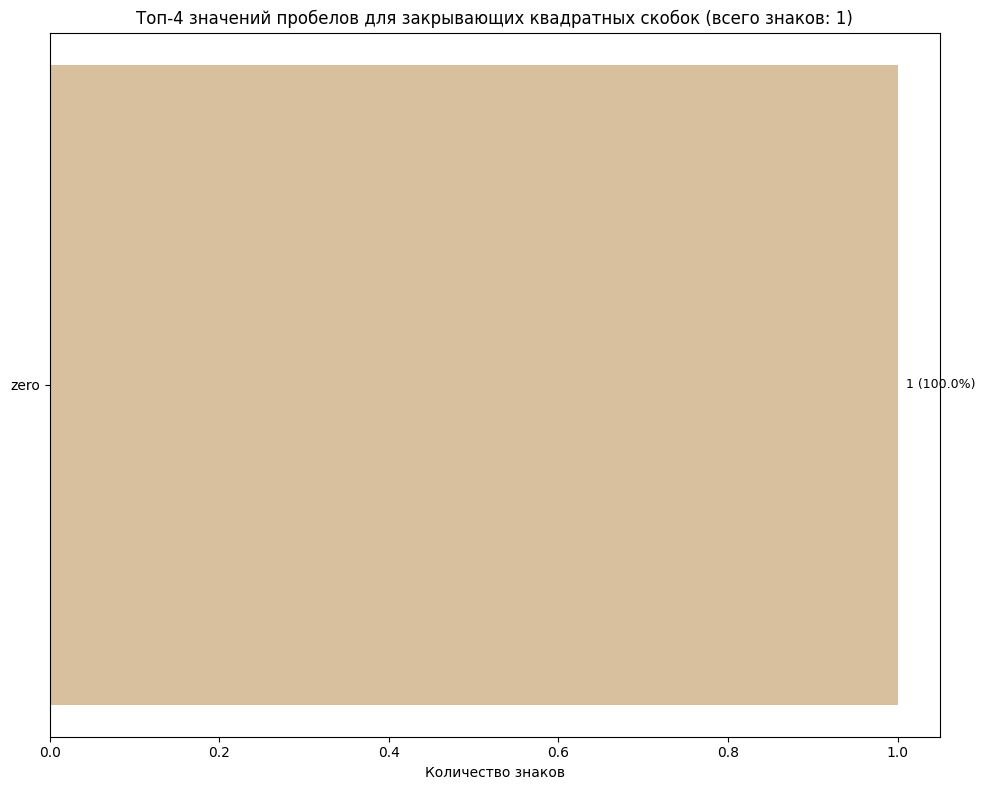

'right_square_bracket_spaces_histogram.png'

In [920]:
visualize_spaces_stats(right_square_bracket_spaces_stats_df, 'right_square_bracket', total_right_square_brackets_spaces)

## Открывающая треугольная скобка

### Функции знака

In [921]:
left_angle_bracket_func_result = analyze_punctuation_func(df_clean, 'left_angle_bracket')

left_angle_bracket_func_lists = left_angle_bracket_func_result['punct_lists']
total_left_angle_brackets = left_angle_bracket_func_result['total_puncts']
all_left_angle_bracket_functions = left_angle_bracket_func_result['all_functions']
total_left_angle_bracket_functions = left_angle_bracket_func_result['total_functions']
left_angle_bracket_func_counter = left_angle_bracket_func_result['func_counter']
left_angle_bracket_func_stats_df = left_angle_bracket_func_result['func_stats_df']

Анализ функций 'left_angle_bracket':

   - Общее количество left_angle_bracket: 0
   - Общее количество функций (с повторениями): 0
   - Уникальных функций: 0


In [922]:
print("Статистика по функциям открывающей треугольной скобки:\n")
print(left_angle_bracket_func_stats_df.to_string(index=False))

Статистика по функциям открывающей треугольной скобки:

Empty DataFrame
Columns: [Функция, Количество, Доля (%)]
Index: []


In [923]:
# visualize_punct_functions(left_angle_bracket_func_stats_df, 'left_angle_bracket', total_left_angle_bracket_functions)

### Постановка/непостановка

In [924]:
left_angle_bracket_presence_result = analyze_punctuation_presence(df_clean, 'left_angle_bracket')

left_angle_bracket_presence_lists = left_angle_bracket_presence_result['punct_presence_lists']
total_left_angle_brackets_presence = left_angle_bracket_presence_result['total_puncts_presence']
all_left_angle_bracket_presence = left_angle_bracket_presence_result['all_presence_values']
total_left_angle_bracket_presence_values = left_angle_bracket_presence_result['total_presence_values']
left_angle_bracket_presence_counter = left_angle_bracket_presence_result['presence_counter']
left_angle_bracket_presence_stats_df = left_angle_bracket_presence_result['presence_stats_df']

Анализ присутствия 'left_angle_bracket':

   - Общее количество left_angle_bracket: 0
   - Уникальных значений присутствия: 0


In [925]:
print("Статистика по присутствию открывающих треугольных скобок:\n")
print(left_angle_bracket_presence_stats_df.to_string(index=False))

Статистика по присутствию открывающих треугольных скобок:

Empty DataFrame
Columns: [Присутствие, Количество, Доля (%)]
Index: []


In [926]:
# visualize_presence_stats(period_presence_stats_df, 'period', total_periods_presence)

### Нормативность

In [927]:
left_angle_bracket_normality_result = analyze_punctuation_normality(df_clean, 'left_angle_bracket')

left_angle_bracket_normality_lists = left_angle_bracket_normality_result['punct_normality_lists']
total_left_angle_brackets_normality = left_angle_bracket_normality_result['total_puncts_normality']
all_left_angle_bracket_normality = left_angle_bracket_normality_result['all_normality_values']
total_left_angle_bracket_normality_values = left_angle_bracket_normality_result['total_normality_values']
left_angle_bracket_normality_counter = left_angle_bracket_normality_result['normality_counter']
left_angle_bracket_normality_stats_df = left_angle_bracket_normality_result['normality_stats_df']

Анализ нормативности 'left_angle_bracket':

   - Общее количество left_angle_bracket: 0
   - Уникальных значений нормативности: 0


In [928]:
print("Статистика по нормативности открывающих треугольных скобок:\n")
print(left_angle_bracket_normality_stats_df.to_string(index=False))

Статистика по нормативности открывающих треугольных скобок:

Empty DataFrame
Columns: [Нормативность, Количество, Доля (%)]
Index: []


In [929]:
# visualize_normality_stats(left_angle_bracket_normality_stats_df, 'left_angle_bracket', total_left_angle_brackets_normality)

### Степень уверенности

In [930]:
left_angle_bracket_reliance_result = analyze_punctuation_reliance(df_clean, 'left_angle_bracket',
                                                                  total_puncts_expected=total_left_angle_brackets)

left_angle_bracket_reliance_lists = left_angle_bracket_reliance_result['punct_reliance_lists']
total_left_angle_brackets_reliance = left_angle_bracket_reliance_result['total_puncts_reliance']
all_left_angle_bracket_reliance = left_angle_bracket_reliance_result['all_reliance_values']
total_left_angle_bracket_reliance_values = left_angle_bracket_reliance_result['total_reliance_values']
left_angle_bracket_reliance_counter = left_angle_bracket_reliance_result['reliance_counter']
left_angle_bracket_reliance_stats_df = left_angle_bracket_reliance_result['reliance_stats_df']
coverage_pct = left_angle_bracket_reliance_result['coverage_pct']

Анализ степени уверенности 'left_angle_bracket':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество left_angle_bracket (по функциям): 0
   - Покрытие разметки: неприменимо (нет знаков)
   - Уникальных значений степени уверенности: 0


In [931]:
print("Статистика по степени уверенности открывающих треугольных скобок:\n")
print(left_angle_bracket_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности открывающих треугольных скобок:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%)]
Index: []


In [932]:
# visualize_reliance_stats(left_angle_bracket_reliance_stats_df, 'left_angle_bracket', total_left_angle_brackets_reliance)

### Пробелы

In [933]:
left_angle_bracket_spaces_result = analyze_punctuation_spaces(df_clean, 'left_angle_bracket')

left_angle_bracket_spaces_lists = left_angle_bracket_spaces_result['punct_spaces_lists']
total_left_angle_brackets_spaces = left_angle_bracket_spaces_result['total_puncts_spaces']
all_left_angle_bracket_spaces = left_angle_bracket_spaces_result['all_spaces_values']
total_left_angle_bracket_spaces_values = left_angle_bracket_spaces_result['total_spaces_values']
left_angle_bracket_spaces_counter = left_angle_bracket_spaces_result['spaces_counter']
left_angle_bracket_spaces_stats_df = left_angle_bracket_spaces_result['spaces_stats_df']

Анализ пробелов 'left_angle_bracket':

   - Общее количество left_angle_bracket: 0
   - Уникальных значений пробелов: 0


In [934]:
print("Статистика по пробелам после открывающих треугольных скобок:\n")
print(left_angle_bracket_spaces_stats_df.to_string(index=False))

Статистика по пробелам после открывающих треугольных скобок:

Empty DataFrame
Columns: [Пробел, Количество, Доля (%)]
Index: []


In [935]:
# visualize_spaces_stats(period_spaces_stats_df, 'period', total_periods_spaces)

## Закрывающая треугольная скобка

### Функции знака

In [936]:
right_angle_bracket_func_result = analyze_punctuation_func(df_clean, 'right_angle_bracket')

right_angle_bracket_func_lists = right_angle_bracket_func_result['punct_lists']
total_right_angle_brackets = right_angle_bracket_func_result['total_puncts']
all_right_angle_bracket_functions = right_angle_bracket_func_result['all_functions']
total_right_angle_bracket_functions = right_angle_bracket_func_result['total_functions']
right_angle_bracket_func_counter = right_angle_bracket_func_result['func_counter']
right_angle_bracket_func_stats_df = right_angle_bracket_func_result['func_stats_df']

Анализ функций 'right_angle_bracket':

   - Общее количество right_angle_bracket: 0
   - Общее количество функций (с повторениями): 0
   - Уникальных функций: 0


In [937]:
print("Статистика по функциям закрывающей треугольной скобки:\n")
print(right_angle_bracket_func_stats_df.to_string(index=False))

Статистика по функциям закрывающей треугольной скобки:

Empty DataFrame
Columns: [Функция, Количество, Доля (%)]
Index: []


In [938]:
# visualize_punct_functions(right_angle_bracket_func_stats_df, 'right_angle_bracket', total_right_angle_bracket_functions)

### Постановка/непостановка

In [939]:
right_angle_bracket_presence_result = analyze_punctuation_presence(df_clean, 'right_angle_bracket')

right_angle_bracket_presence_lists = right_angle_bracket_presence_result['punct_presence_lists']
total_right_angle_brackets_presence = right_angle_bracket_presence_result['total_puncts_presence']
all_right_angle_bracket_presence = right_angle_bracket_presence_result['all_presence_values']
total_right_angle_bracket_presence_values = right_angle_bracket_presence_result['total_presence_values']
right_angle_bracket_presence_counter = right_angle_bracket_presence_result['presence_counter']
right_angle_bracket_presence_stats_df = right_angle_bracket_presence_result['presence_stats_df']

Анализ присутствия 'right_angle_bracket':

   - Общее количество right_angle_bracket: 0
   - Уникальных значений присутствия: 0


In [940]:
print("Статистика по присутствию закрывающих треугольных скобок:\n")
print(right_angle_bracket_presence_stats_df.to_string(index=False))

Статистика по присутствию закрывающих треугольных скобок:

Empty DataFrame
Columns: [Присутствие, Количество, Доля (%)]
Index: []


In [941]:
# visualize_presence_stats(right_angle_bracket_presence_stats_df, 'right_angle_bracket', total_right_angle_brackets_presence)

### Нормативность

In [942]:
right_angle_bracket_normality_result = analyze_punctuation_normality(df_clean, 'right_angle_bracket')

right_angle_bracket_normality_lists = right_angle_bracket_normality_result['punct_normality_lists']
total_right_angle_brackets_normality = right_angle_bracket_normality_result['total_puncts_normality']
all_right_angle_bracket_normality = right_angle_bracket_normality_result['all_normality_values']
total_right_angle_bracket_normality_values = right_angle_bracket_normality_result['total_normality_values']
right_angle_bracket_normality_counter = right_angle_bracket_normality_result['normality_counter']
right_angle_bracket_normality_stats_df = right_angle_bracket_normality_result['normality_stats_df']

Анализ нормативности 'right_angle_bracket':

   - Общее количество right_angle_bracket: 0
   - Уникальных значений нормативности: 0


In [943]:
print("Статистика по нормативности закрывающих треугольных скобок:\n")
print(right_angle_bracket_normality_stats_df.to_string(index=False))

Статистика по нормативности закрывающих треугольных скобок:

Empty DataFrame
Columns: [Нормативность, Количество, Доля (%)]
Index: []


In [944]:
# visualize_normality_stats(right_angle_bracket_normality_stats_df, 'right_angle_bracket', total_right_angle_brackets_normality)

### Степень уверенности

In [945]:
right_angle_bracket_reliance_result = analyze_punctuation_reliance(df_clean, 'right_angle_bracket',
                                                                   total_puncts_expected=total_right_angle_brackets)

right_angle_bracket_reliance_lists = right_angle_bracket_reliance_result['punct_reliance_lists']
total_right_angle_brackets_reliance = right_angle_bracket_reliance_result['total_puncts_reliance']
all_right_angle_bracket_reliance = right_angle_bracket_reliance_result['all_reliance_values']
total_right_angle_bracket_reliance_values = right_angle_bracket_reliance_result['total_reliance_values']
right_angle_bracket_reliance_counter = right_angle_bracket_reliance_result['reliance_counter']
right_angle_bracket_reliance_stats_df = right_angle_bracket_reliance_result['reliance_stats_df']
coverage_pct = right_angle_bracket_reliance_result['coverage_pct']

Анализ степени уверенности 'right_angle_bracket':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество right_angle_bracket (по функциям): 0
   - Покрытие разметки: неприменимо (нет знаков)
   - Уникальных значений степени уверенности: 0


In [946]:
print("Статистика по степени уверенности закрывающих треугольных скобок:\n")
print(right_angle_bracket_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности закрывающих треугольных скобок:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%)]
Index: []


In [947]:
# visualize_reliance_stats(right_angle_bracket_reliance_stats_df, 'right_angle_bracket', total_right_angle_brackets_reliance)

### Пробелы

In [948]:
right_angle_bracket_spaces_result = analyze_punctuation_spaces(df_clean, 'right_angle_bracket')

right_angle_bracket_spaces_lists = right_angle_bracket_spaces_result['punct_spaces_lists']
total_right_angle_brackets_spaces = right_angle_bracket_spaces_result['total_puncts_spaces']
all_right_angle_bracket_spaces = right_angle_bracket_spaces_result['all_spaces_values']
total_right_angle_bracket_spaces_values = right_angle_bracket_spaces_result['total_spaces_values']
right_angle_bracket_spaces_counter = right_angle_bracket_spaces_result['spaces_counter']
right_angle_bracket_spaces_stats_df = right_angle_bracket_spaces_result['spaces_stats_df']

Анализ пробелов 'right_angle_bracket':

   - Общее количество right_angle_bracket: 0
   - Уникальных значений пробелов: 0


In [949]:
print("Статистика по пробелам после закрывающих треугольных скобок:\n")
print(right_angle_bracket_spaces_stats_df.to_string(index=False))

Статистика по пробелам после закрывающих треугольных скобок:

Empty DataFrame
Columns: [Пробел, Количество, Доля (%)]
Index: []


In [950]:
# visualize_spaces_stats(right_angle_bracket_spaces_stats_df, 'right_angle_bracket', total_right_angle_brackets_spaces)

## Открывающая кавычка

### Функции знака

In [951]:
open_quote_func_result = analyze_punctuation_func(df_clean, 'open_quote')

open_quote_func_lists = open_quote_func_result['punct_lists']
total_open_quotes = open_quote_func_result['total_puncts']
all_open_quote_functions = open_quote_func_result['all_functions']
total_open_quote_functions = open_quote_func_result['total_functions']
open_quote_func_counter = open_quote_func_result['func_counter']
open_quote_func_stats_df = open_quote_func_result['func_stats_df']

Анализ функций 'open_quote':

   - Общее количество open_quote: 59
   - Общее количество функций (с повторениями): 64
   - Среднее количество функций на знак: 1.08
   - Уникальных функций: 9


In [952]:
print("Статистика по функциям открывающей кавычки:\n")
print(open_quote_func_stats_df.to_string(index=False))

Статистика по функциям открывающей кавычки:

         Функция  Количество  Доля (%)
      name_begin          24     37.50
     quote_begin          21     32.81
     figur_begin           9     14.06
           figur           5      7.81
digit_name_begin           1      1.56
      out_quotes           1      1.56
    inner_quotes           1      1.56
           irony           1      1.56
      detachment           1      1.56


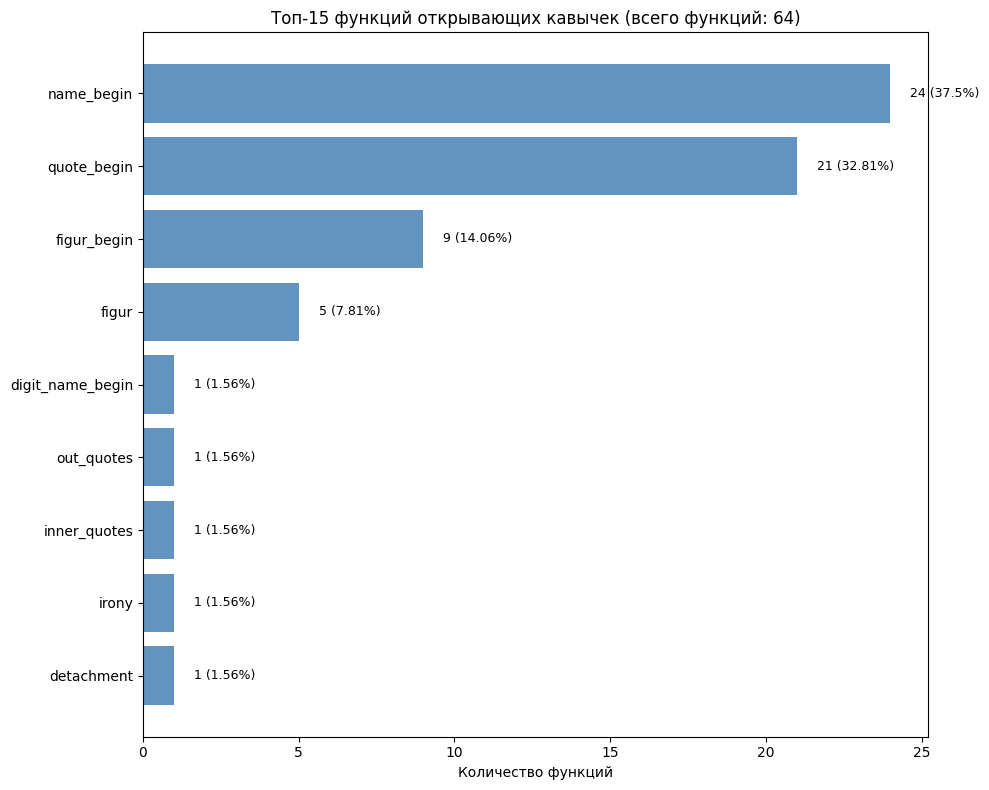

'open_quote_functions_histogram.png'

In [953]:
visualize_punct_functions(open_quote_func_stats_df, 'open_quote', total_open_quote_functions)

### Постановка/непостановка

In [954]:
open_quote_presence_result = analyze_punctuation_presence(df_clean, 'open_quote')

open_quote_presence_lists = open_quote_presence_result['punct_presence_lists']
total_open_quotes_presence = open_quote_presence_result['total_puncts_presence']
all_open_quote_presence = open_quote_presence_result['all_presence_values']
total_open_quote_presence_values = open_quote_presence_result['total_presence_values']
open_quote_presence_counter = open_quote_presence_result['presence_counter']
open_quote_presence_stats_df = open_quote_presence_result['presence_stats_df']

Анализ присутствия 'open_quote':

   - Общее количество open_quote: 59
   - Уникальных значений присутствия: 2


In [955]:
print("Статистика по присутствию открывающих кавычек:\n")
print(open_quote_presence_stats_df.to_string(index=False))

Статистика по присутствию открывающих кавычек:

Присутствие  Количество  Доля (%)
    present          58     98.31
    missing           1      1.69


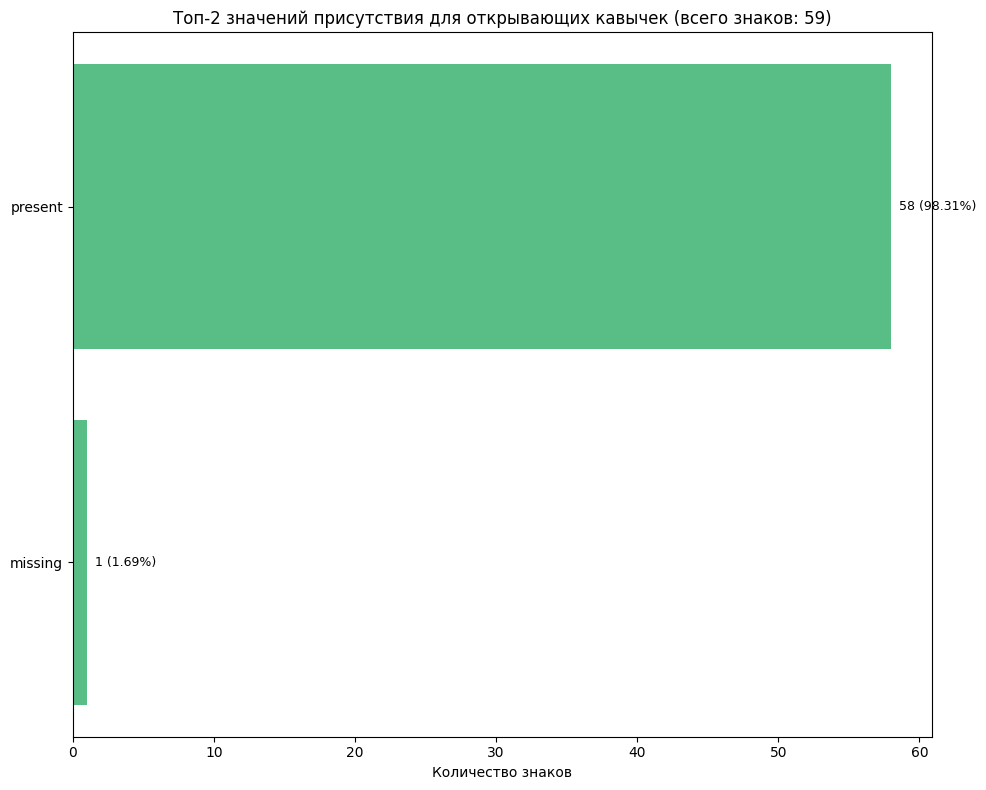

'open_quote_presence_histogram.png'

In [956]:
visualize_presence_stats(open_quote_presence_stats_df, 'open_quote', total_open_quotes_presence)

### Нормативность

In [957]:
open_quote_normality_result = analyze_punctuation_normality(df_clean, 'open_quote')

open_quote_normality_lists = open_quote_normality_result['punct_normality_lists']
total_open_quotes_normality = open_quote_normality_result['total_puncts_normality']
all_open_quote_normality = open_quote_normality_result['all_normality_values']
total_open_quote_normality_values = open_quote_normality_result['total_normality_values']
open_quote_normality_counter = open_quote_normality_result['normality_counter']
open_quote_normality_stats_df = open_quote_normality_result['normality_stats_df']

Анализ нормативности 'open_quote':

   - Общее количество open_quote: 61
   - Уникальных значений нормативности: 3


In [958]:
print("Статистика по нормативности открывающих кавычек:\n")
print(open_quote_normality_stats_df.to_string(index=False))

Статистика по нормативности открывающих кавычек:

Нормативность  Количество  Доля (%)
      correct          58     95.08
          alt           2      3.28
      mistake           1      1.64


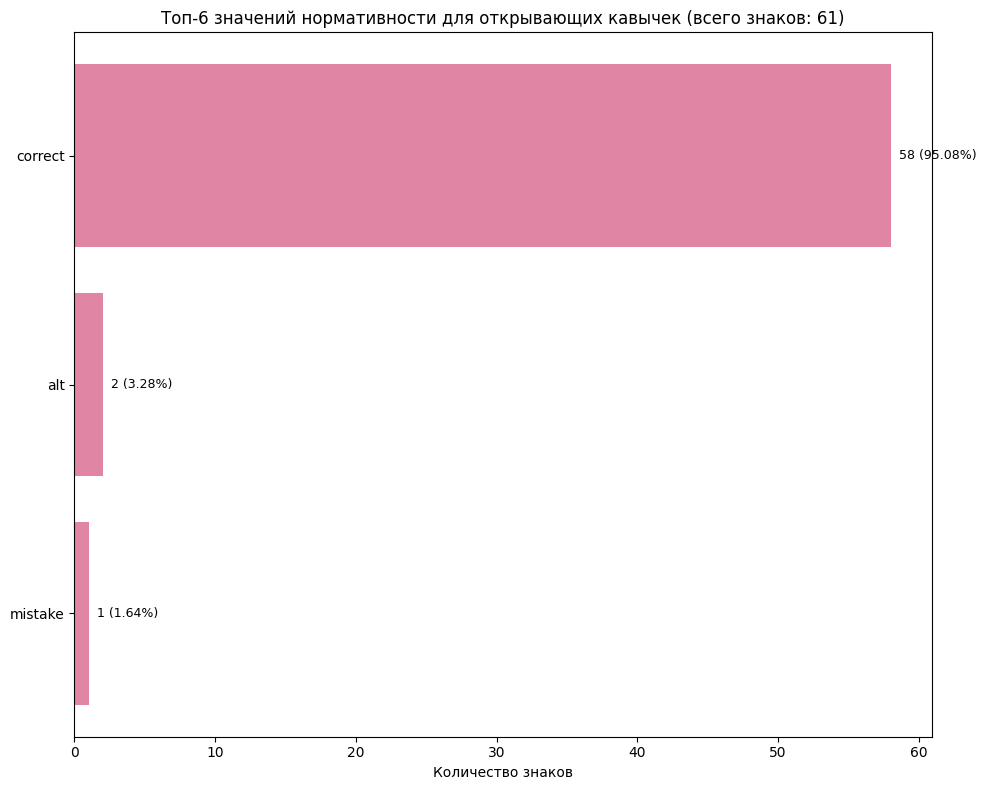

'open_quote_normality_histogram.png'

In [959]:
visualize_normality_stats(open_quote_normality_stats_df, 'open_quote', total_open_quotes_normality)

### Степень уверенности

In [960]:
open_quote_reliance_result = analyze_punctuation_reliance(df_clean, 'open_quote',
                                                          total_puncts_expected=total_open_quotes)

open_quote_reliance_lists = open_quote_reliance_result['punct_reliance_lists']
total_open_quotes_reliance = open_quote_reliance_result['total_puncts_reliance']
all_open_quote_reliance = open_quote_reliance_result['all_reliance_values']
total_open_quote_reliance_values = open_quote_reliance_result['total_reliance_values']
open_quote_reliance_counter = open_quote_reliance_result['reliance_counter']
open_quote_reliance_stats_df = open_quote_reliance_result['reliance_stats_df']
coverage_pct = open_quote_reliance_result['coverage_pct']

Анализ степени уверенности 'open_quote':

   - Знаков с размеченной степенью уверенности: 3
   - Общее количество open_quote (по функциям): 59
   - Покрытие разметки степени уверенности: 5.08%
   - Уникальных значений степени уверенности: 1


In [961]:
print("Статистика по степени уверенности открывающих кавычек:\n")
print(open_quote_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности открывающих кавычек:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           3     100.0                   5.08


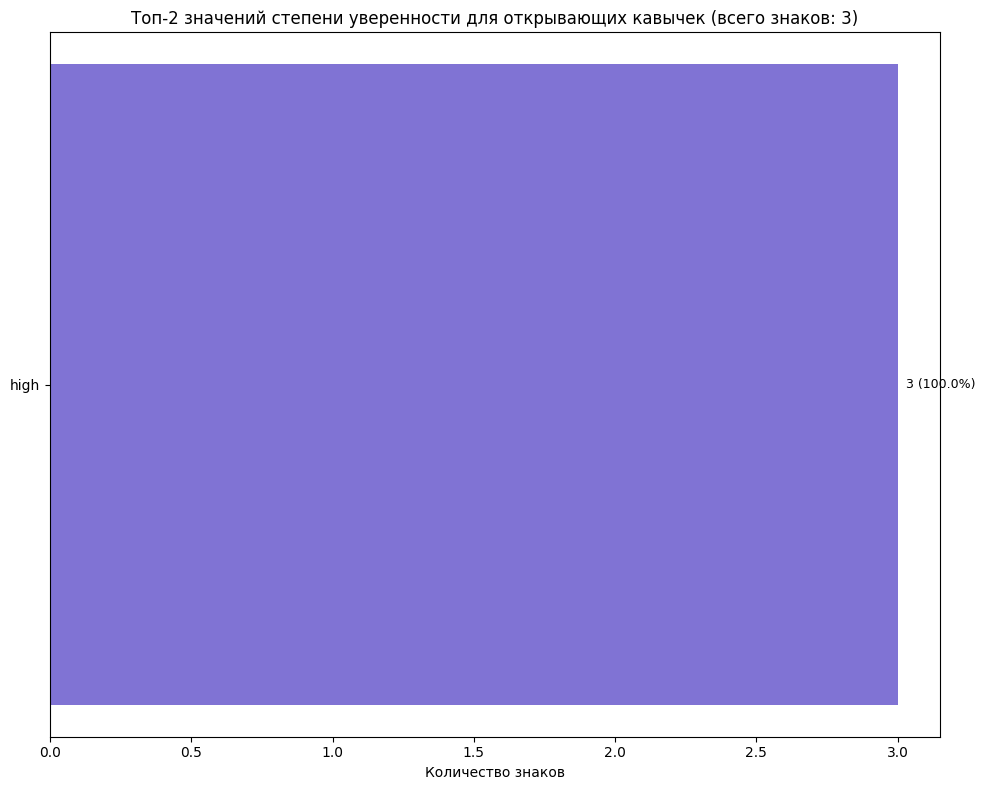

'open_quote_reliance_histogram.png'

In [962]:
visualize_reliance_stats(open_quote_reliance_stats_df, 'open_quote', total_open_quotes_reliance)

### Пробелы

In [963]:
open_quote_spaces_result = analyze_punctuation_spaces(df_clean, 'open_quote')

open_quote_spaces_lists = open_quote_spaces_result['punct_spaces_lists']
total_open_quotes_spaces = open_quote_spaces_result['total_puncts_spaces']
all_open_quote_spaces = open_quote_spaces_result['all_spaces_values']
total_open_quote_spaces_values = open_quote_spaces_result['total_spaces_values']
open_quote_spaces_counter = open_quote_spaces_result['spaces_counter']
open_quote_spaces_stats_df = open_quote_spaces_result['spaces_stats_df']

Анализ пробелов 'open_quote':

   - Общее количество open_quote: 56
   - Уникальных значений пробелов: 3


In [964]:
print("Статистика по пробелам после открывающих кавычек:\n")
print(open_quote_spaces_stats_df.to_string(index=False))

Статистика по пробелам после открывающих кавычек:

   Пробел  Количество  Доля (%)
     left          51     91.07
     zero           4      7.14
bilateral           1      1.79


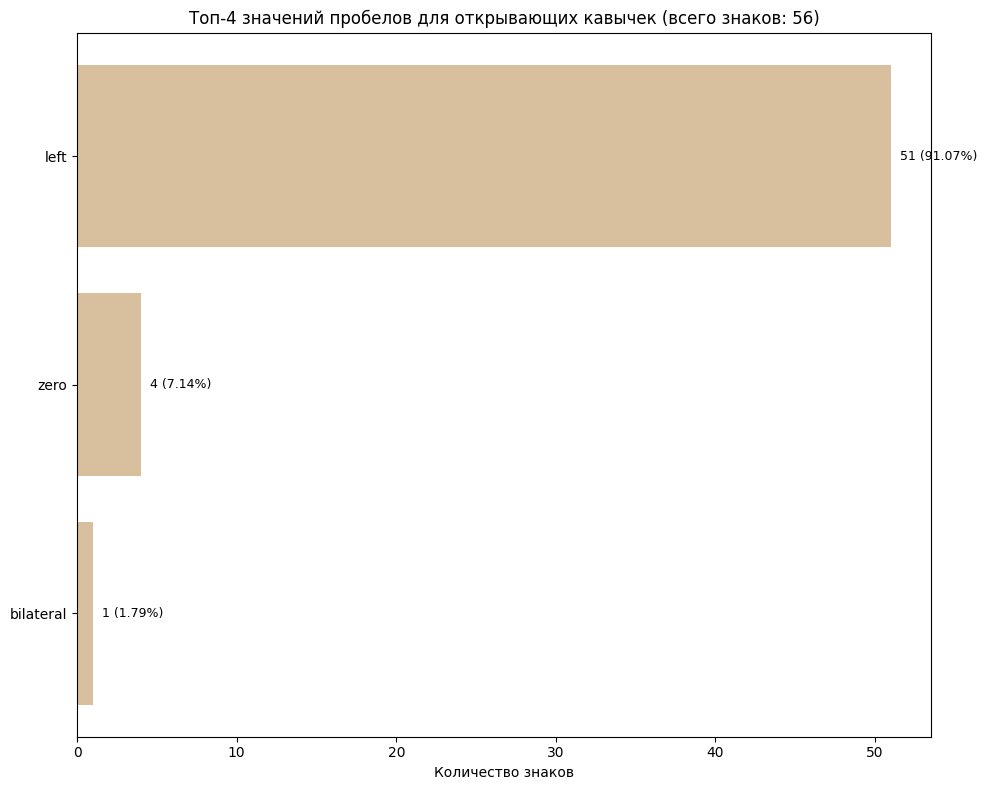

'open_quote_spaces_histogram.png'

In [965]:
visualize_spaces_stats(open_quote_spaces_stats_df, 'open_quote', total_open_quotes_spaces)

### Форма выражения

In [966]:
open_quote_expression_result = analyze_punctuation_expression(df_clean, 'open_quote')

open_quote_expression_lists = open_quote_expression_result['punct_expression_lists']
total_open_quotes_expression = open_quote_expression_result['total_puncts_expression']
all_open_quote_expression = open_quote_expression_result['all_expression_values']
total_open_quote_expression_values = open_quote_expression_result['total_expression_values']
open_quote_expression_counter = open_quote_expression_result['expression_counter']
open_quote_expression_stats_df = open_quote_expression_result['expression_stats_df']

Анализ формы выражения 'open_quote':

   - Общее количество open_quote: 59
   - Уникальных форм выражения: 3


In [967]:
print("Статистика по форме выражения открывающих кавычек:\n")
print(open_quote_expression_stats_df.to_string(index=False))

Статистика по форме выражения открывающих кавычек:

  Форма выражения  Количество  Доля (%)
left_double_angle          48     81.36
   quotation_mark          10     16.95
 double_low_qoute           1      1.69


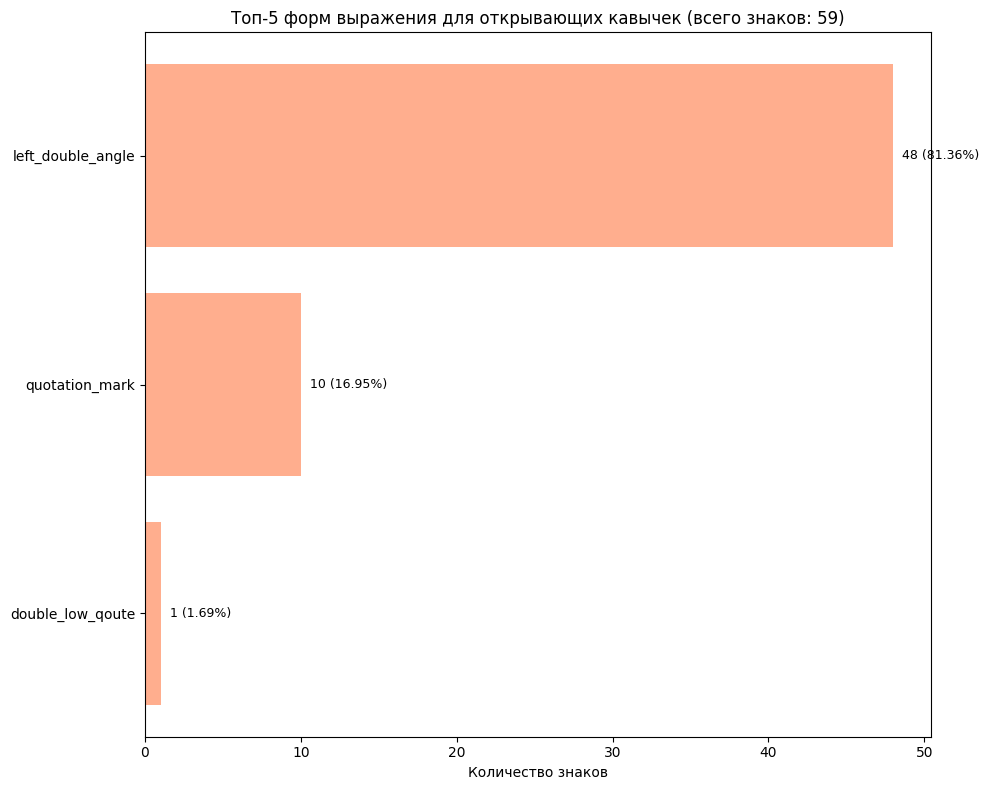

'open_quote_expression_histogram.png'

In [968]:
visualize_expression_stats(open_quote_expression_stats_df, 'open_quote', total_open_quotes_expression)

## Закрывающая кавычка

### Функции знака

In [969]:
close_quote_func_result = analyze_punctuation_func(df_clean, 'close_quote')

close_quote_func_lists = close_quote_func_result['punct_lists']
total_close_quotes = close_quote_func_result['total_puncts']
all_close_quote_functions = close_quote_func_result['all_functions']
total_close_quote_functions = close_quote_func_result['total_functions']
close_quote_func_counter = close_quote_func_result['func_counter']
close_quote_func_stats_df = close_quote_func_result['func_stats_df']

Анализ функций 'close_quote':

   - Общее количество close_quote: 58
   - Общее количество функций (с повторениями): 63
   - Среднее количество функций на знак: 1.09
   - Уникальных функций: 12


In [970]:
print("Статистика по функциям закрывающей кавычки:\n")
print(close_quote_func_stats_df.to_string(index=False))

Статистика по функциям закрывающей кавычки:

          Функция  Количество  Доля (%)
      name_finish          23     36.51
     quote_finish          19     30.16
     figur_finish           8     12.70
            figur           5      7.94
digit_name_finish           1      1.59
      figur_figur           1      1.59
     inner_quotes           1      1.59
     finish_begin           1      1.59
       out_quotes           1      1.59
      quote_begin           1      1.59
            irony           1      1.59
       detachment           1      1.59


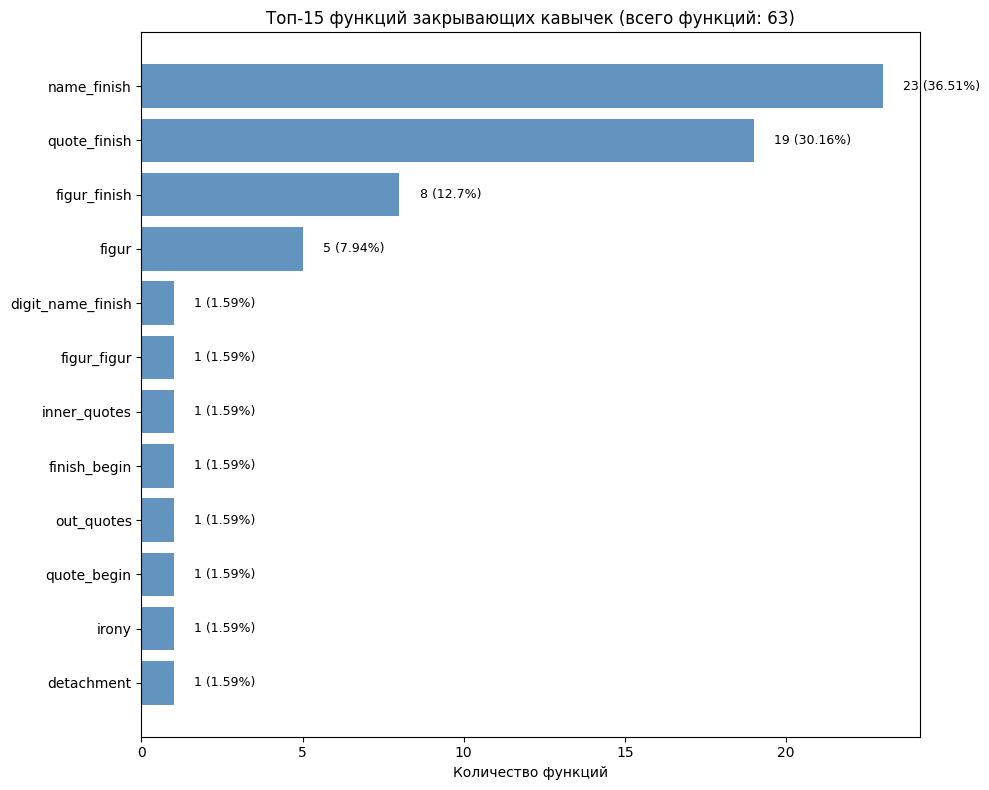

'close_quote_functions_histogram.png'

In [971]:
visualize_punct_functions(close_quote_func_stats_df, 'close_quote', total_close_quote_functions)

### Постановка/непостановка

In [972]:
close_quote_presence_result = analyze_punctuation_presence(df_clean, 'close_quote')

close_quote_presence_lists = close_quote_presence_result['punct_presence_lists']
total_close_quotes_presence = close_quote_presence_result['total_puncts_presence']
all_close_quote_presence = close_quote_presence_result['all_presence_values']
total_close_quote_presence_values = close_quote_presence_result['total_presence_values']
close_quote_presence_counter = close_quote_presence_result['presence_counter']
close_quote_presence_stats_df = close_quote_presence_result['presence_stats_df']

Анализ присутствия 'close_quote':

   - Общее количество close_quote: 58
   - Уникальных значений присутствия: 2


In [973]:
print("Статистика по присутствию закрывающих кавычек:\n")
print(close_quote_presence_stats_df.to_string(index=False))

Статистика по присутствию закрывающих кавычек:

Присутствие  Количество  Доля (%)
    present          57     98.28
    missing           1      1.72


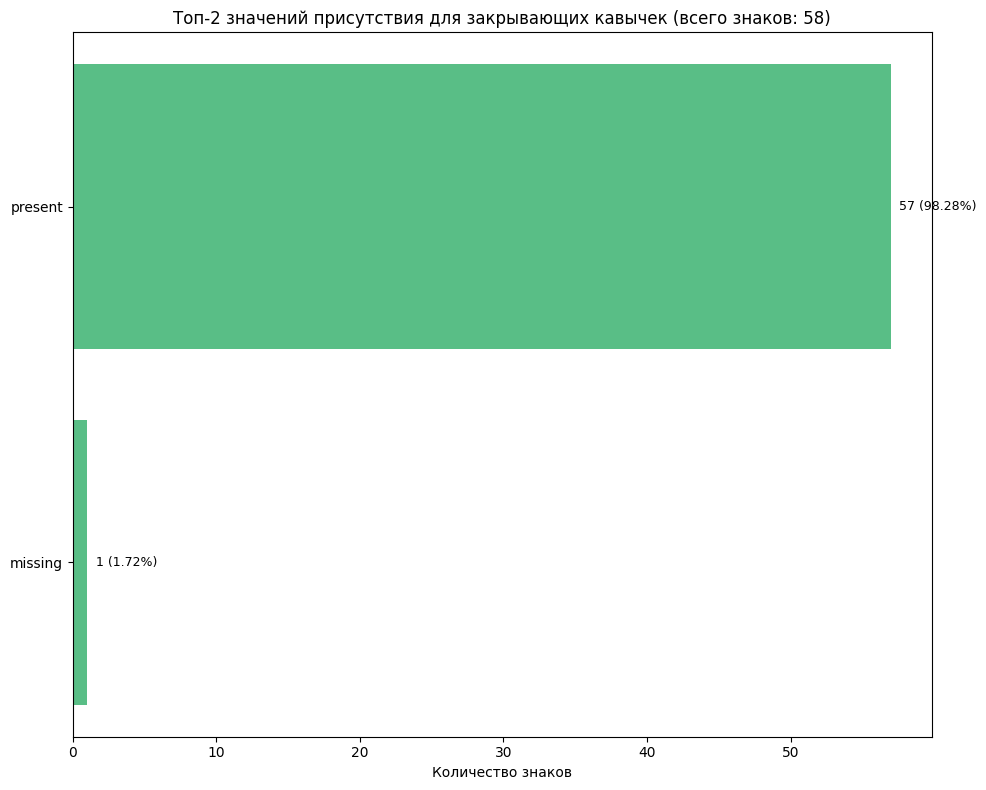

'close_quote_presence_histogram.png'

In [974]:
visualize_presence_stats(close_quote_presence_stats_df, 'close_quote', total_close_quotes_presence)

### Нормативность

In [975]:
close_quote_normality_result = analyze_punctuation_normality(df_clean, 'close_quote')

close_quote_normality_lists = close_quote_normality_result['punct_normality_lists']
total_close_quotes_normality = close_quote_normality_result['total_puncts_normality']
all_close_quote_normality = close_quote_normality_result['all_normality_values']
total_close_quote_normality_values = close_quote_normality_result['total_normality_values']
close_quote_normality_counter = close_quote_normality_result['normality_counter']
close_quote_normality_stats_df = close_quote_normality_result['normality_stats_df']

Анализ нормативности 'close_quote':

   - Общее количество close_quote: 60
   - Уникальных значений нормативности: 3


In [976]:
print("Статистика по нормативности закрывающих кавычек:\n")
print(close_quote_normality_stats_df.to_string(index=False))

Статистика по нормативности закрывающих кавычек:

Нормативность  Количество  Доля (%)
      correct          56     93.33
          alt           2      3.33
      mistake           2      3.33


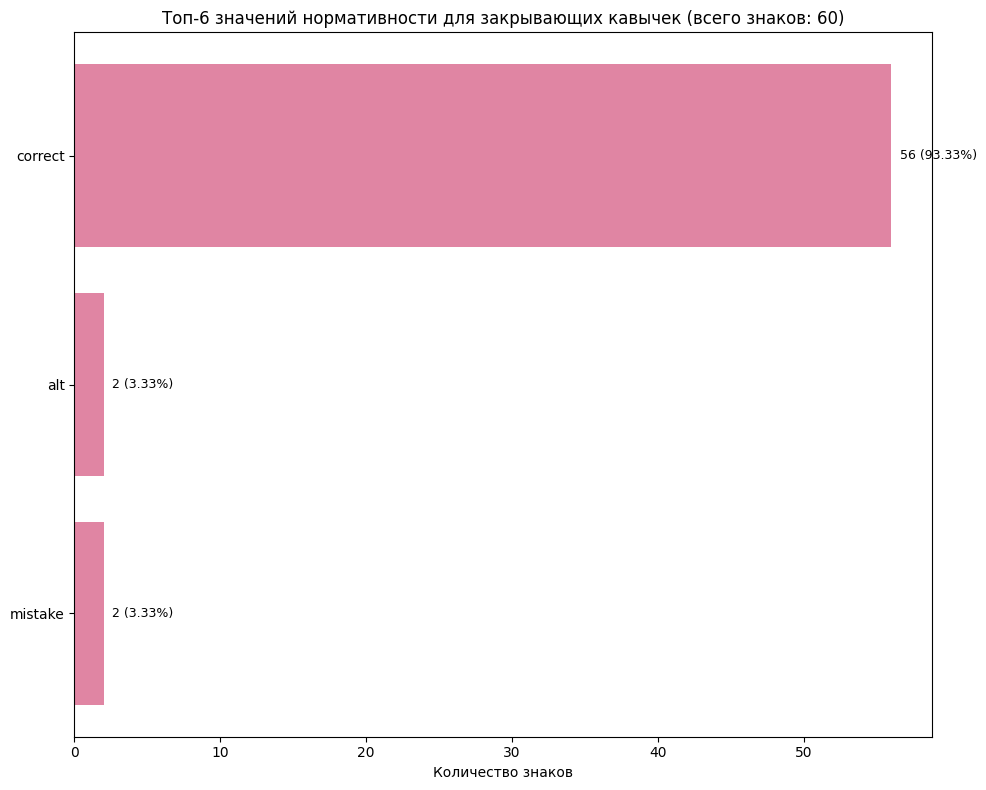

'close_quote_normality_histogram.png'

In [977]:
visualize_normality_stats(close_quote_normality_stats_df, 'close_quote', total_close_quotes_normality)

### Степень уверенности

In [978]:
close_quote_reliance_result = analyze_punctuation_reliance(df_clean, 'close_quote',
                                                           total_puncts_expected=total_close_quotes)

close_quote_reliance_lists = close_quote_reliance_result['punct_reliance_lists']
total_close_quotes_reliance = close_quote_reliance_result['total_puncts_reliance']
all_close_quote_reliance = close_quote_reliance_result['all_reliance_values']
total_close_quote_reliance_values = close_quote_reliance_result['total_reliance_values']
close_quote_reliance_counter = close_quote_reliance_result['reliance_counter']
close_quote_reliance_stats_df = close_quote_reliance_result['reliance_stats_df']
coverage_pct = close_quote_reliance_result['coverage_pct']

Анализ степени уверенности 'close_quote':

   - Знаков с размеченной степенью уверенности: 5
   - Общее количество close_quote (по функциям): 58
   - Покрытие разметки степени уверенности: 8.62%
   - Уникальных значений степени уверенности: 1


In [979]:
print("Статистика по степени уверенности закрывающих кавычек:\n")
print(close_quote_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности закрывающих кавычек:

Степень уверенности  Количество  Доля (%)  Покрытие разметки (%)
               high           5     100.0                   8.62


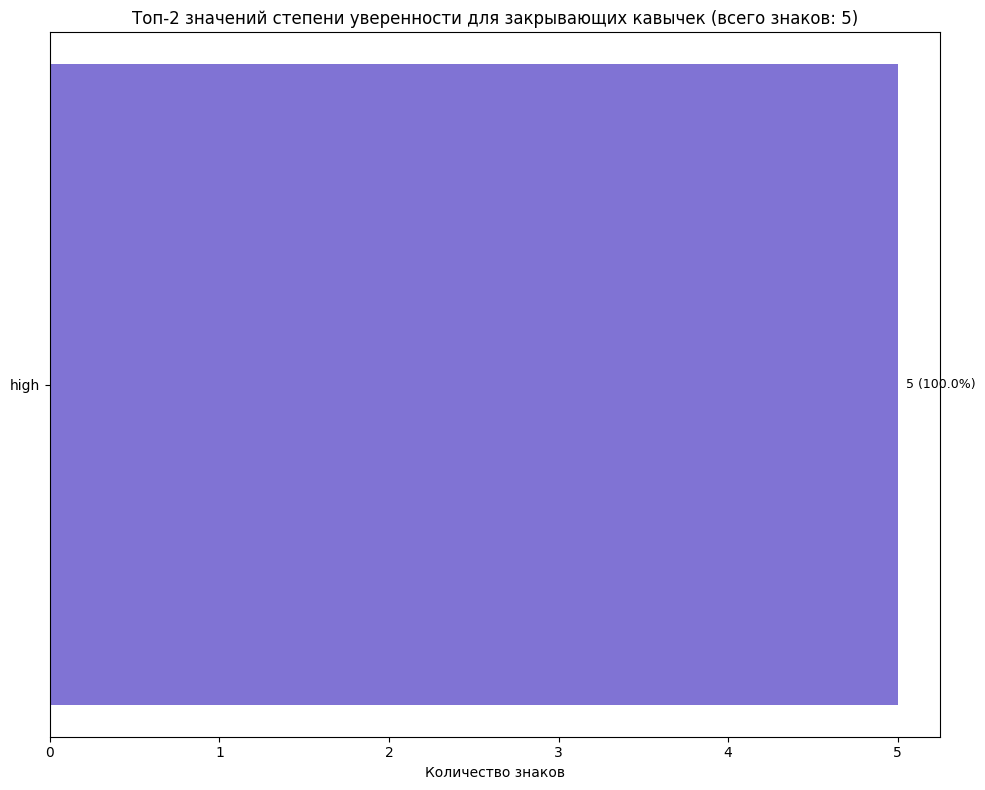

'close_quote_reliance_histogram.png'

In [980]:
visualize_reliance_stats(close_quote_reliance_stats_df, 'close_quote', total_close_quotes_reliance)

### Пробелы

In [981]:
close_quote_spaces_result = analyze_punctuation_spaces(df_clean, 'close_quote')

close_quote_spaces_lists = close_quote_spaces_result['punct_spaces_lists']
total_close_quotes_spaces = close_quote_spaces_result['total_puncts_spaces']
all_close_quote_spaces = close_quote_spaces_result['all_spaces_values']
total_close_quote_spaces_values = close_quote_spaces_result['total_spaces_values']
close_quote_spaces_counter = close_quote_spaces_result['spaces_counter']
close_quote_spaces_stats_df = close_quote_spaces_result['spaces_stats_df']

Анализ пробелов 'close_quote':

   - Общее количество close_quote: 55
   - Уникальных значений пробелов: 4


In [982]:
print("Статистика по пробелам после закрывающих кавычек:\n")
print(close_quote_spaces_stats_df.to_string(index=False))

Статистика по пробелам после закрывающих кавычек:

   Пробел  Количество  Доля (%)
     zero          36     65.45
    right          17     30.91
bilateral           1      1.82
     left           1      1.82


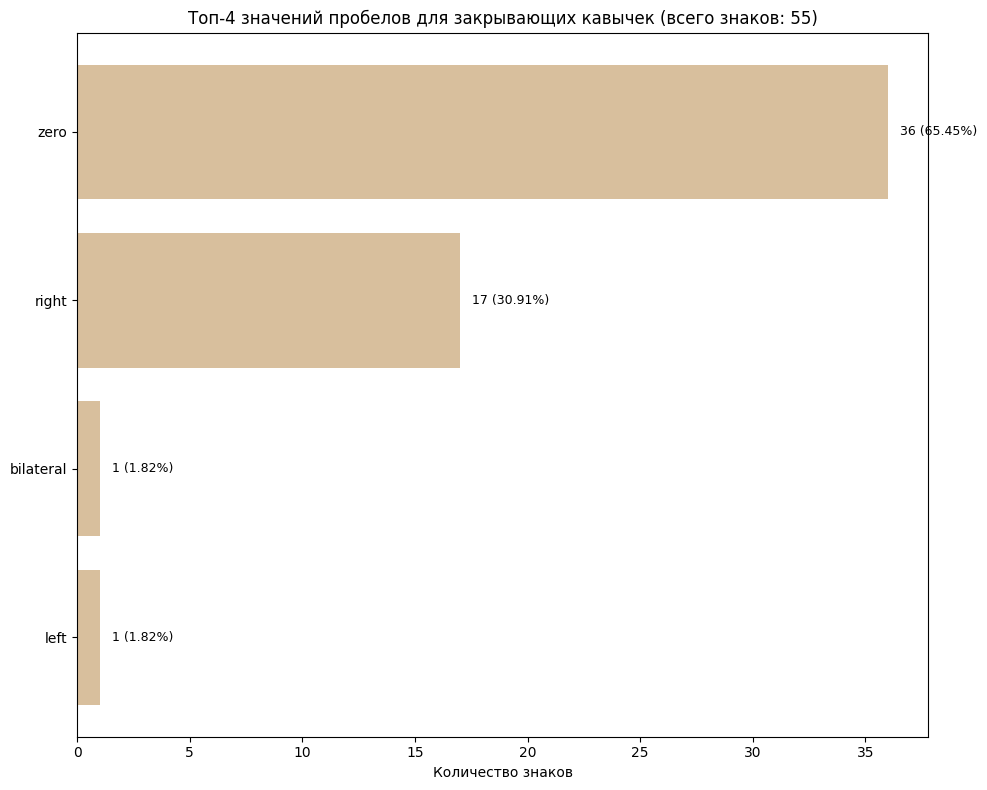

'close_quote_spaces_histogram.png'

In [983]:
visualize_spaces_stats(close_quote_spaces_stats_df, 'close_quote', total_close_quotes_spaces)

### Форма выражения

In [984]:
close_quote_expression_result = analyze_punctuation_expression(df_clean, 'close_quote')

close_quote_expression_lists = close_quote_expression_result['punct_expression_lists']
total_close_quotes_expression = close_quote_expression_result['total_puncts_expression']
all_close_quote_expression = close_quote_expression_result['all_expression_values']
total_close_quote_expression_values = close_quote_expression_result['total_expression_values']
close_quote_expression_counter = close_quote_expression_result['expression_counter']
close_quote_expression_stats_df = close_quote_expression_result['expression_stats_df']

Анализ формы выражения 'close_quote':

   - Общее количество close_quote: 58
   - Уникальных форм выражения: 3


In [985]:
print("Статистика по форме выражения закрывающих кавычек:\n")
print(close_quote_expression_stats_df.to_string(index=False))

Статистика по форме выражения закрывающих кавычек:

   Форма выражения  Количество  Доля (%)
right_double_angle          47     81.03
    quotation_mark          10     17.24
      double_qoute           1      1.72


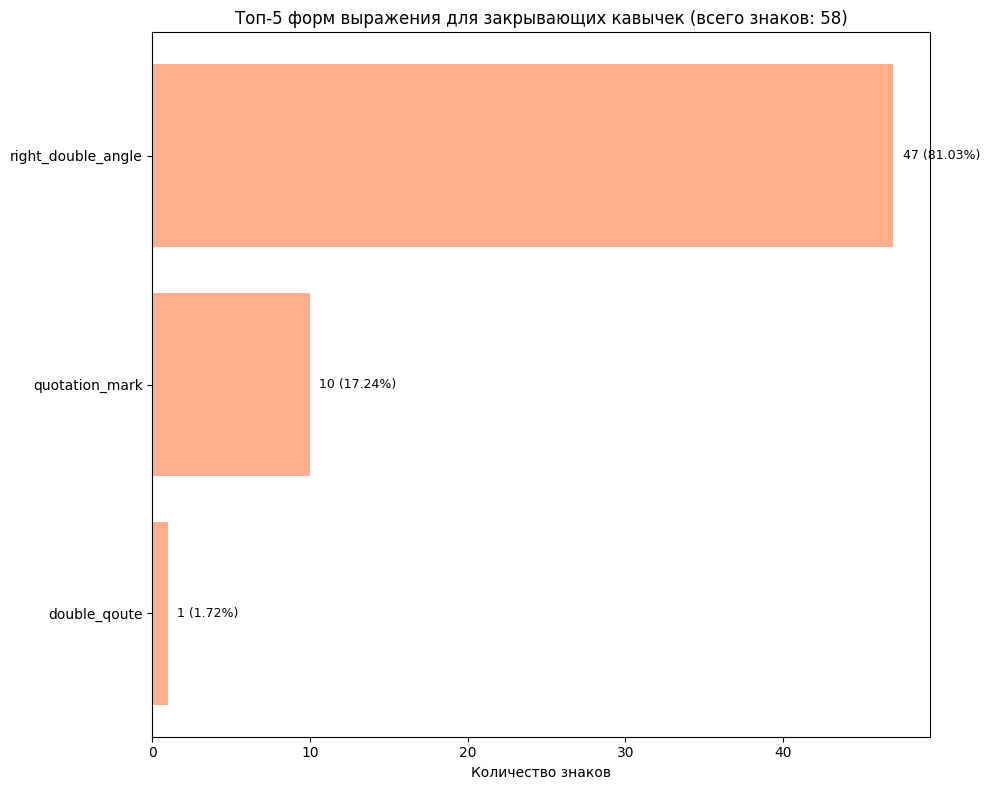

'close_quote_expression_histogram.png'

In [986]:
visualize_expression_stats(close_quote_expression_stats_df, 'close_quote', total_close_quotes_expression)

## Слеш

### Функции знака

In [987]:
slash_func_result = analyze_punctuation_func(df_clean, 'slash')

slash_func_lists = slash_func_result['punct_lists']
total_slashes = slash_func_result['total_puncts']
all_slash_functions = slash_func_result['all_functions']
total_slash_functions = slash_func_result['total_functions']
slash_func_counter = slash_func_result['func_counter']
slash_func_stats_df = slash_func_result['func_stats_df']

Анализ функций 'slash':

   - Общее количество slash: 57
   - Общее количество функций (с повторениями): 103
   - Среднее количество функций на знак: 1.81
   - Уникальных функций: 4


In [988]:
print("Статистика по функциям слеша:\n")
print(slash_func_stats_df.to_string(index=False))

Статистика по функциям слеша:

Функция  Количество  Доля (%)
 biblio          47     45.63
   comb          46     44.66
   link           9      8.74
 number           1      0.97


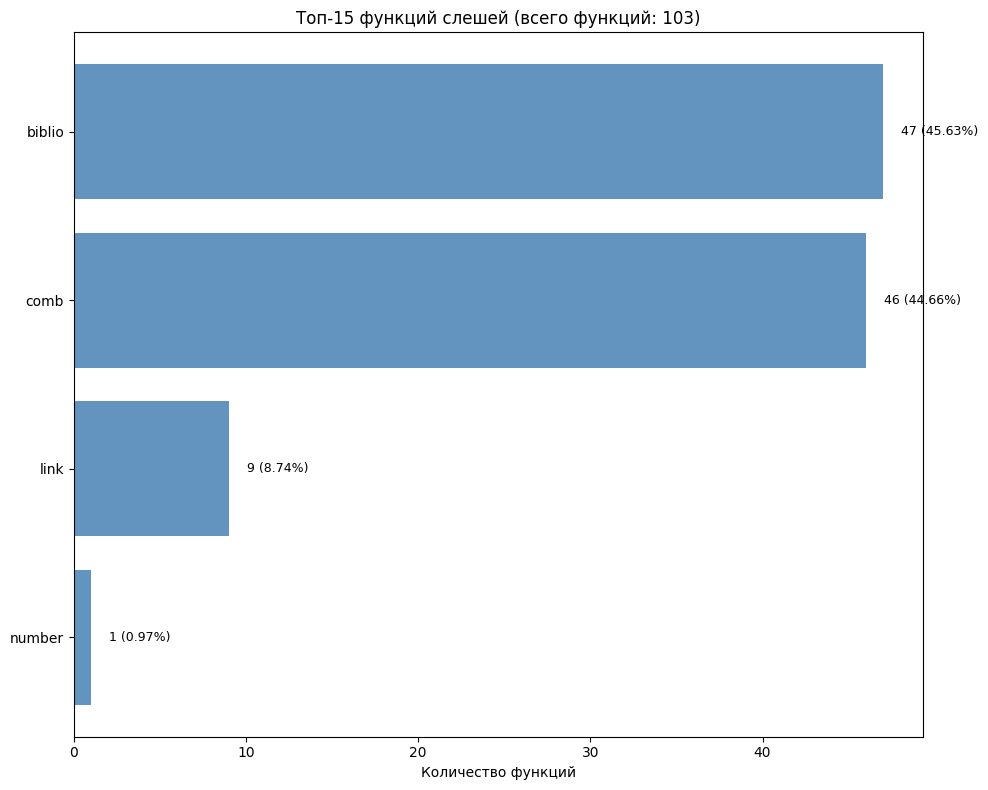

'slash_functions_histogram.png'

In [989]:
visualize_punct_functions(slash_func_stats_df, 'slash', total_slash_functions)

### Постановка/непостановка

In [990]:
slash_presence_result = analyze_punctuation_presence(df_clean, 'slash')

slash_presence_lists = slash_presence_result['punct_presence_lists']
total_slashes_presence = slash_presence_result['total_puncts_presence']
all_slash_presence = slash_presence_result['all_presence_values']
total_slash_presence_values = slash_presence_result['total_presence_values']
slash_presence_counter = slash_presence_result['presence_counter']
slash_presence_stats_df = slash_presence_result['presence_stats_df']

Анализ присутствия 'slash':

   - Общее количество slash: 57
   - Уникальных значений присутствия: 1


In [991]:
print("Статистика по присутствию слешей:\n")
print(slash_presence_stats_df.to_string(index=False))

Статистика по присутствию слешей:

Присутствие  Количество  Доля (%)
    present          57     100.0


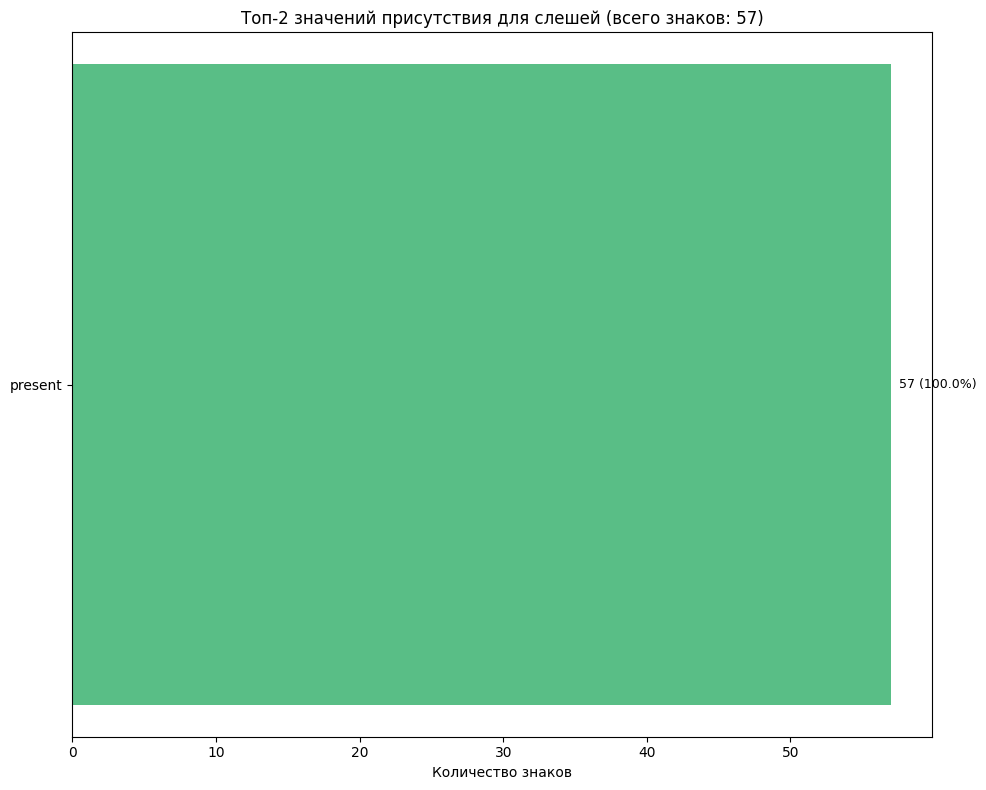

'slash_presence_histogram.png'

In [992]:
visualize_presence_stats(slash_presence_stats_df, 'slash', total_slashes_presence)

### Нормативность

In [993]:
slash_normality_result = analyze_punctuation_normality(df_clean, 'slash')

slash_normality_lists = slash_normality_result['punct_normality_lists']
total_slashes_normality = slash_normality_result['total_puncts_normality']
all_slash_normality = slash_normality_result['all_normality_values']
total_slash_normality_values = slash_normality_result['total_normality_values']
slash_normality_counter = slash_normality_result['normality_counter']
slash_normality_stats_df = slash_normality_result['normality_stats_df']

Анализ нормативности 'slash':

   - Общее количество slash: 57
   - Уникальных значений нормативности: 1


In [994]:
print("Статистика по нормативности слешей:\n")
print(slash_normality_stats_df.to_string(index=False))

Статистика по нормативности слешей:

Нормативность  Количество  Доля (%)
      correct          57     100.0


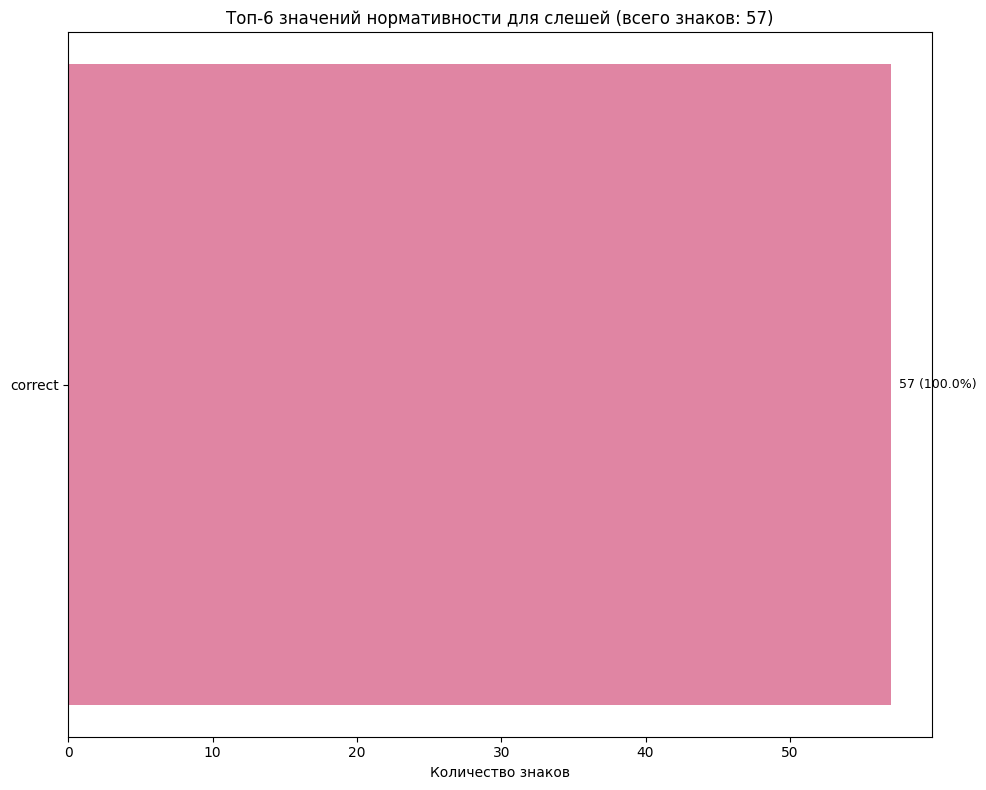

'slash_normality_histogram.png'

In [995]:
visualize_normality_stats(slash_normality_stats_df, 'slash', total_slashes_normality)

### Степень уверенности

In [996]:
slash_reliance_result = analyze_punctuation_reliance(df_clean, 'slash',
                                                     total_puncts_expected=total_slashes)

slash_reliance_lists = slash_reliance_result['punct_reliance_lists']
total_slashes_reliance = slash_reliance_result['total_puncts_reliance']
all_slash_reliance = slash_reliance_result['all_reliance_values']
total_slash_reliance_values = slash_reliance_result['total_reliance_values']
slash_reliance_counter = slash_reliance_result['reliance_counter']
slash_reliance_stats_df = slash_reliance_result['reliance_stats_df']
coverage_pct = slash_reliance_result['coverage_pct']

Анализ степени уверенности 'slash':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество slash (по функциям): 57
   - Покрытие разметки степени уверенности: 0.0%
   - Уникальных значений степени уверенности: 0


In [997]:
print("Статистика по степени уверенности слешей:\n")
print(slash_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности слешей:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%), Покрытие разметки (%)]
Index: []


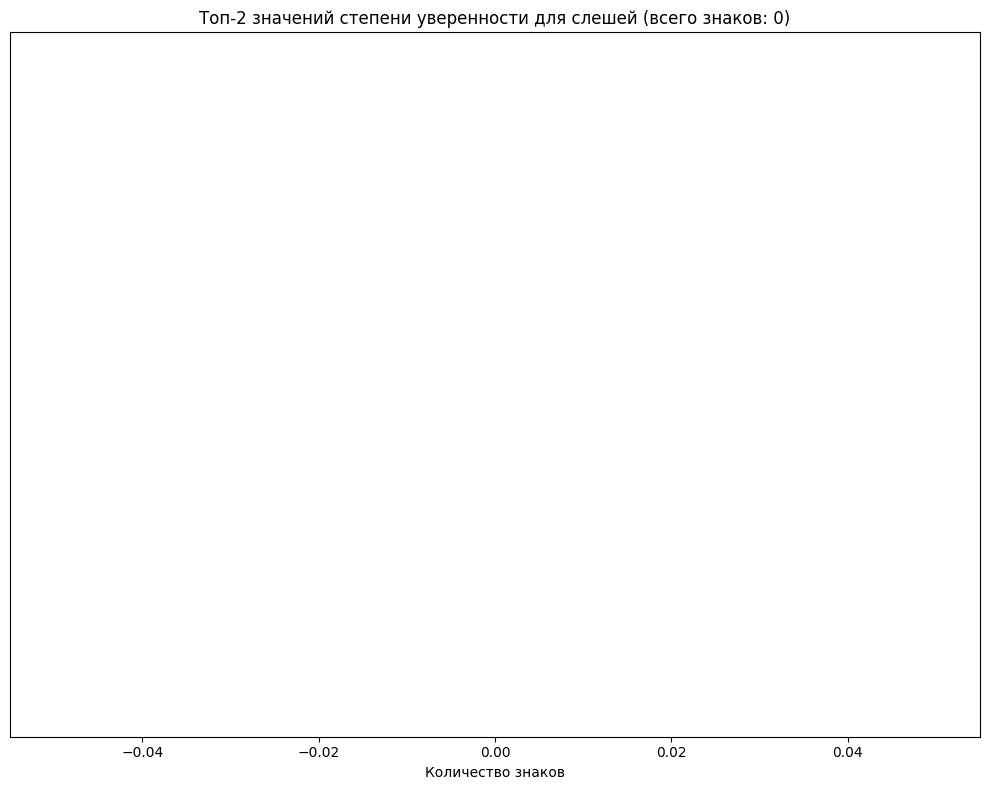

'slash_reliance_histogram.png'

In [998]:
visualize_reliance_stats(slash_reliance_stats_df, 'slash', total_slashes_reliance)

### Пробелы

In [999]:
slash_spaces_result = analyze_punctuation_spaces(df_clean, 'slash')

slash_spaces_lists = slash_spaces_result['punct_spaces_lists']
total_slashes_spaces = slash_spaces_result['total_puncts_spaces']
all_slash_spaces = slash_spaces_result['all_spaces_values']
total_slash_spaces_values = slash_spaces_result['total_spaces_values']
slash_spaces_counter = slash_spaces_result['spaces_counter']
slash_spaces_stats_df = slash_spaces_result['spaces_stats_df']

Анализ пробелов 'slash':

   - Общее количество slash: 57
   - Уникальных значений пробелов: 4


In [1000]:
print("Статистика по пробелам после слешей:\n")
print(slash_spaces_stats_df.to_string(index=False))

Статистика по пробелам после слешей:

   Пробел  Количество  Доля (%)
     left          23     40.35
    right          23     40.35
     zero          10     17.54
bilateral           1      1.75


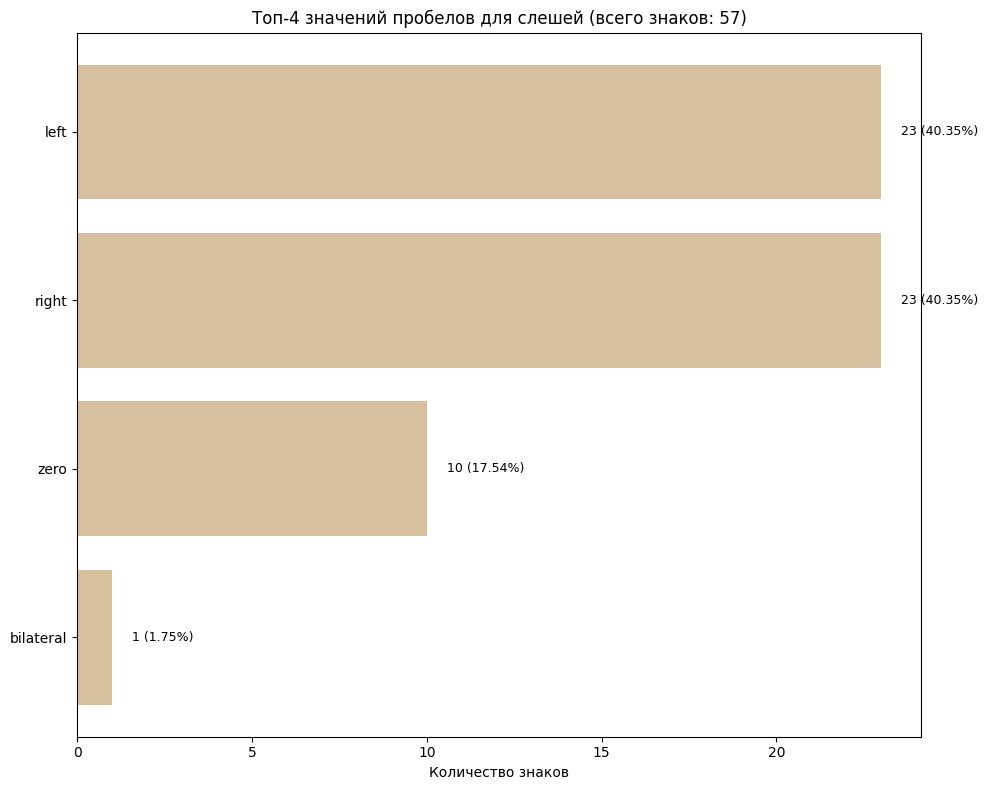

'slash_spaces_histogram.png'

In [1001]:
visualize_spaces_stats(slash_spaces_stats_df, 'slash', total_slashes_spaces)

## Апостроф

### Функции знака

In [1002]:
apostrophe_func_result = analyze_punctuation_func(df_clean, 'apostrophe')

apostrophe_func_lists = apostrophe_func_result['punct_lists']
total_apostrophes = apostrophe_func_result['total_puncts']
all_apostrophe_functions = apostrophe_func_result['all_functions']
total_apostrophe_functions = apostrophe_func_result['total_functions']
apostrophe_func_counter = apostrophe_func_result['func_counter']
apostrophe_func_stats_df = apostrophe_func_result['func_stats_df']

Анализ функций 'apostrophe':

   - Общее количество apostrophe: 0
   - Общее количество функций (с повторениями): 0
   - Уникальных функций: 0


In [1003]:
print("Статистика по функциям апострофов:\n")
print(apostrophe_func_stats_df.to_string(index=False))

Статистика по функциям апострофов:

Empty DataFrame
Columns: [Функция, Количество, Доля (%)]
Index: []


In [1004]:
# visualize_punct_functions(apostrophe_func_stats_df, 'apostrophe', total_apostrophe_functions)

### Постановка/непостановка

In [1005]:
apostrophe_presence_result = analyze_punctuation_presence(df_clean, 'apostrophe')

apostrophe_presence_lists = apostrophe_presence_result['punct_presence_lists']
total_apostrophes_presence = apostrophe_presence_result['total_puncts_presence']
all_apostrophe_presence = apostrophe_presence_result['all_presence_values']
total_apostrophe_presence_values = apostrophe_presence_result['total_presence_values']
apostrophe_presence_counter = apostrophe_presence_result['presence_counter']
apostrophe_presence_stats_df = apostrophe_presence_result['presence_stats_df']

Анализ присутствия 'apostrophe':

   - Общее количество apostrophe: 0
   - Уникальных значений присутствия: 0


In [1006]:
print("Статистика по присутствию апострофов:\n")
print(apostrophe_presence_stats_df.to_string(index=False))

Статистика по присутствию апострофов:

Empty DataFrame
Columns: [Присутствие, Количество, Доля (%)]
Index: []


In [1007]:
# visualize_presence_stats(apostrophe_presence_stats_df, 'apostrophe', total_apostrophes_presence)

### Нормативность

In [1008]:
apostrophe_normality_result = analyze_punctuation_normality(df_clean, 'apostrophe')

apostrophe_normality_lists = apostrophe_normality_result['punct_normality_lists']
total_apostrophes_normality = apostrophe_normality_result['total_puncts_normality']
all_apostrophe_normality = apostrophe_normality_result['all_normality_values']
total_apostrophe_normality_values = apostrophe_normality_result['total_normality_values']
apostrophe_normality_counter = apostrophe_normality_result['normality_counter']
apostrophe_normality_stats_df = apostrophe_normality_result['normality_stats_df']

Анализ нормативности 'apostrophe':

   - Общее количество apostrophe: 0
   - Уникальных значений нормативности: 0


In [1009]:
print("Статистика по нормативности апострофов:\n")
print(apostrophe_normality_stats_df.to_string(index=False))

Статистика по нормативности апострофов:

Empty DataFrame
Columns: [Нормативность, Количество, Доля (%)]
Index: []


In [1010]:
# visualize_normality_stats(apostrophe_normality_stats_df, 'apostrophe', total_apostrophes_normality)

### Степень уверенности

In [1011]:
apostrophe_reliance_result = analyze_punctuation_reliance(df_clean, 'apostrophe', total_puncts_expected=total_apostrophes)

apostrophe_reliance_lists = apostrophe_reliance_result['punct_reliance_lists']
total_apostrophes_reliance = apostrophe_reliance_result['total_puncts_reliance']
all_apostrophe_reliance = apostrophe_reliance_result['all_reliance_values']
total_apostrophe_reliance_values = apostrophe_reliance_result['total_reliance_values']
apostrophe_reliance_counter = apostrophe_reliance_result['reliance_counter']
apostrophe_reliance_stats_df = apostrophe_reliance_result['reliance_stats_df']
coverage_pct = apostrophe_reliance_result['coverage_pct']

Анализ степени уверенности 'apostrophe':

   - Знаков с размеченной степенью уверенности: 0
   - Общее количество apostrophe (по функциям): 0
   - Покрытие разметки: неприменимо (нет знаков)
   - Уникальных значений степени уверенности: 0


In [1012]:
print("Статистика по степени уверенности апострофов:\n")
print(apostrophe_reliance_stats_df.to_string(index=False))

Статистика по степени уверенности апострофов:

Empty DataFrame
Columns: [Степень уверенности, Количество, Доля (%)]
Index: []


In [1013]:
# visualize_reliance_stats(apostrophe_reliance_stats_df, 'apostrophe', total_apostrophes_reliance)

### Пробелы

In [1014]:
apostrophe_spaces_result = analyze_punctuation_spaces(df_clean, 'apostrophe')

apostrophe_spaces_lists = apostrophe_spaces_result['punct_spaces_lists']
total_apostrophes_spaces = apostrophe_spaces_result['total_puncts_spaces']
all_apostrophe_spaces = apostrophe_spaces_result['all_spaces_values']
total_apostrophe_spaces_values = apostrophe_spaces_result['total_spaces_values']
apostrophe_spaces_counter = apostrophe_spaces_result['spaces_counter']
apostrophe_spaces_stats_df = apostrophe_spaces_result['spaces_stats_df']

Анализ пробелов 'apostrophe':

   - Общее количество apostrophe: 0
   - Уникальных значений пробелов: 0


In [1015]:
print("Статистика по пробелам после апострофов:\n")
print(apostrophe_spaces_stats_df.to_string(index=False))

Статистика по пробелам после апострофов:

Empty DataFrame
Columns: [Пробел, Количество, Доля (%)]
Index: []


In [1016]:
# visualize_spaces_stats(apostrophe_spaces_stats_df, 'apostrophe', total_apostrophes_spaces)

### Форма выражения

In [1017]:
apostrophe_expression_result = analyze_punctuation_expression(df_clean, 'apostrophe')

apostrophe_expression_lists = apostrophe_expression_result['punct_expression_lists']
total_apostrophes_expression = apostrophe_expression_result['total_puncts_expression']
all_apostrophe_expression = apostrophe_expression_result['all_expression_values']
total_apostrophe_expression_values = apostrophe_expression_result['total_expression_values']
apostrophe_expression_counter = apostrophe_expression_result['expression_counter']
apostrophe_expression_stats_df = apostrophe_expression_result['expression_stats_df']

Анализ формы выражения 'apostrophe':

   - Общее количество apostrophe: 0
   - Уникальных форм выражения: 0


In [1018]:
print("Статистика по форме выражения апострофов:\n")
print(apostrophe_expression_stats_df.to_string(index=False))

Статистика по форме выражения апострофов:

Empty DataFrame
Columns: [Форма выражения, Количество, Доля (%)]
Index: []


In [1019]:
# visualize_expression_stats(apostrophe_expression_stats_df, 'apostrophe', total_apostrophes_expression)

## Общая статистика

In [1054]:
def parse_punct_column(val, is_functions=False):
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            if is_functions:
                return [item for item in parsed if isinstance(item, list)]
            else:
                return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

In [1055]:
def count_punct_marks_in_column(col_series, is_functions=False):
    return sum(len(parse_punct_column(val, is_functions)) for val in col_series)

In [1056]:
def aggregate_parameter_values(df, punct_signs, param_name):
    counter = Counter()

    for punct in punct_signs:
        col_name = f"{punct}_{param_name}"
        if col_name in df.columns:
            for val in df[col_name]:
                parsed = parse_punct_column(val, is_functions=False)
                for item in parsed:
                    counter[item] += 1

    return counter

In [1057]:
def calculate_punctuation_distribution(df):
    punct_signs = [
        'comma', 'period', 'exclam', 'question', 'colon', 'semicolon',
        'dash', 'hyphen', 'slash', 'left_parenthesis', 'right_parenthesis',
        'left_square_bracket', 'right_square_bracket', 'left_angle_bracket',
        'right_angle_bracket', 'open_quote', 'close_quote', 'apostrophe'
    ]

    distribution_data = []
    total_all_puncts = 0

    punct_counts = {}
    punct_func_counts = {}

    for punct in punct_signs:
        func_col = f"{punct}_functions"
        if func_col in df.columns:
            punct_count = 0
            func_count = 0

            for val in df[func_col]:
                parsed = parse_punct_column(val, is_functions=True)
                punct_count += len(parsed)
                for inner_list in parsed:
                    func_count += len(inner_list)

            if punct_count > 0:
                punct_counts[punct] = punct_count
                punct_func_counts[punct] = func_count
                total_all_puncts += punct_count

    for punct in punct_signs:
        if punct in punct_counts:
            count = punct_counts[punct]
            func_count = punct_func_counts[punct]
            share = round(count / total_all_puncts * 100, 2) if total_all_puncts > 0 else 0.0
            avg_funcs = round(func_count / count, 2) if count > 0 else 0.0

            punct_names = {
                'comma': 'Запятая',
                'period': 'Точка',
                'exclam': 'Восклицательный знак',
                'question': 'Вопросительный знак',
                'colon': 'Двоеточие',
                'semicolon': 'Точка с запятой',
                'dash': 'Тире',
                'hyphen': 'Дефис',
                'slash': 'Слеш',
                'left_parenthesis': 'Открывающая круглая скобка',
                'right_parenthesis': 'Закрывающая круглая скобка',
                'left_square_bracket': 'Открывающая квадратная скобка',
                'right_square_bracket': 'Закрывающая квадратная скобка',
                'left_angle_bracket': 'Открывающая треугольная скобка',
                'right_angle_bracket': 'Закрывающая треугольная скобка',
                'open_quote': 'Открывающая кавычка',
                'close_quote': 'Закрывающая кавычка',
                'apostrophe': 'Апостроф'
            }

            distribution_data.append({
                'Знак препинания': punct_names.get(punct, punct),
                'Код': punct,
                'Количество знаков': count,
                'Доля от общего числа (%)': share,
                'Среднее число функций на знак': avg_funcs
            })

    distribution_df = pd.DataFrame(distribution_data)
    distribution_df = distribution_df.sort_values('Количество знаков', ascending=False).reset_index(drop=True)

    return distribution_df, total_all_puncts

In [1058]:
def aggregate_parameter_statistics(df, punct_signs, param_name, param_label):
    results = []
    total_all_puncts = 0

    punct_totals = {}
    for punct in punct_signs:
        func_col = f"{punct}_functions"
        if func_col in df.columns:
            count = count_punct_marks_in_column(df[func_col], is_functions=True)
            if count > 0:
                punct_totals[punct] = count
                total_all_puncts += count

    for punct in punct_signs:
        if punct not in punct_totals:
            continue

        total_for_punct = punct_totals[punct]
        col_name = f"{punct}_{param_name}"

        if col_name in df.columns:
            counter = Counter()
            marked_count = 0

            for val in df[col_name]:
                parsed = parse_punct_column(val, is_functions=False)
                marked_count += len(parsed)
                for item in parsed:
                    counter[item] += 1

            coverage = round(marked_count / total_for_punct * 100, 2) if total_for_punct > 0 else 0.0

            for value, count in counter.most_common():
                share_in_punct = round(count / total_for_punct * 100, 2) if total_for_punct > 0 else 0.0
                share_in_corpus = round(count / total_all_puncts * 100, 2) if total_all_puncts > 0 else 0.0

                results.append({
                    'Знак препинания': punct,
                    param_label: value,
                    'Количество': count,
                    f'Доля от всех знаков этого типа (%)': share_in_punct,
                    f'Доля от всех знаков корпуса (%)': share_in_corpus,
                    'Покрытие разметки (%)': coverage
                })

    stats_df = pd.DataFrame(results)
    return stats_df, total_all_puncts

In [1059]:
def visualize_punctuation_distribution(distribution_df, top_n=20):
    if len(distribution_df) > top_n:
        top_df = distribution_df.head(top_n)
        others_count = distribution_df.iloc[top_n:]['Количество знаков'].sum()
        others_share = distribution_df.iloc[top_n:]['Доля от общего числа (%)'].sum()

        others_row = pd.DataFrame([{
            'Знак препинания': 'Остальные',
            'Код': 'other',
            'Количество знаков': others_count,
            'Доля от общего числа (%)': others_share,
            'Среднее число функций на знак': 0.0
        }])
        plot_df = pd.concat([top_df, others_row], ignore_index=True)
    else:
        plot_df = distribution_df.copy()

    plt.figure(figsize=(12, 8))
    y_pos = np.arange(len(plot_df))

    bars = plt.barh(y_pos, plot_df['Количество знаков'], color='pink', alpha=0.85)

    for i, (count, share) in enumerate(zip(plot_df['Количество знаков'], plot_df['Доля от общего числа (%)'])):
        plt.text(count + plot_df['Количество знаков'].max() * 0.01, i,
                f'{count:,} ({share}%)', va='center', fontsize=9)

    plt.yticks(y_pos, plot_df['Знак препинания'])
    plt.xlabel('Количество знаков')
    plt.title(f'Распределение знаков препинания в корпусе (всего знаков: {distribution_df["Количество знаков"].sum():,})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = 'punctuation_distribution.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [1060]:
def visualize_parameter_distribution(stats_df, param_label, param_name):
    agg_counter = Counter()
    for _, row in stats_df.iterrows():
        agg_counter[row[param_label]] += row['Количество']

    items = sorted(agg_counter.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0] for item in items[:20]]
    counts = [item[1] for item in items[:20]]

    plt.figure(figsize=(10, 8))
    y_pos = np.arange(len(labels))
    plt.barh(y_pos, counts, color='darkkhaki', alpha=0.85)

    total = sum(counts)
    for i, (count, label) in enumerate(zip(counts, labels)):
        pct = round(count / total * 100, 1)
        plt.text(count + total * 0.01, i, f'{count:,} ({pct}%)', va='center', fontsize=9)

    plt.yticks(y_pos, labels)
    plt.xlabel('Количество знаков')
    plt.title(f'Распределение значений "{param_label}" по всем знакам препинания\n(всего размеченных: {total:,})')
    plt.gca().invert_yaxis()
    plt.tight_layout()

    filename = f'parameter_{param_name}_distribution.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

    return filename

In [1061]:
distribution_df, total_all_puncts = calculate_punctuation_distribution(df)

In [1062]:
print(f"Общее количество знаков препинания в корпусе: {total_all_puncts:,}\n")
print(distribution_df.to_string(index=False))

Общее количество знаков препинания в корпусе: 2,899

              Знак препинания                  Код  Количество знаков  Доля от общего числа (%)  Среднее число функций на знак
                        Точка               period               1224                     42.22                           1.36
                      Запятая                comma                626                     21.59                           1.38
                         Тире                 dash                310                     10.69                           1.05
         Восклицательный знак               exclam                134                      4.62                           2.21
          Вопросительный знак             question                107                      3.69                           2.01
   Закрывающая круглая скобка    right_parenthesis                 98                      3.38                           1.00
   Открывающая круглая скобка     left_parenthesis        

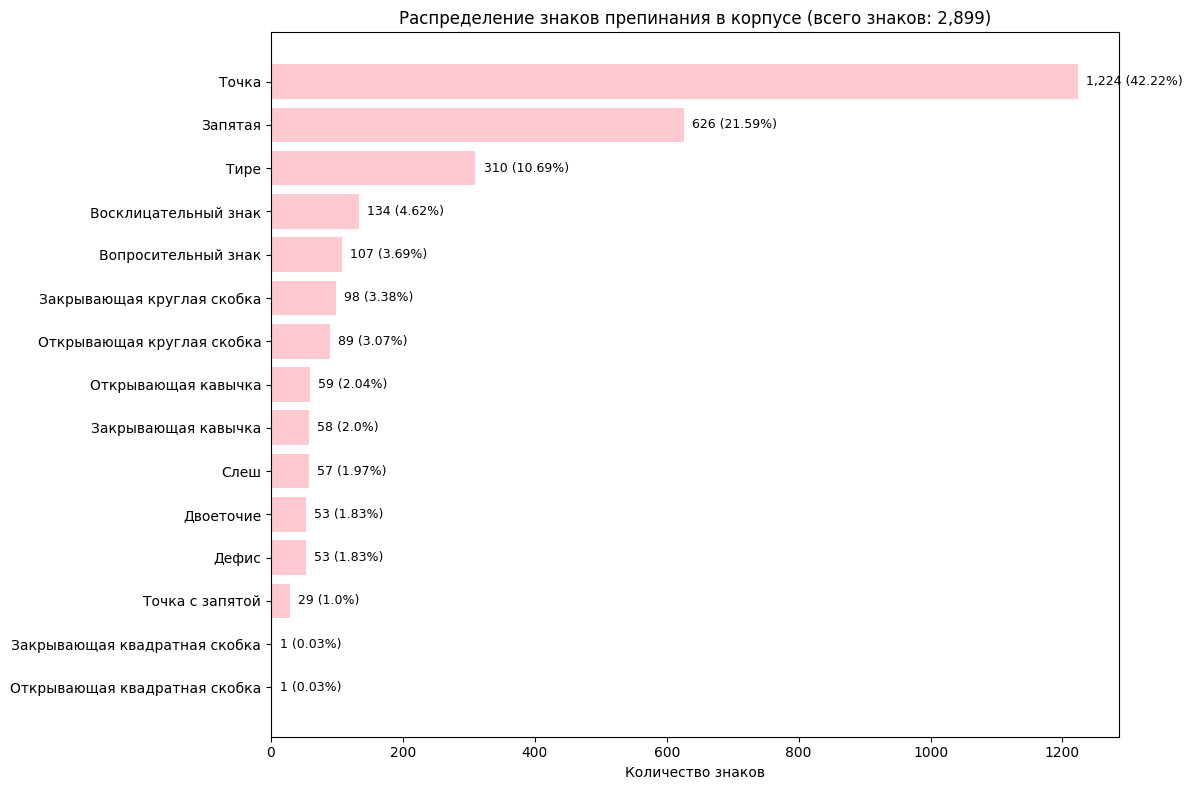

'punctuation_distribution.png'

In [1063]:
visualize_punctuation_distribution(distribution_df)

Статистика по параметру: Нормативность

Нормативность  Количество  Доля (%)
      correct        2716     93.27
      mistake          86      2.95
          ind          60      2.06
          var          29      1.00
          alt          13      0.45
       facult           5      0.17
         typo           3      0.10



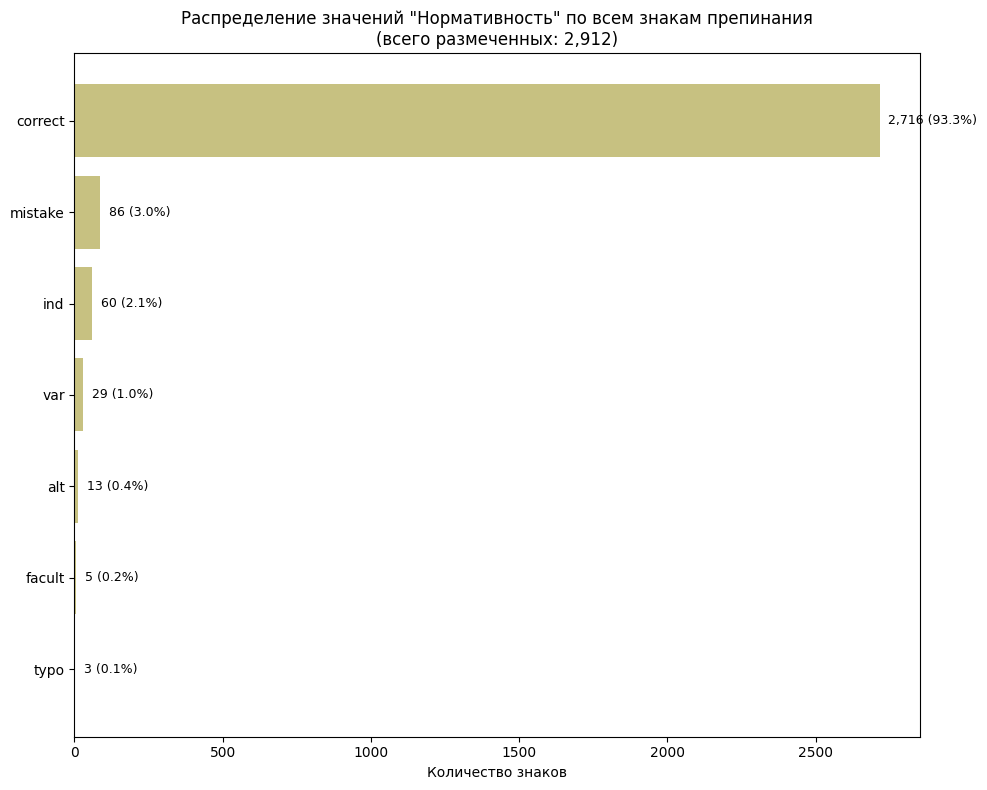

Статистика по параметру: Постановка/непостановка

Постановка/непостановка  Количество  Доля (%)
                present        2830     97.08
                missing          85      2.92



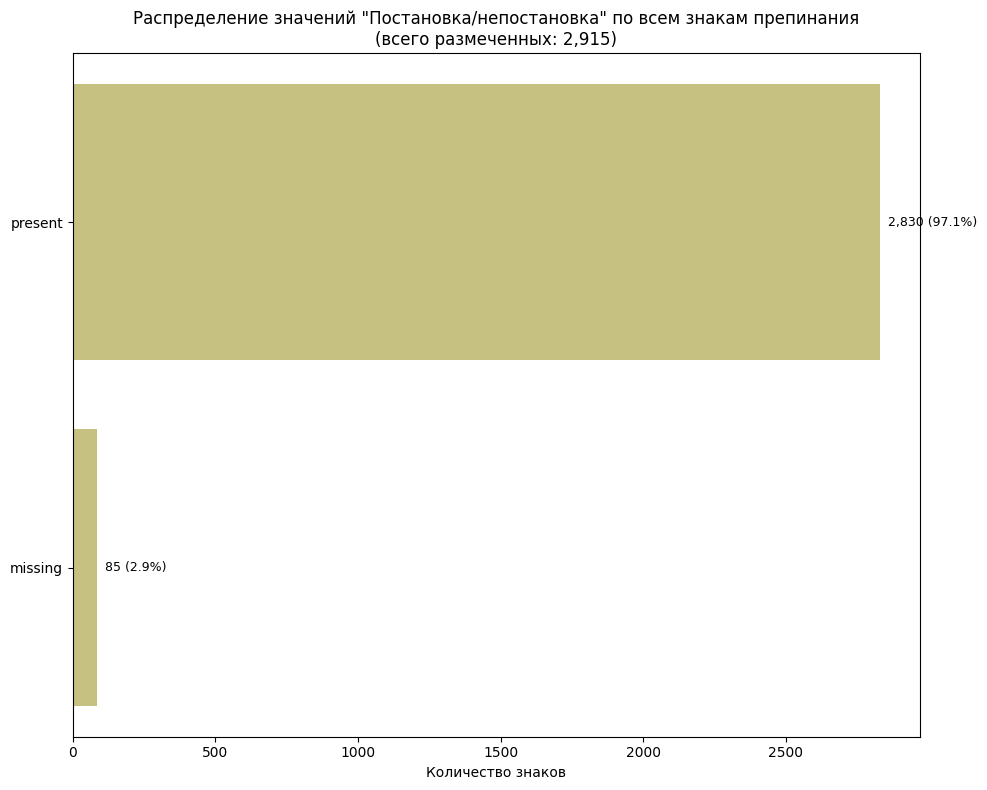

Статистика по параметру: Пробелы

  Пробелы  Количество  Доля (%)
    right        1919     66.68
     zero         580     20.15
bilateral         206      7.16
     left         173      6.01



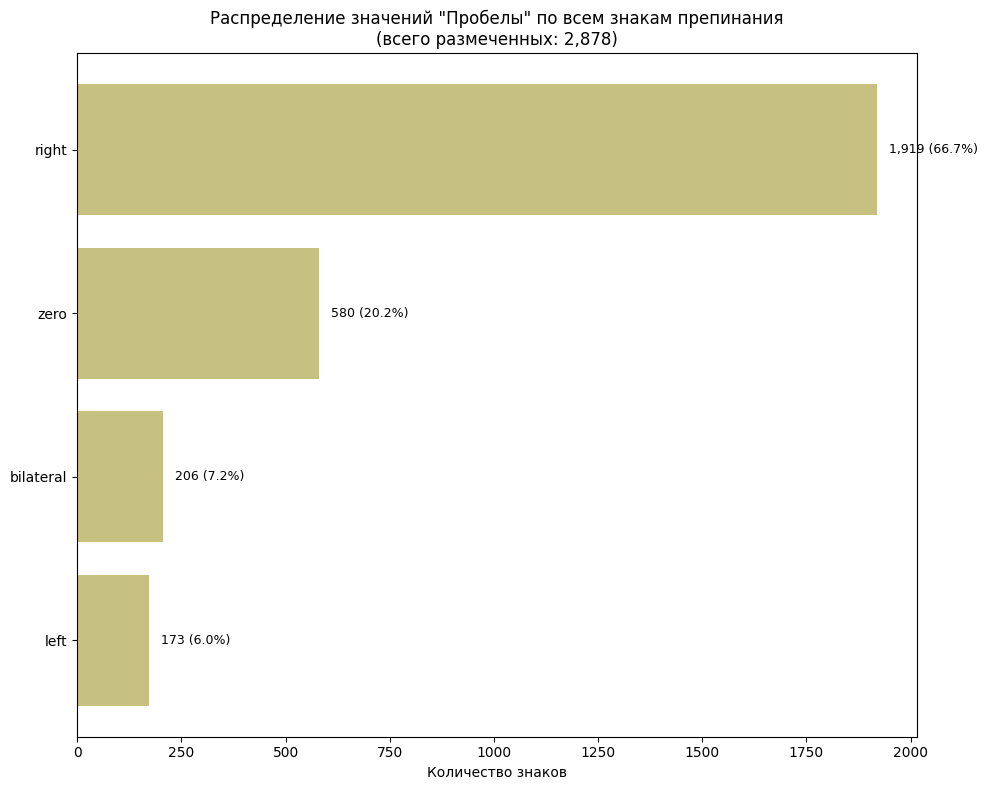

Статистика по параметру: Степень уверенности

Степень уверенности  Количество  Доля (%)
               high         268     91.47
                low          25      8.53



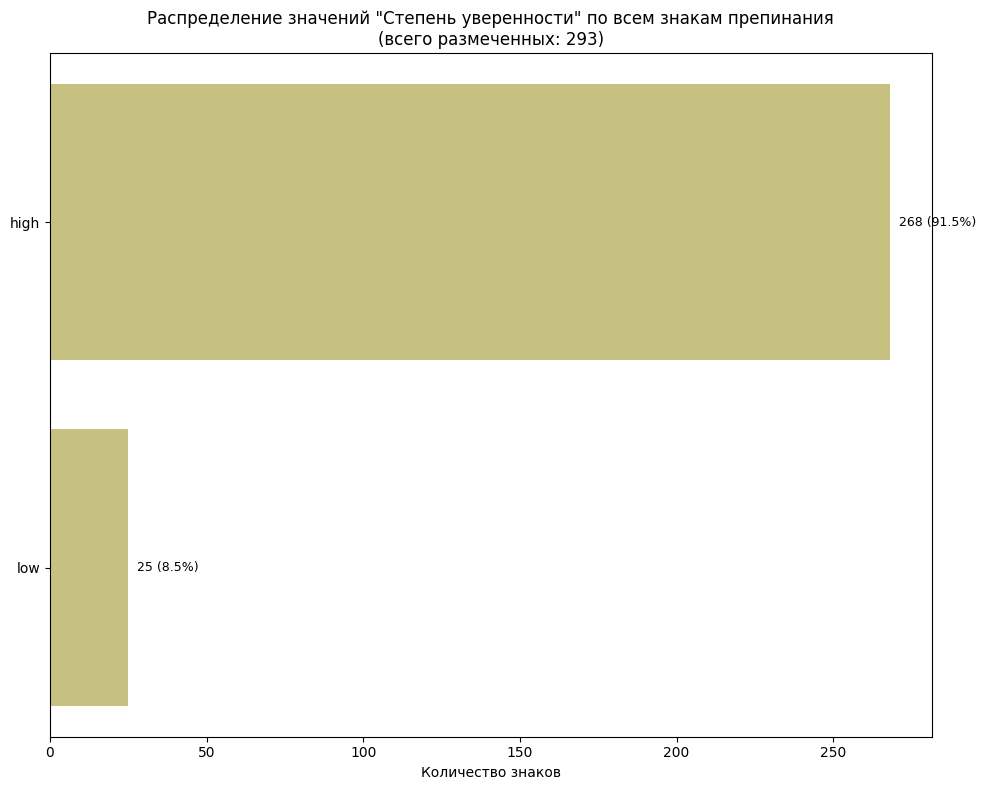

In [1064]:
punct_signs = [
    'comma', 'period', 'exclam', 'question', 'colon', 'semicolon',
    'dash', 'hyphen', 'slash', 'left_parenthesis', 'right_parenthesis',
    'left_square_bracket', 'right_square_bracket', 'left_angle_bracket',
    'right_angle_bracket', 'open_quote', 'close_quote', 'apostrophe'
]

parameters = [
    ('normality', 'Нормативность'),
    ('presence', 'Постановка/непостановка'),
    ('space', 'Пробелы'),
    ('reliance', 'Степень уверенности')
]

all_param_stats = {}

for param_name, param_label in parameters:
    print(f"Статистика по параметру: {param_label}\n")

    stats_df, _ = aggregate_parameter_statistics(df, punct_signs, param_name, param_label)
    all_param_stats[param_name] = stats_df

    if not stats_df.empty:
        agg_counter = Counter()
        for _, row in stats_df.iterrows():
            agg_counter[row[param_label]] += row['Количество']

        total_param = sum(agg_counter.values())
        agg_df = pd.DataFrame({
            param_label: list(agg_counter.keys()),
            'Количество': list(agg_counter.values()),
            'Доля (%)': [round(v / total_param * 100, 2) for v in agg_counter.values()]
        }).sort_values('Количество', ascending=False).reset_index(drop=True)
        print(agg_df.to_string(index=False) + '\n')

        param_plot = visualize_parameter_distribution(stats_df, param_label, param_name)

In [1065]:
summary_rows = []

for punct in punct_signs:
    func_col = f"{punct}_functions"
    if func_col in df.columns:
        total_puncts = count_punct_marks_in_column(df[func_col], is_functions=True)
        if total_puncts == 0:
            continue

        row = {
            'Знак препинания': punct,
            'Всего знаков': total_puncts
        }

        for param_name, _ in parameters:
            col_name = f"{punct}_{param_name}"
            if col_name in df.columns:
                marked = count_punct_marks_in_column(df[col_name], is_functions=False)
                coverage = round(marked / total_puncts * 100, 1) if total_puncts > 0 else 0.0
                row[f'{param_name} (%)'] = coverage
            else:
                row[f'{param_name} (%)'] = '—'

        summary_rows.append(row)

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_df = summary_df.sort_values('Всего знаков', ascending=False).reset_index(drop=True)

    print(summary_df.to_string(index=False))


print(f"\nОбщее количество предложений: {len(df):,}")
print(f"Общее количество знаков препинания: {total_all_puncts:,}")
print(f"Среднее количество знаков на предложение: {total_all_puncts / len(df):.2f}\n")


top5 = distribution_df.head(5)
print("Топ-5 самых частотных знаков препинания:")
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Знак препинания']:30s} {row['Количество знаков']:>8,} ({row['Доля от общего числа (%)']:>5.2f}%)")

     Знак препинания  Всего знаков  normality (%)  presence (%)  space (%)  reliance (%)
              period          1224          100.1         100.1       98.4           6.0
               comma           626          101.6         101.1      101.6          25.7
                dash           310          100.0         100.0      100.0          11.0
              exclam           134          100.0         100.0       97.8           0.0
            question           107           92.5          99.1       99.1           2.8
   right_parenthesis            98          100.0         100.0       93.9           9.2
    left_parenthesis            89          100.0         100.0      100.0           0.0
          open_quote            59          103.4         100.0       94.9           5.1
         close_quote            58          103.4         100.0       94.8           8.6
               slash            57          100.0         100.0      100.0           0.0
               colon 

**Комментарий**. Не очень понимаю, почему у некоторых знаков по некоторым параметрам (по всем, кроме степени уверенности) покрытие разметки получилось меньше или больше 100%... Я проверяла автоматически, везде ли совпадают длины списков с параметрами, вручную устраняла несоответствия. Последняя машинная проверка показала, что несоответствий не осталось...

## СНОВА ПРОВЕРКА

In [1066]:
import pandas as pd
import ast

def parse_safe(val, is_functions=False):
    """
    Безопасный парсинг значения из ячейки в список.

    Параметры:
        val: значение из ячейки
        is_functions: True для колонок *_functions (списки списков),
                      False для остальных (списки строк)
    """
    if pd.isna(val) or val == '' or val == '[]':
        return []
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            if is_functions:
                return [item for item in parsed if isinstance(item, list)]
            else:
                return [item for item in parsed if isinstance(item, str) and item.strip()]
        return []
    except (ValueError, SyntaxError):
        return []

def find_inconsistency_details(df):
    """
    Ищет все строки, где количество знаков по разным параметрам не совпадает.

    Возвращает:
        Список словарей с деталями конфликтов
    """
    punct_signs = [
        'comma', 'period', 'exclam', 'question', 'colon', 'semicolon',
        'dash', 'hyphen', 'slash', 'left_parenthesis', 'right_parenthesis',
        'left_square_bracket', 'right_square_bracket', 'left_angle_bracket',
        'right_angle_bracket', 'open_quote', 'close_quote', 'apostrophe'
    ]

    # Определяем колонку с предложениями
    sentence_col = None
    for col in ['sentence', 'sentences']:
        if col in df.columns:
            sentence_col = col
            break

    inconsistencies = []

    # Проходим по каждой строке датафрейма
    for idx, row in df.iterrows():
        row_inconsistencies = []

        for punct in punct_signs:
            # Проверяем, есть ли колонки для этого знака
            all_params = ['functions', 'normality', 'presence', 'space', 'reliance']
            available_params = []
            lengths = {}
            parsed_values = {}

            for param in all_params:
                col_name = f"{punct}_{param}"
                if col_name in df.columns:
                    available_params.append(param)
                    val = row[col_name]
                    parsed = parse_safe(val, param == 'functions')
                    lengths[param] = len(parsed)
                    parsed_values[param] = parsed

            # Проверяем, есть ли расхождения в длинах
            if len(available_params) > 1:
                # Собираем ненулевые длины
                non_zero_lengths = {p: l for p, l in lengths.items() if l > 0}

                if non_zero_lengths:
                    unique_lengths = set(non_zero_lengths.values())
                    if len(unique_lengths) > 1:
                        # Найдено расхождение
                        row_inconsistencies.append({
                            'punctuation': punct,
                            'lengths': lengths,
                            'parsed_values': parsed_values
                        })

        # Если есть расхождения в этой строке
        if row_inconsistencies:
            sentence_text = row[sentence_col] if sentence_col and sentence_col in row.index else None

            inconsistencies.append({
                'row_index': idx,
                'row_number': idx + 1,
                'sentence': sentence_text,
                'inconsistencies': row_inconsistencies
            })

    return inconsistencies, sentence_col

def print_inconsistency_details(inconsistencies, sentence_col):
    """
    Выводит детали расхождений в разметке.
    """
    total = len(inconsistencies)

    if total == 0:
        print("✅ Все строки консистентны: количество знаков по всем параметрам совпадает.")
        return

    print(f"⚠️  Обнаружено {total} строк с расхождениями в количестве знаков по параметрам:\n")

    for i, data in enumerate(inconsistencies, 1):
        print(f"{'='*70}")
        print(f"Строка №{data['row_number']} (индекс датафрейма: {data['row_index']})")
        print(f"{'='*70}")

        # Выводим предложение
        if data['sentence'] is not None and pd.notna(data['sentence']) and str(data['sentence']).strip():
            print(f"\nПредложение:")
            print(f"  «{data['sentence']}»\n")
        else:
            print("\nПредложение: (отсутствует или пустое)\n")

        # Выводим детали расхождений
        for conflict in data['inconsistencies']:
            punct = conflict['punctuation']
            lengths = conflict['lengths']
            parsed_values = conflict['parsed_values']

            print(f"Знак препинания: '{punct}'")
            print("Длины списков по параметрам:")

            # Сортируем параметры
            sorted_params = sorted(lengths.keys())
            for param in sorted_params:
                length = lengths[param]
                values = parsed_values[param]
                print(f"  {param:15s}: {length:3d} знак(ов)  →  {values}")

            # Показываем расхождения
            non_zero_lengths = {p: l for p, l in lengths.items() if l > 0}
            if non_zero_lengths:
                min_len = min(non_zero_lengths.values())
                max_len = max(non_zero_lengths.values())
                if min_len != max_len:
                    print(f"\n⚠️  Расхождение: от {min_len} до {max_len} знаков")
                    min_params = [p for p, l in non_zero_lengths.items() if l == min_len]
                    max_params = [p for p, l in non_zero_lengths.items() if l == max_len]
                    print(f"    Минимум в параметрах: {', '.join(min_params)}")
                    print(f"    Максимум в параметрах: {', '.join(max_params)}")
                else:
                    # Есть нулевые параметры при наличии ненулевых
                    zero_params = [p for p, l in lengths.items() if l == 0]
                    if zero_params:
                        print(f"\n⚠️  Неполная разметка: параметры без значений — {', '.join(zero_params)}")
            else:
                print("\n⚠️  Все параметры имеют нулевую длину (нет знаков данного типа)")

            print()

# ======================
# ОСНОВНОЙ КОД ПРОВЕРКИ
# ======================

print("="*70)
print("ПРОВЕРКА РАСХОЖДЕНИЙ В КОЛИЧЕСТВЕ ЗНАКОВ ПО ПАРАМЕТРАМ")
print("="*70)
print()

# Загрузка данных
df = pd.read_csv('Семь тыщ 06.02.2026.csv', on_bad_lines='skip')

print(f"Загружено строк: {len(df)}")
print(f"Всего колонок: {len(df.columns)}")
print(f"Доступные колонки (выборка): {', '.join(df.columns[:10])}...")
print()

# Поиск расхождений
inconsistencies, sentence_col = find_inconsistency_details(df)

# Вывод результатов
print_inconsistency_details(inconsistencies, sentence_col)

# Дополнительно: сводка по типам несоответствий
if inconsistencies:
    print("\n" + "="*70)
    print("СВОДКА ПО ТИПАМ РАСХОЖДЕНИЙ")
    print("="*70)

    punct_summary = {}
    for data in inconsistencies:
        for conflict in data['inconsistencies']:
            punct = conflict['punctuation']
            punct_summary[punct] = punct_summary.get(punct, 0) + 1

    summary_df = pd.DataFrame({
        'Знак препинания': list(punct_summary.keys()),
        'Количество строк с расхождениями': list(punct_summary.values())
    }).sort_values('Количество строк с расхождениями', ascending=False).reset_index(drop=True)

    print(summary_df.to_string(index=False))

ПРОВЕРКА РАСХОЖДЕНИЙ В КОЛИЧЕСТВЕ ЗНАКОВ ПО ПАРАМЕТРАМ

Загружено строк: 493
Всего колонок: 117
Доступные колонки (выборка): sentence_id, sentences, corrections, right_context, left_context, period_indices, comma_indices, exclam_indices, question_indices, left_parenthesis_indices...

✅ Все строки консистентны: количество знаков по всем параметрам совпадает.
